In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.Environment import ChargingIntegratedEnvironment
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Using fallback logging instead of TensorBoard to avoid protobuf compatibility issues


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import torch
import docplex
torch.manual_seed(0)
a = torch.rand(2, 2)

In [7]:
import numpy as np
import torch
np.random.seed(64)
torch.manual_seed(64)
r_1 = torch.rand(3,3)
r_2 = torch.zeros_like(r_1)
r_2

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import pandas as pd
data_time = pd.read_excel(r'results/assignment_runtime_reward_comparison.xlsx')
label_map = {
    'MCMF (SSP)': 'MCMF',
    'Heuristic (TLHA)': 'Heu',
    'Scaled graph + Gurobi': 'SGG',
}

data_time['Method'] = data_time['Method'].replace(label_map)
data_time = data_time.iloc[:,:-3]
num = 0
for i in range(data_time.shape[0]):
    result = ""
    for column in data_time.columns:
        if column in ['Method']:
            result += f"{data_time.iloc[i][column]} & "
        elif column in ['Time (s)']:
            result += f"{data_time.iloc[i][column]:.4f} & "
        else:
            result += f"{data_time.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

In [ ]:
data_time

In [ ]:
solution_time = data_time.copy()

sns.set_style('whitegrid')

alg_order = ['Gurobi', 'MCMF', 'SGG', 'Heu']
alg_label = {
    'Gurobi': 'Gurobi',
    'MCMF': 'MCMF',
    'SGG': 'Scaled-graph Gurobi',
    'Heu': 'Heuristic',
}
alg_color = {
    'Gurobi': '#E63946',
    'MCMF': '#1D3557',
    'SGG': '#2A9D8F',
    'Heu': '#8D99AE',
}
st_df = solution_time.copy()
st_df = st_df[st_df['Method'].isin(alg_order)]
st_df['scale_label'] = (
    st_df['NV'].astype(int).astype(str) + 'V/' + st_df['NA'].astype(int).astype(str) + 'R'
)

agg = (
    st_df.groupby(['NV', 'NA', 'NC', 'NR', 'scale_label', 'Method'], as_index=False)['Time (s)']
    .agg(mean_time='mean', std_time='std')
    .fillna({'std_time': 0.0})
)
agg = agg.sort_values(['NV', 'NA'])
scale_order = (
    agg[['NV', 'NA', 'scale_label']]
    .drop_duplicates()
    .sort_values(['NV', 'NA'])['scale_label']
    .tolist()
)
agg['scale_label'] = pd.Categorical(agg['scale_label'], categories=scale_order, ordered=True)
agg['Method'] = pd.Categorical(agg['Method'], categories=alg_order, ordered=True)
agg = agg.sort_values(['scale_label', 'Method']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), dpi=200)

# ===== 左图: 分组柱状图 (对数刻度) =====
ax = axes[0]
x = np.arange(len(scale_order))
width = 0.16
for i, alg in enumerate(alg_order):
    sub = agg[agg['Method'] == alg].set_index('scale_label').reindex(scale_order)
    offset = (i - (len(alg_order) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        sub['mean_time'].values,
        width,
        yerr=sub['std_time'].values,
        label=alg_label[alg],
        color=alg_color[alg],
        alpha=0.9,
        capsize=3,
        edgecolor='white',
        linewidth=0.6,
    )
    # for rect, val in zip(bars, sub['mean_time'].values):
    #     if np.isfinite(val) and val > 0:
    #         ax.text(
    #             rect.get_x() + rect.get_width() / 2,
    #             val * 1.08,
    #             f'{val:.2g}',
    #             ha='center', va='bottom', fontsize=7,
    #         )

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(scale_order, fontsize=11)
ax.set_xlabel('Problem Scale (Vehicles / Requests)', fontsize=12, fontweight='bold')
ax.set_ylabel('Solve Time (s, log scale)', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Solve Time vs Problem Scale', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3, axis='y', which='both')

# ===== 右图: 折线图 (规模扩展趋势) =====
ax2 = axes[1]
for alg in alg_order:
    sub = agg[agg['Method'] == alg].sort_values('NV')
    ax2.plot(
        sub['NV'].astype(int),
        sub['mean_time'],
        marker='o',
        markersize=7,
        linewidth=2.2,
        label=alg_label[alg],
        color=alg_color[alg],
    )

ax2.set_yscale('log')
ax2.set_xscale('log')
xticks = sorted(agg['NV'].unique())
ax2.set_xticks(xticks)
ax2.set_xticklabels([str(int(v)) for v in xticks])
ax2.set_xlabel('Number of Vehicles (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Solve Time (s, log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Scaling Behavior of Algorithms', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ===== 数值表 =====
pivot = agg.pivot_table(index='scale_label', columns='Method', values='mean_time', observed=True)
pivot = pivot[alg_order]
print('\n===== Mean Solve Time (seconds) =====')
print(pivot.round(4).to_string())


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
data_syn = pd.read_excel(r'results/test_model/test_results_4way_standard_masac_gat_20260723_034151.xlsx')
data_syn.columns

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
data_syn = pd.read_excel(r'results/test_model/test_results_4way_standard_masac_gat_20260723_034151.xlsx')
compare_lists_heu = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]

data_syn["pressure_ratio"] = (
    data_syn["mean_max_station_pressure"]
    / data_syn["mean_station_pressure"].replace(0, np.nan)
)
data_syn = data_syn[compare_lists_heu]
data_syn['mean_service_ratio'] = np.round(data_syn['mean_service_ratio']*100, 2)
data_syn['avg_battery_level'] = np.round(data_syn['avg_battery_level']*100, 2)
for i in range(data_syn.shape[1]):
    if data_syn.iloc[:, i].dtype == 'float64':
        data_syn.iloc[:, i] = data_syn.iloc[:, i].round(2)
data_syn.to_excel(r'results/syn_results/syn_summary.xlsx', index=False)
label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
mode_order = ['I', 'EF', 'AF']

data_syn['mode'] = data_syn['mode'].replace(label_map)
num = 0
for i in range(data_syn.shape[0]):
    result = ""+str(num)+"&"
    for column in data_syn.columns:
        if column in ['strategy','mode']:
            result += f"{data_syn.iloc[i][column]} & "
        else:
            result += f"{data_syn.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

In [ ]:
data_adp_mcmf = data_syn[data_syn['strategy'] == 'ADP-MCMF']
data_adp_mcmf

In [ ]:
data_adp_mcmf = data_syn[data_syn['strategy'] == 'ADP-MCMF']
data_masac_bench = pd.read_excel(r'results/test_model/test_results_4way_masac_baseline_20260724_123645.xlsx')
data_masac_bench_adpmcmf = data_masac_bench[data_masac_bench['strategy']=='ADP-MCMF']
data_masac_bench_adpmcmf = data_masac_bench_adpmcmf[compare_lists_heu]
data_masac_bench_adpmcmf['mode'] = data_masac_bench_adpmcmf['mode'].replace(label_map)
data_masac_bench_adpmcmf['mean_service_ratio'] = np.round(data_masac_bench_adpmcmf['mean_service_ratio']*100, 2)
data_masac_bench_adpmcmf['avg_battery_level'] = np.round(data_masac_bench_adpmcmf['avg_battery_level']*100, 2)
for i in range(data_masac_bench_adpmcmf.shape[1]):
    if data_masac_bench_adpmcmf.iloc[:, i].dtype == 'float64':
        data_masac_bench_adpmcmf.iloc[:, i] = data_masac_bench_adpmcmf.iloc[:, i].round(2)
data_adp_mcmf['strategy'] = "GAFL-MASAC"
data_masac_bench_adpmcmf['strategy'] = "MASAC"



data_5_origin = pd.concat([data_masac_bench_adpmcmf,data_adp_mcmf], ignore_index=True)
num = 0
for i in range(data_5_origin.shape[0]):
    result = ""+str(num)+"&"
    for column in data_5_origin.columns:
        if column in ['strategy','mode']:
            result += f"{data_5_origin.iloc[i][column]} & "
        elif column == 'avg_reward' or column == 'episode_reward_ev' or column == 'episode_reward_aev':
            result += f"{data_5_origin.iloc[i][column]:.2e} & "
        else:
            result += f"{data_5_origin.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1



In [ ]:
data_heu = pd.read_excel(r'results/test_model_battery_heu/heu_battery_threshold_results_st_masac_gat_queue_demand_gurobi.xlsx')
compare_lists_heu = ['strategy','heuristic_battery_threshold','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]

data_heu["pressure_ratio"] = (
    data_heu["mean_max_station_pressure"]
    / data_heu["mean_station_pressure"].replace(0, np.nan)
)
data_heu = data_heu[compare_lists_heu]
data_heu['mean_service_ratio'] = np.round(data_heu['mean_service_ratio']*100, 2)
data_heu['avg_battery_level'] = np.round(data_heu['avg_battery_level']*100, 2)
data_syn_heu = data_syn.copy()
data_syn_heu['heuristic_battery_threshold'] = 0
data_syn_heu_adpheu = data_syn_heu[(data_syn_heu['strategy'] == 'ADP-HEU') & (data_syn_heu['mode'] == 'I')]
data_syn_heu_adpheu_compare = data_syn_heu_adpheu[compare_lists_heu]
data_heu['mode'] = data_heu['mode'].replace(label_map)
data_heu = pd.concat([data_heu, data_syn_heu_adpheu_compare], ignore_index=True)
data_heu.to_excel(r'results/syn_results/syn_summary_heu.xlsx', index=False)

for i in range(data_heu.shape[1]):
    if data_heu.iloc[:, i].dtype == 'float64':
        data_heu.iloc[:, i] = data_heu.iloc[:, i].round(2)
num = 0
for i in range(data_heu.shape[0]):
    result = ""+str(num)+"&"
    for column in data_heu.columns:
        if column in ['strategy','mode']:
            result += f"{data_heu.iloc[i][column]} & "
        else:
            result += f"{data_heu.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

In [ ]:
import matplotlib.pyplot as plt
import gurobipy as gp

print("Gurobi version:", gp.gurobi.version())

try:
    with gp.Env() as env:
        print("Gurobi license check: environment initialized successfully")
except gp.GurobiError as exc:
    print("Gurobi license  check failed:", exc)

In [ ]:
# data_test_syn = pd.read_excel(r'results/test_model/test_results_4way_st_masac_gat_queue_demand_gurobi_20260717_121906.xlsx')
# data_test_heu = pd.read_excel(r'results/test_model_battery_heu/heu_battery_threshold_results_st_masac_gat_queue_demand_gurobi.xlsx')
# data_test_baseline = pd.read_excel(r'results/test_model/test_results_4way_masac_baseline_20260717_144823.xlsx')
# df_heu = data_test_heu
# data_test_syn_adp = data_test_syn[data_test_syn['strategy'] == 'ADP-HEU']
# data_test_syn_adp['heuristic_battery_threshold'] = 0
# compare_lists_heu = ['strategy','heuristic_battery_threshold','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,'mean_station_pressure',"pressure_ratio"]

# df_heu["pressure_ratio"] = (
#     df_heu["mean_max_station_pressure"]
#     / df_heu["mean_station_pressure"].replace(0, np.nan)
# )

# df_syn_adp = data_test_syn_adp
# df_syn_adp["pressure_ratio"] = (
#     df_syn_adp["mean_max_station_pressure"]
#     / df_syn_adp["mean_station_pressure"].replace(0, np.nan)
# )
# df_heu_battery = data_test_heu[compare_lists_heu]
# df_syn_adp_battery = df_syn_adp[compare_lists_heu]
# df_heu_battery_sum = pd.concat([df_heu_battery, df_syn_adp_battery], ignore_index=True)
# df_heu_battery_sum = df_heu_battery_sum.iloc[:-2 ,:].copy()
# df_heu_battery_sum['mean_service_ratio'] = np.round(df_heu_battery_sum['mean_service_ratio']*100, 2)
# df_heu_battery_sum['avg_battery_level'] = np.round(df_heu_battery_sum['avg_battery_level']*100, 2)
# for i in range(df_heu_battery_sum.shape[1]):
#     if df_heu_battery_sum.iloc[:, i].dtype == 'float64':
#         df_heu_battery_sum.iloc[:, i] = df_heu_battery_sum.iloc[:, i].round(2)
# df_heu_battery_sum.to_excel(r'results/syn_results/heu_battery_sum.xlsx', index=False)

In [ ]:
# data_test_syn = pd.read_excel(r'results/test_model/test_results_4way_st_masac_gat_queue_demand_gurobi_20260717_121906.xlsx')
# compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ]
# data_test_syn_compare = data_test_syn[compare_lists]
# data_test_syn_compare['mean_service_ratio'] = np.round(data_test_syn_compare['mean_service_ratio']*100, 2)
# data_test_syn_compare['avg_battery_level'] = np.round(data_test_syn_compare['avg_battery_level']*100, 2)
# for i in range(data_test_syn_compare.shape[1]):
#     if data_test_syn_compare.iloc[:, i].dtype == 'float64':
#         data_test_syn_compare.iloc[:, i] = data_test_syn_compare.iloc[:, i].round(2)
# data_test_syn_compare = data_test_syn_compare[data_test_syn_compare['strategy']!= 'HEU-K']
# data_test_syn_compare.to_excel(r'results/syn_results/syn_compare.xlsx', index=False)

In [ ]:
# label_map = {
#     'aevfirst': 'AF',
#     'evfirst': 'EF',
#     'integrated': 'I',
# }
# strategy_order = ['MCMF', 'MCMF-K', 'ADP-MCMF', 'ADP-MCMF-K','HEU', 'ADP-HEU','ADP-HEU-K']
# mode_order = ['I', 'EF', 'AF']
# data_5_origin = data_test_syn_compare.copy().reset_index(drop=True)
# data_5_origin['mode'] = data_5_origin['mode'].replace(label_map)
# data_5_origin['mode'] = pd.Categorical(data_5_origin['mode'], categories=mode_order, ordered=True)
# data_5_origin['strategy'] = pd.Categorical(data_5_origin['strategy'], categories=strategy_order, ordered=True)
# data_5_origin = data_5_origin.sort_values(['mode', 'strategy']).reset_index(drop=True)
# num = 0
# for i in range(data_5_origin.shape[0]):
#     result = ""+str(num)+"&"
#     for column in data_5_origin.columns:
#         if column in ['strategy','mode']:
#             result += f"{data_5_origin.iloc[i][column]} & "
#         elif column == 'avg_reward' or column == 'episode_reward_ev' or column == 'episode_reward_aev':
#             result += f"{data_5_origin.iloc[i][column]:.2e} & "
#         else:
#             result += f"{data_5_origin.iloc[i][column]:.2f} & "
#     result = result.rstrip(" & ") + " \\\\"
#     print(result)
#     num += 1

In [ ]:
# label_map = {
#     'aevfirst': 'AF',
#     'evfirst': 'EF',
#     'integrated': 'I',
# }
# df_heu_battery_sum['mode'] = df_heu_battery_sum['mode'].replace(label_map)
# data_5_origin = df_heu_battery_sum.copy().reset_index(drop=True)
# num = 0
# for i in range(data_5_origin.shape[0]):
#     result = ""+str(num)+"&"
#     for column in data_5_origin.columns:
#         if column in ['strategy','mode']:
#             result += f"{data_5_origin.iloc[i][column]} & "
#         elif column == 'avg_reward' or column == 'episode_reward_ev' or column == 'episode_reward_aev':
#             result += f"{data_5_origin.iloc[i][column]:.2e} & "
#         else:
#             result += f"{data_5_origin.iloc[i][column]:.2f} & "
#     result = result.rstrip(" & ") + " \\\\"
#     print(result)
#     num += 1

In [ ]:
# data_test_syn = pd.read_excel(r'results/test_model/test_results_4way_st_masac_gat_queue_demand_gurobi_20260717_121906.xlsx')
# data_test_heu = pd.read_excel(r'results/test_model_battery_heu/heu_battery_threshold_results_st_masac_gat_queue_demand_gurobi.xlsx')
# data_test_baseline = pd.read_excel(r'results/test_model/test_results_4way_masac_baseline_20260717_144823.xlsx')

# compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ]
# data_test_syn_compare = data_test_syn[compare_lists]
# data_test_syn_compare = data_test_syn_compare[data_test_syn_compare['strategy']== 'ADP-MCMF']
# data_test_baseline_compare = data_test_baseline[compare_lists]
# data_test_syn_compare['mean_service_ratio'] = np.round(data_test_syn_compare['mean_service_ratio']*100, 2)
# data_test_syn_compare['avg_battery_level'] = np.round(data_test_syn_compare['avg_battery_level']*100, 2)
# data_test_baseline_compare['mean_service_ratio'] = np.round(data_test_baseline_compare['mean_service_ratio']*100, 2)
# data_test_baseline_compare['avg_battery_level'] = np.round(data_test_baseline_compare['avg_battery_level']*100, 2)

# label_map_baseline = {
#     'ADP-MCMF': 'SAC',
# }
# label_map_syn = {
#     'ADP-MCMF': 'GATF-MASAC',
# }
# data_test_syn_compare['strategy'] = data_test_syn_compare['strategy'].replace(label_map_syn)
# data_test_baseline_compare['strategy'] = data_test_baseline_compare['strategy'].replace(label_map_baseline)

# data_test_syn_compare_sum = pd.concat([data_test_baseline_compare,data_test_syn_compare], ignore_index=True)
# data_test_syn_compare_sum.to_excel(r'results/syn_results/syn_compare_sum.xlsx', index=False)
# data_test_syn_compare = data_test_syn_compare_sum.copy().reset_index(drop=True)
# for i in range(data_test_syn_compare.shape[1]):
#     if data_test_syn_compare.iloc[:, i].dtype == 'float64':
#         data_test_syn_compare.iloc[:, i] = data_test_syn_compare.iloc[:, i].round(2)
# data_test_syn_compare['mode'] = data_test_syn_compare['mode'].replace(label_map)
# data_5_origin = data_test_syn_compare.copy().reset_index(drop=True)
# num = 0
# for i in range(data_5_origin.shape[0]):
#     result = ""+str(num)+"&"
#     for column in data_5_origin.columns:
#         if column in ['strategy','mode']:
#             result += f"{data_5_origin.iloc[i][column]} & "
#         elif column == 'avg_reward' or column == 'episode_reward_ev' or column == 'episode_reward_aev':
#             result += f"{data_5_origin.iloc[i][column]:.2e} & "
#         else:
#             result += f"{data_5_origin.iloc[i][column]:.2f} & "
#     result = result.rstrip(" & ") + " \\\\"
#     print(result)
#     num += 1



In [ ]:
compare_lists_heu

In [ ]:
data_fleet = pd.read_csv(r'results/fleet_ratio_summary.csv')
data_fleet

In [ ]:
data_fleet = pd.read_csv(r'results/fleet_ratio_summary.csv')
data_fleet = data_fleet.drop(columns=['Seeds']).copy()
data_fleet = data_fleet.drop(columns=['Demand']).copy()

data_fleet = data_fleet.drop(columns=['Snapshot minutes']).copy()
data_fleet = data_fleet.drop(columns=['EV completed orders']).copy()
data_fleet = data_fleet.drop(columns=['AEV completed orders']).copy()
droplist = ['Assignment number', 'Reject number', 'Assigned orders']
data_fleet = data_fleet.drop(columns=droplist).copy()
data_fleet = data_fleet.iloc[:, :-1].copy()
label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I'
}
columns_order = ['AEV/Demand Ratio', 'Mode', 'R ($)', 'NEV', 'NAEV', 'ER ($)', 'AER ($)', 'AC(%)', 'SR(%)']

data_fleet['Mode'] = data_fleet['Mode'].map(label_map)
data_fleet = data_fleet[columns_order].copy()

id = 0
for i in range(data_fleet.shape[0]):
    results = ""
    results += str(id) + '&'
    id += 1
    formatted_values = []
    for column in columns_order:
        value = data_fleet.iloc[i][column]
        if column == 'AEV/Demand Ratio':
            formatted_values.append(str(value * 100))
        elif isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
            formatted_values.append(f"{value:.2f}")
        else:
            formatted_values.append(str(value))
    results += '&'.join(formatted_values)
    results += '\\\\'
    print(results)

In [ ]:
data_fleet.columns

In [ ]:
solution_time = pd.read_excel(r'results/alg_time_all_scale.xlsx')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

alg_order = ['gurobi', 'mcmf', 'auction', 'auction-gpu', 'heu']
alg_label = {
    'gurobi': 'Gurobi',
    'mcmf': 'MCMF',
    'auction': 'Auction',
    'auction-gpu': 'Auction-GPU',
    'heu': 'Heuristic',
}
alg_color = {
    'gurobi': '#E63946',
    'mcmf': '#1D3557',
    'auction': '#F4A261',
    'auction-gpu': '#2A9D8F',
    'heu': '#8D99AE',
}
st_df = solution_time.copy()
st_df = st_df[st_df['algorithm'].isin(alg_order)]
st_df['time_s'] = st_df['time_ms'] / 1000.0
st_df['scale_label'] = (
    st_df['vehicles'].astype(int).astype(str) + 'V/' + st_df['requests'].astype(int).astype(str) + 'R'
)

agg = (
    st_df.groupby(['vehicles', 'requests', 'scale_label', 'algorithm'], as_index=False)['time_s']
    .agg(mean_time='mean', std_time='std')
    .fillna({'std_time': 0.0})
)
agg = agg.sort_values(['vehicles', 'requests'])
scale_order = (
    agg[['vehicles', 'requests', 'scale_label']]
    .drop_duplicates()
    .sort_values(['vehicles', 'requests'])['scale_label']
    .tolist()
)
agg['scale_label'] = pd.Categorical(agg['scale_label'], categories=scale_order, ordered=True)
agg['algorithm'] = pd.Categorical(agg['algorithm'], categories=alg_order, ordered=True)
agg = agg.sort_values(['scale_label', 'algorithm']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), dpi=200)

# ===== 左图: 分组柱状图 (对数刻度) =====
ax = axes[0]
x = np.arange(len(scale_order))
width = 0.16
for i, alg in enumerate(alg_order):
    sub = agg[agg['algorithm'] == alg].set_index('scale_label').reindex(scale_order)
    offset = (i - (len(alg_order) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        sub['mean_time'].values,
        width,
        yerr=sub['std_time'].values,
        label=alg_label[alg],
        color=alg_color[alg],
        alpha=0.9,
        capsize=3,
        edgecolor='white',
        linewidth=0.6,
    )
    # for rect, val in zip(bars, sub['mean_time'].values):
    #     if np.isfinite(val) and val > 0:
    #         ax.text(
    #             rect.get_x() + rect.get_width() / 2,
    #             val * 1.08,
    #             f'{val:.2g}',
    #             ha='center', va='bottom', fontsize=7,
    #         )

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(scale_order, fontsize=11)
ax.set_xlabel('Problem Scale (Vehicles / Requests)', fontsize=12, fontweight='bold')
ax.set_ylabel('Solve Time (s, log scale)', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Solve Time vs Problem Scale', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3, axis='y', which='both')

# ===== 右图: 折线图 (规模扩展趋势) =====
ax2 = axes[1]
for alg in alg_order:
    sub = agg[agg['algorithm'] == alg].sort_values('vehicles')
    ax2.plot(
        sub['vehicles'].astype(int),
        sub['mean_time'],
        marker='o',
        markersize=7,
        linewidth=2.2,
        label=alg_label[alg],
        color=alg_color[alg],
    )
    # ax2.errorbar(
    #     sub['vehicles'].astype(int),
    #     sub['mean_time'],
    #     yerr=sub['std_time'],
    #     marker='o',
    #     markersize=7,
    #     linewidth=2.2,
    #     capsize=4,
    #     label=alg_label[alg],
    #     color=alg_color[alg],
    # )

ax2.set_yscale('log')
ax2.set_xscale('log')
xticks = sorted(agg['vehicles'].unique())
ax2.set_xticks(xticks)
ax2.set_xticklabels([str(int(v)) for v in xticks])
ax2.set_xlabel('Number of Vehicles (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Solve Time (s, log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Scaling Behavior of Algorithms', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ===== 数值表 =====
pivot = agg.pivot_table(index='scale_label', columns='algorithm', values='mean_time', observed=True)
pivot = pivot[alg_order]
print('\n===== Mean Solve Time (seconds) =====')
print(pivot.round(4).to_string())


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

training_integrated = pd.read_excel(r'results/train_nyc_integrated.xlsx', sheet_name='Episode_Statistics')
training_ev = pd.read_excel(r'results/train_nyc_ev.xlsx', sheet_name='Episode_Statistics')
training_aev = pd.read_excel(r'results/train_nyc_aev.xlsx', sheet_name='Episode_Statistics')
# training_ev_bayes = pd.read_excel(r'results/training_nyc_ev_bayes.xlsx', sheet_name='Episode_Statistics')
# training_aev_bayes = pd.read_excel(r'results/training_nyc_aev_bayes.xlsx', sheet_name='Episode_Statistics')

training_integrated['mode'] = 'Integrated'
training_ev['mode'] = 'EV-First'
training_aev['mode'] = 'AEV-First'
# training_ev_bayes['mode'] = 'EV-First-DE'
# training_aev_bayes['mode'] = 'AEV-First-DE'
training_all = pd.concat([training_integrated, training_ev, training_aev], ignore_index=True)

palette = {'Integrated': '#1f77b4', 'EV-First': '#ff7f0e', 'AEV-First': '#2ca02c'}
hue_order = ['Integrated', 'EV-First', 'AEV-First']
date_ticks = [1, 2, 3]
date_labels = ['2025-12-15', '2025-12-16', '2025-12-17']

sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Left: episode_reward
sns.lineplot(
    data=training_all,
    x='episode_number',
    y='episode_reward',
    hue='mode',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    markersize=7,
    linewidth=2.0,
    ax=ax1,
)
ax1.set_xticks(date_ticks)
ax1.set_xticklabels(date_labels, rotation=15, ha='right')
ax1.set_xlim(0.7, 3.3)
ax1.set_xlabel('Date', fontsize=13, fontweight='bold')
ax1.set_ylabel('Episode Reward', fontsize=13, fontweight='bold')
ax1.set_title('Episode Reward by Mode', fontsize=14, fontweight='bold')
ax1.legend(title='Mode', fontsize=11, title_fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: rejected_orders
sns.lineplot(
    data=training_all,
    x='episode_number',
    y='completed_orders',
    hue='mode',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    markersize=7,
    linewidth=2.0,
    ax=ax2,
)
ax2.set_xticks(date_ticks)
ax2.set_xticklabels(date_labels, rotation=15, ha='right')
ax2.set_xlim(0.7, 3.3)
ax2.set_xlabel('Date', fontsize=13, fontweight='bold')
ax2.set_ylabel('Completed Orders', fontsize=13, fontweight='bold')
ax2.set_title('Completed Orders by Mode', fontsize=14, fontweight='bold')
ax2.legend(title='Mode', fontsize=11, title_fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
training_integrated

In [ ]:
training_integrated

In [ ]:
import warnings
import numpy as np
loss_aevfirst = np.load(r'nyc_aevfirst_none_latest.npy', allow_pickle=True).item()
loss_evfirst = np.load(r'nyc_evfirst_none_latest.npy', allow_pickle=True).item()
loss_integrated = np.load(r'nyc_integrated_none_latest.npy', allow_pickle=True).item()

In [ ]:
train_loss_aev = loss_integrated['aev']['training_losses'][1:]
train_loss_ev = loss_integrated['ev']['training_losses'][1:]
train_loss_aev_aevfirst = loss_aevfirst['aev']['training_losses'][1:]
train_loss_ev_aevfirst = loss_aevfirst['ev']['training_losses'][1:]
train_loss_aev_evfirst = loss_evfirst['aev']['training_losses'][1:]
train_loss_ev_evfirst = loss_evfirst['ev']['training_losses'][1:]
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
sns.lineplot(x=range(len(train_loss_aev)), y=train_loss_aev, label='AEV Loss in Integrated Model', ax=ax)
sns.lineplot(x=range(len(train_loss_ev)), y=train_loss_ev, label='EV Loss in Integrated Model', ax=ax)
sns.lineplot(x=range(len(train_loss_aev_aevfirst)), y=train_loss_aev_aevfirst, label='AEV Loss in AEV First Model', ax=ax)
sns.lineplot(x=range(len(train_loss_ev_aevfirst)), y=train_loss_ev_aevfirst, label='EV Loss in AEV First Model', ax=ax)
sns.lineplot(x=range(len(train_loss_aev_evfirst)), y=train_loss_aev_evfirst, label='AEV Loss in EV First Model', ax=ax)
sns.lineplot(x=range(len(train_loss_ev_evfirst)), y=train_loss_ev_evfirst, label='EV Loss in EV First Model', ax=ax)
sns.despine()
ax.legend(fontsize=12, loc='upper right')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
plt.show()

In [ ]:
time_data = pd.read_excel(r'results/alg_time_all_scale.xlsx')
time_data.columns
time_data_mean = time_data.groupby(['algorithm','vehicles', 'requests', 'charges', 'relocs', 'actions',
       'assigned']).mean(numeric_only=True).reset_index()
time_data_mean

In [ ]:
time_data_mean = time_data_mean[['algorithm','vehicles', 'requests', 'charges', 'relocs', 'reward','time_ms']]
time_data_mean['time_ms'] = np.round(time_data_mean['time_ms']/1000, 3)
time_data_mean['reward'] = np.round(time_data_mean['reward'], 2)
algorithm_index = ['gurobi','mcmf','auction','auction-gpu','heu']
time_data_mean['algorithm'] = pd.Categorical(time_data_mean['algorithm'], categories=algorithm_index, ordered=True)
label_map = {
    'gurobi': 'Gurobi',
    'mcmf': 'MCMF',
    'auction': 'Auc',
    'auction-gpu': 'Auc-G',
    'heu': 'Heu'
}
time_data_mean = (
    time_data_mean
    .sort_values(['vehicles', 'requests', 'charges', 'relocs', 'algorithm'])
    .reset_index(drop=True)
)
time_data_mean['algorithm'] = time_data_mean['algorithm'].map(label_map)
time_data_mean

In [ ]:
index = 0
for i in range(time_data_mean.shape[0]):
    result = ""
    result+=str(index)+"&"
    index+=1
    result+= "&".join([str(x) for x in time_data_mean.iloc[i].values])
    print(result+"\\\\")

In [ ]:
a = [3,2,7,6]
a = sorted(a, reverse=False)
b = sorted(a, reverse=True)
print(a)
print(b)

In [ ]:
import os
import glob
benchmark_files = glob.glob(r'results/integrated_tests/episode_*20260429_*_bayes.xlsx')
benchmark_data = []
final_name = []
for file in benchmark_files:
    df = pd.read_excel(file)
    if df.shape[0]==100:
        benchmark_data.append(df)
        final_name.append(file)
print(len(benchmark_data))
final_name = final_name[1:]
benchmark_data = benchmark_data[1:]
newfile_pth = 'results/integrated_tests3'
os.makedirs(newfile_pth, exist_ok=True)
for i, df in enumerate(benchmark_data):
    name = final_name[i]
    new_file_name = os.path.basename(name)
    new_file_path = os.path.join(newfile_pth, new_file_name)
    df.to_excel(new_file_path, index=False)

In [ ]:
compare_list = ['episode_reward','completed_orders','rejected_orders', 'avg_request_value', 'avg_battery_level', 'finished_charge']

In [ ]:

num_vehicles = 10
num_stations = 4
num_ev = 5
grid_size = 20  # toy dataset使用10x10网格
num_zones = 4  # 4个zone
use_intense_requests = True  # 使用hotspot模式

# 创建环境实例
env = ChargingIntegratedEnvironment(
    num_vehicles=num_vehicles, 
    num_stations=num_stations, 
    ev_num_vehicles=num_ev,
    random_seed=42,
    use_intense_requests=use_intense_requests
)

# 获取hotspot位置
hotspot_locations = env.hotspot_locations[:num_zones]
print(f"Grid Size: {grid_size}x{grid_size}")
print(f"Number of Zones: {num_zones}")
print(f"Hotspot Centers: {hotspot_locations}")

# 计算每个zone的范围
zone_size = grid_size // int(np.sqrt(num_zones))  # 每个zone的大小 (10/2 = 5)

# 创建可视化
fig, ax = plt.subplots(figsize=(10, 10))

# 设置网格背景
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_aspect('equal')

# 绘制网格线
for i in range(grid_size + 1):
    ax.axhline(y=i, color='lightgray', linestyle='-', linewidth=0.5)
    ax.axvline(x=i, color='lightgray', linestyle='-', linewidth=0.5)

# 绘制zone边界（更粗的线）
for i in range(int(np.sqrt(num_zones)) + 1):
    ax.axhline(y=i * zone_size, color='black', linestyle='-', linewidth=2)
    ax.axvline(x=i * zone_size, color='black', linestyle='-', linewidth=2)

# 定义zone颜色
zone_colors = ['#FFE6E6', '#E6F3FF', '#E6FFE6', '#FFF5E6']  # 淡红、淡蓝、淡绿、淡橙

# 填充每个zone的背景色
for zone_idx in range(num_zones):
    zone_row = zone_idx // int(np.sqrt(num_zones))
    zone_col = zone_idx % int(np.sqrt(num_zones))
    
    x_start = zone_col * zone_size
    y_start = zone_row * zone_size
    
    rect = patches.Rectangle(
        (x_start, y_start), zone_size, zone_size,
        linewidth=0, edgecolor='none',
        facecolor=zone_colors[zone_idx],
        alpha=0.3
    )
    ax.add_patch(rect)
    
    # 添加zone标签
    ax.text(
        x_start + zone_size / 2, y_start + zone_size / 2,
        f'Zone {zone_idx}',
        fontsize=16, fontweight='bold', ha='center', va='center',
        color='gray', alpha=0.5
    )

# 绘制hotspot中心（五角星）
for idx, (hx, hy) in enumerate(hotspot_locations):
    ax.scatter(
        hx + 0.5, hy + 0.5,  # 中心位置偏移0.5对齐网格中心
        marker='*', s=800, c='red',
        edgecolors='darkred', linewidths=2,
        zorder=10, label=f'Hotspot {idx}' if idx == 0 else ''
    )
    
    # 添加hotspot标签
    ax.text(
        hx + 0.5, hy - 0.8,
        f'H{idx}',
        fontsize=12, fontweight='bold', ha='center',
        color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred', linewidth=1.5)
    )
    
    # 绘制hotspot影响范围（圆圈）
    circle = patches.Circle(
        (hx + 0.5, hy + 0.5), radius=1.5,
        linewidth=2, edgecolor='red',
        facecolor='none', linestyle='--',
        alpha=0.6
    )
    ax.add_patch(circle)

# 设置坐标轴
ax.set_xlabel('X Coordinate', fontsize=14, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=14, fontweight='bold')
# ax.set_title('Toy Dataset: 4 Zones with Hotspot Centers\n(10×10 Grid)', 
#              fontsize=16, fontweight='bold', pad=20)

# 设置刻度
ax.set_xticks(range(0, grid_size + 1))
ax.set_yticks(range(0, grid_size + 1))

# 添加图Surge", "2": "HighDemand", "3": "CityCenter", "4": "Normal 
legend_elements = [
    patches.Patch(facecolor='red', alpha=0.3, label='Surge Pricing Zone'),
    patches.Patch(facecolor='blue', alpha=0.3, label='High Demand Zone'),
    patches.Patch(facecolor='green', alpha=0.3, label='City Center Zone'),
    patches.Patch(facecolor='orange', alpha=0.3, label='Normal Zone'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', 
               markersize=15, label='Hotspot Center'),
    patches.Patch(facecolor='none', edgecolor='red', linestyle='--', 
                  linewidth=2, label='Hotspot Range')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()



In [ ]:
# ========== 时间比较: 固定订单数量基准测试 ==========
import glob
import pandas as pd

# 读取最新的 fixed_request_benchmark 文件
benchmark_files = glob.glob(r'results/comparison/fixed_request_benchmark_*.xlsx')
if benchmark_files:
    latest_file = sorted(benchmark_files)[0]
    print(f"Reading: {latest_file}")
    df_raw = pd.read_excel(latest_file, sheet_name='raw')
    df_summary = pd.read_excel(latest_file, sheet_name='summary')

    print("\n===== Summary (averaged over episodes) =====")
    print(df_summary.to_string(index=False))

    # LaTeX 表格输出
    print("\n===== LaTeX Table =====")
    header = "Vehicles & Requests & Grid & Stations & Gen(ms) & Matrix(ms) & Gurobi(ms) & MCMF(ms) & Agree(\\%) & Speedup \\\\"
    print(header)
    print("\\hline")
    for _, row in df_summary.iterrows():
        line = (
            f"{int(row['num_vehicles'])} & {int(row['fixed_requests'])} & "
            f"{int(row['grid_size'])} & {int(row['num_stations'])} & "
            f" {row['matrix_time_ms']/1000:.2f} & "
            f"{row['gurobi_ms']/1000:.2f} & {row['mcmf_ms']/1000:.2f}  \\\\ "
        )
        print(line)
else:
    print("No fixed_request_benchmark files found in results/comparison/")

In [ ]:
# ========== 时间比较图: Gurobi vs MCMF 求解时间 ==========
import matplotlib.pyplot as plt
import numpy as np

if 'df_summary' in dir() and df_summary is not None and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5),dpi = 200)
    
    vehicle_counts = sorted(df_summary['num_vehicles'].unique())
    colors_gurobi = '#FF6B6B'
    colors_mcmf = '#4ECDC4'
    
    for idx, nv in enumerate(vehicle_counts):
        ax = axes[idx]
        sub = df_summary[df_summary['num_vehicles'] == nv].sort_values('fixed_requests')
        x = np.arange(len(sub))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, sub['gurobi_ms'], width, label='Gurobi ILP', color=colors_gurobi, alpha=0.85)
        bars2 = ax.bar(x + width/2, sub['mcmf_ms'], width, label='MCMF', color=colors_mcmf, alpha=0.85)
        
        ax.set_xlabel('Number of Requests', fontsize=12)
        ax.set_ylabel('Solve Time (ms)', fontsize=12)
        ax.set_title(f'Vehicles = {nv} (grid={int(sub.iloc[0]["grid_size"])})', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(r)) for r in sub['fixed_requests']])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 在bar上方标注speedup倍数
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.annotate(f'{row["speedup"]:.1f}x', 
                       xy=(i, max(row['gurobi_ms'], row['mcmf_ms'])),
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')
    
    plt.suptitle('Gurobi ILP vs MCMF Solve Time Comparison (Fixed Requests)', 
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ===== Speedup 折线图 =====
    fig2, ax2 = plt.subplots(figsize=(10, 5),dpi =200)
    for nv in vehicle_counts:
        sub = df_summary[df_summary['num_vehicles'] == nv].sort_values('fixed_requests')
        ax2.plot(sub['fixed_requests'], sub['speedup'], marker='o', linewidth=2.5, 
                markersize=8, label=f'Vehicles={nv}')
    ax2.set_xlabel('Number of Fixed Requests', fontsize=12)
    ax2.set_ylabel('Speedup (Gurobi / MCMF)', fontsize=12)
    ax2.set_title('MCMF Speedup over Gurobi ILP', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No benchmark data available for plotting.")

In [ ]:
wholenum = 100
evnum = 50

In [ ]:
test_bayes = glob.glob(r'results/test/test_bayes_*.xlsx')
test_bayes_data = pd.read_excel(sorted(test_bayes)[0])
adp_h = test_bayes_data[(test_bayes_data['strategy']=='ADP-HEU') & (test_bayes_data['mode']=='integrated')]
adp_h.columns

In [ ]:
test_bayes = glob.glob(r'results/test/test_bayes_*.xlsx')

In [ ]:
import glob
from pathlib import Path

thresholdlist = [np.round(0.3 + i * 0.1, 1) for i in range(7)]
compare_list = [
    'episode_reward',
    'completed_orders',
    'rejected_orders',
    'avg_request_value',
    'avg_battery_level',
    'finished_charge',
]

def build_threshold_summary_row(dataframe, demand_code, label, row_id):
    if dataframe is None or dataframe.empty:
        return {
            'row_id': row_id,
            'demand': demand_code,
            'label': label,
            'episode_reward': np.nan,
            'completed_orders': np.nan,
            'rejected_orders': np.nan,
            'avg_request_value': np.nan,
            'avg_battery_level': np.nan,
            'finished_charge': np.nan,
        }

    column_map = {
        'episode_reward': 'episode_reward' if 'episode_reward' in dataframe.columns else 'avg_reward',
        'completed_orders': 'completed_orders' if 'completed_orders' in dataframe.columns else 'complete',
        'rejected_orders': 'rejected_orders' if 'rejected_orders' in dataframe.columns else 'reject',
        'avg_request_value': 'avg_request_value' if 'avg_request_value' in dataframe.columns else 'mean_completed_order_value',
        'avg_battery_level': 'avg_battery_level',
        'finished_charge': 'finished_charge',
        'drop_off_rate': 'drop_off_rate' if 'drop_off_rate' in dataframe.columns else 'mean_drop_off_rate',
    }

    row = {
        'row_id': row_id,
        'demand': demand_code,
        'label': label,
    }
    for target_col, source_col in column_map.items():
        row[target_col] = dataframe[source_col].mean() if source_col in dataframe.columns else np.nan
    return row

def load_threshold_runs(demand_name):
    rows = []
    data_list_c = []
    base_pattern = r'results/integrated_tests_h_salary/episode_statistics_adp_integrated_0_demand{}_{}*_50_'

    for threshold in thresholdlist:
        matched_files = sorted(
            glob.glob(base_pattern.format(demand_name, threshold) + '*.xlsx')
        )[-3:]
        threshold_df = (
            pd.concat([pd.read_excel(file) for file in matched_files], ignore_index=True)
            if matched_files else None
        )
        data_list_c.append(threshold_df)

    adp_h_df = adp_h[adp_h['demand'] == demand_name].copy()
    adp_h_df.loc[:, 'complete'] = adp_h_df['complete'] / 50
    adp_h_df.loc[:, 'reject'] = adp_h_df['reject'] / 50
    data_list_c.append(adp_h_df)

    start_row_id = 0 if demand_name == 'intense' else len(thresholdlist) + 1
    for index, dataframe in enumerate(data_list_c):
        label = f"{np.round(thresholdlist[index], 1):.1f}" if index < len(thresholdlist) else 'ADP-H'
        demand_code = 'H' if demand_name == 'intense' else 'R'
        rows.append(build_threshold_summary_row(dataframe, demand_code, label, start_row_id + index))

    return rows

summary_rows = []
summary_rows.extend(load_threshold_runs('intense'))
summary_rows.extend(load_threshold_runs('random'))


threshold_summary_df = pd.DataFrame(summary_rows)
threshold_summary_df['avg_battery_level'] = threshold_summary_df['avg_battery_level'] * 100
threshold_summary_df['drop_off_rate'] = threshold_summary_df['drop_off_rate'] *100/50*100
threshold_summary_path = Path('results/test/adp_h_threshold_summary_salary.xlsx')
threshold_summary_df.to_excel(threshold_summary_path, index=False)
threshold_summary_df

In [ ]:
import glob
from pathlib import Path

thresholdlist = [np.round(0.3 + i * 0.1, 1) for i in range(7)]
compare_list = [
    'episode_reward',
    'completed_orders',
    'rejected_orders',
    'avg_request_value',
    'avg_battery_level',
    'finished_charge',
]

def build_threshold_summary_row(dataframe, demand_code, label, row_id):
    if dataframe is None or dataframe.empty:
        return {
            'row_id': row_id,
            'demand': demand_code,
            'label': label,
            'episode_reward': np.nan,
            'completed_orders': np.nan,
            'rejected_orders': np.nan,
            'avg_request_value': np.nan,
            'avg_battery_level': np.nan,
            'finished_charge': np.nan,
        }

    column_map = {
        'episode_reward': 'episode_reward' if 'episode_reward' in dataframe.columns else 'avg_reward',
        'completed_orders': 'completed_orders' if 'completed_orders' in dataframe.columns else 'complete',
        'rejected_orders': 'rejected_orders' if 'rejected_orders' in dataframe.columns else 'reject',
        'avg_request_value': 'avg_request_value' if 'avg_request_value' in dataframe.columns else 'mean_completed_order_value',
        'avg_battery_level': 'avg_battery_level',
        'finished_charge': 'finished_charge',
        'drop_off_rate': 'drop_off_rate' if 'drop_off_rate' in dataframe.columns else 'mean_drop_off_rate',
    }

    row = {
        'row_id': row_id,
        'demand': demand_code,
        'label': label,
    }
    for target_col, source_col in column_map.items():
        row[target_col] = dataframe[source_col].mean() if source_col in dataframe.columns else np.nan
    return row

def load_threshold_runs(demand_name):
    rows = []
    data_list_c = []
    base_pattern = r'results/integrated_tests_h/episode_statistics_adp_integrated_0_demand{}_{}*_50_'

    for threshold in thresholdlist:
        matched_files = sorted(
            glob.glob(base_pattern.format(demand_name, threshold) + '*.xlsx')
        )[-3:]
        threshold_df = (
            pd.concat([pd.read_excel(file) for file in matched_files], ignore_index=True)
            if matched_files else None
        )
        data_list_c.append(threshold_df)

    adp_h_df = adp_h[adp_h['demand'] == demand_name].copy()
    adp_h_df.loc[:, 'complete'] = adp_h_df['complete'] / 50
    adp_h_df.loc[:, 'reject'] = adp_h_df['reject'] / 50
    data_list_c.append(adp_h_df)

    start_row_id = 0 if demand_name == 'intense' else len(thresholdlist) + 1
    for index, dataframe in enumerate(data_list_c):
        label = f"{np.round(thresholdlist[index], 1):.1f}" if index < len(thresholdlist) else 'ADP-H'
        demand_code = 'H' if demand_name == 'intense' else 'R'
        rows.append(build_threshold_summary_row(dataframe, demand_code, label, start_row_id + index))

    return rows

summary_rows = []
summary_rows.extend(load_threshold_runs('intense'))
summary_rows.extend(load_threshold_runs('random'))

threshold_summary_df = pd.DataFrame(summary_rows)
threshold_summary_df['avg_battery_level'] = threshold_summary_df['avg_battery_level'] * 100
threshold_summary_df['drop_off_rate'] = threshold_summary_df['drop_off_rate'] *100/50*100
threshold_summary_path = Path('results/test/adp_h_threshold_summary.xlsx')
threshold_summary_df.to_excel(threshold_summary_path, index=False)
threshold_summary_df

In [ ]:
threshold_summary_df = pd.read_excel('results/test/adp_h_threshold_summary.xlsx')
compare_list = [
    'episode_reward',
    'completed_orders',
    'rejected_orders',
    'avg_request_value',
    'avg_battery_level',
    'finished_charge',
]

for _, row in threshold_summary_df.sort_values('row_id').iterrows():
    result = f"{int(row['row_id'])}&{row['demand']}&{row['label']}&"
    for index, column in enumerate(compare_list):
        value = row[column]
        if index < len(compare_list) - 1:
            result += f"{value:.2f} & "
        else:
            result += f"{value:.2f} "
    result += "\\\\"
    print(result)

In [ ]:
# test_bayes = glob.glob(r'results/test/test_bayes_simple*.xlsx')
# test_bayes
# aevdata = glob.glob(r'results/aev/test_results_4way_bayes_simple*.xlsx')
# data_list = []
# data_list_former = []
# name_list = []
# num_list = [10,30,50,70,90]
# for num in num_list:
#     matched_files = sorted(
#         glob.glob(r'results/aev/test_results_4way_bayes_simple*{}*.xlsx'.format(num))
#     )[-3:]
#     matched_files_former = sorted(
#         glob.glob(r'results/test/test_results_4way_bayes_simple*{}*.xlsx'.format(num))
#     )[-3:]
#     print(matched_files)
#     if matched_files:
#         df = pd.concat([pd.read_excel(file) for file in matched_files], ignore_index=True)
#         data_list.append(df)
#     if matched_files_former:
#         df_former = pd.concat([pd.read_excel(file, sheet_name="detail") for file in matched_files_former], ignore_index=True)
#         data_list_former.append(df_former)
# key_columns = ['strategy', 'mode', 'demand', 'seed']

# for i, df in enumerate(data_list):
#     if i >= len(data_list_former):
#         print(f'{i}: skipped, data_list_former has no matching table')
#         continue

#     data_former = data_list_former[i].copy()
#     source = df.copy()

#     missing_source_columns = [column for column in key_columns if column not in source.columns]
#     missing_target_columns = [column for column in key_columns if column not in data_former.columns]
#     if missing_source_columns or missing_target_columns:
#         print(
#             f'{i}: skipped, missing key columns '
#             f'source={missing_source_columns}, target={missing_target_columns}'
#         )
#         continue

#     target_indexed = data_former.set_index(key_columns)
#     source_indexed = source.set_index(key_columns)

#     matched_index = target_indexed.index.intersection(source_indexed.index)
#     copy_columns = [column for column in source_indexed.columns if column in target_indexed.columns]
#     target_indexed.loc[matched_index, copy_columns] = source_indexed.loc[matched_index, copy_columns]

#     data_list_former[i] = target_indexed.reset_index()[data_former.columns]
#     print(f'{i}: copied {len(matched_index)} rows')
# for i, data in enumerate(data_list_former):
#     data.to_excel(f'results/test/test_results_4way_bayes_simple_{num_list[i]}_updated.xlsx', index=False)

In [ ]:
test_bayes = glob.glob(r'results/test/test_bayes_simple*.xlsx')
test_none = glob.glob(r'results/test/test_results_4way_none_*.xlsx')
test_heu_data = pd.read_excel(r'results/test/test_heu.xlsx')
test_bayes_data = pd.read_excel(sorted(test_bayes)[0])
test_none_data = pd.read_excel(sorted(test_none)[-1])
compare_lists = ['strategy', 'mode', 'demand', 'seed', 'avg_reward', 'mean_ev_completed_orders', 'mean_aev_completed_orders', 'episode_reward_ev', 'episode_reward_aev','mean_drop_off_rate','mean_assignment_success_rate_pct']

In [ ]:
test_bayes_data['mean_drop_off_rate'] = test_bayes_data['mean_drop_off_rate'] * wholenum/evnum*wholenum
test_none_data['mean_drop_off_rate'] = test_none_data['mean_drop_off_rate'] * wholenum/evnum*wholenum

In [ ]:
import pandas as pd
import numpy as np
import glob


test_bayes = test_bayes_data.copy().reset_index(drop=True)
methods = test_bayes['mode'].unique()
mode = test_bayes['mode'].unique()
demand_types = test_bayes['demand'].unique()

label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
lebel_map2 = {
    'random': 'R',
    'intense':'H'
}
label_map3 = {
    "ILP-K":"MCMF-K",
}
strategy_order = ['MCMF','MCMF-K', 'ADP-MCMF','ADP-MCMF-K', 'HEU', 'ADP-HEU']
mode_order = [label_map.get(item, item) for item in test_bayes['mode'].unique()]
demand_order = [lebel_map2.get(item, item) for item in test_bayes['demand'].unique()]
test_bayes['strategy'] = test_bayes['strategy'].replace(label_map3)


num = 0
data_list_random_5 = test_bayes[test_bayes['demand'] == 'intense'].copy().reset_index(drop=True)
data_list_random_5 = data_list_random_5[compare_lists]

data_list_random_5['mean_ev_completed_orders'] = data_list_random_5['mean_ev_completed_orders']
data_list_random_5['mean_aev_completed_orders'] = data_list_random_5['mean_aev_completed_orders']
data_list_random_5_group = (
    data_list_random_5
    .groupby(['strategy', 'mode', 'demand'], as_index=False)
    .mean(numeric_only=True)
    .drop(columns=['seed', 'episodes', 'total_reward'], errors='ignore')
)

for column in ['mode', 'demand']:
    if column == 'mode':
        data_list_random_5_group[column] = data_list_random_5_group[column].replace(label_map)
    elif column == 'demand':
        data_list_random_5_group[column] = data_list_random_5_group[column].replace(lebel_map2)

data_list_random_5_group['strategy'] = pd.Categorical(
    data_list_random_5_group['strategy'],
    categories=strategy_order,
    ordered=True,
    )
data_list_random_5_group['mode'] = pd.Categorical(
    data_list_random_5_group['mode'],
    categories=mode_order,
    ordered=True,
    )
data_list_random_5_group['demand'] = pd.Categorical(
    data_list_random_5_group['demand'],
    categories=demand_order,
    ordered=True,
    )

data_list_random_5_group = data_list_random_5_group.sort_values(
    ['strategy', 'mode', 'demand']
).reset_index(drop=True)


for i in range(data_list_random_5_group.shape[0]):
    result = ""+str(num)+"&"
    for column in data_list_random_5_group.columns:
        if column in ['strategy','mode', 'demand']:
            result += f"{data_list_random_5_group.iloc[i][column]} & "
        else:
            result += f"{data_list_random_5_group.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

In [ ]:
data_list_random_5 = test_bayes[test_bayes['demand'] == 'random'].copy().reset_index(drop=True)
data_list_random_5 = data_list_random_5[compare_lists]

data_list_random_5['mean_ev_completed_orders'] = data_list_random_5['mean_ev_completed_orders']
data_list_random_5['mean_aev_completed_orders'] = data_list_random_5['mean_aev_completed_orders']
data_list_random_5_group = (
    data_list_random_5
    .groupby(['strategy', 'mode', 'demand'], as_index=False)
    .mean(numeric_only=True)
    .drop(columns=['seed', 'episodes', 'total_reward'], errors='ignore')
)

for column in ['mode', 'demand']:
    if column == 'mode':
        data_list_random_5_group[column] = data_list_random_5_group[column].replace(label_map)
    elif column == 'demand':
        data_list_random_5_group[column] = data_list_random_5_group[column].replace(lebel_map2)

data_list_random_5_group['strategy'] = pd.Categorical(
    data_list_random_5_group['strategy'],
    categories=strategy_order,
    ordered=True,
    )
data_list_random_5_group['mode'] = pd.Categorical(
    data_list_random_5_group['mode'],
    categories=mode_order,
    ordered=True,
    )
data_list_random_5_group['demand'] = pd.Categorical(
    data_list_random_5_group['demand'],
    categories=demand_order,
    ordered=True,
    )

data_list_random_5_group = data_list_random_5_group.sort_values(
    ['strategy', 'mode', 'demand']
).reset_index(drop=True)


for i in range(data_list_random_5_group.shape[0]):
    result = ""+str(num)+"&"
    for column in data_list_random_5_group.columns:
        if column in ['strategy','mode', 'demand']:
            result += f"{data_list_random_5_group.iloc[i][column]} & "
        else:
            result += f"{data_list_random_5_group.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

In [ ]:
test_bayes = glob.glob(r'results/test/test_bayes_*.xlsx')
test_bayes

In [ ]:
bayes_num = glob.glob(r'results/test/test_results_4way_bayes_simple_*_updated.xlsx')
num_list = []
data_list = []
for i in bayes_num:
    numberinname = i.split('_')[-2]
    num_list.append(int(numberinname))
num_list = sorted(num_list)
for i in num_list:
    file_path = f'results/test/test_results_4way_bayes_simple_{i}_updated.xlsx'
    df = pd.read_excel(file_path, )
    df_mcmf = df[df['strategy'] == 'ADP-MCMF'].copy().reset_index(drop=True)
    df_mcmf['mean_drop_off_rate'] = df_mcmf['mean_drop_off_rate'] * wholenum/i* wholenum
    df_mcmf = df_mcmf[df_mcmf['demand'] == 'intense'].copy().reset_index(drop=True)
    data_list.append(df_mcmf)

In [ ]:
num_list

In [ ]:
compare_lists = ['strategy', 'mode', 'demand', 'seed', 'avg_reward', 'mean_ev_completed_orders', 'mean_aev_completed_orders', 'episode_reward_ev', 'episode_reward_aev','mean_drop_off_rate','mean_assignment_success_rate_pct']

In [ ]:
line_id = 0

for i, data in enumerate(data_list):
    data_5_encoder = data.copy().reset_index(drop=True)
    data_5_encoder = data_5_encoder[compare_lists]
    label_map = {
        'aevfirst': 'AF',
        'evfirst': 'EF',
        'integrated': 'I',
    }
    lebel_map2 = {
        'intense': 'H',
        'random': 'R'
    }
    strategy_order = ['ADP-MCMF', 'ADP-HEU']
    mode_order = ['I', 'EF', 'AF']
    demand_order = [lebel_map2.get(item, item) for item in data_5_encoder['demand'].unique()]

    def build_grouped_table(dataframe):
        filtered = dataframe[
            dataframe['mode'].isin(['integrated', 'aevfirst', 'evfirst'])
            & dataframe['strategy'].isin(strategy_order)
        ].copy()
        grouped = (
            filtered
            .groupby(['strategy', 'mode', 'demand'], as_index=False)
            .mean(numeric_only=True)
            .drop(columns=['seed', 'episodes', 'total_reward'], errors='ignore')
        )

        for column in ['mode', 'demand']:
            if column == 'mode':
                grouped[column] = grouped[column].replace(label_map)
            elif column == 'demand':
                grouped[column] = grouped[column].replace(lebel_map2)

        grouped['strategy'] = pd.Categorical(
            grouped['strategy'],
            categories=strategy_order,
            ordered=True,
        )
        grouped['mode'] = pd.Categorical(
            grouped['mode'],
            categories=mode_order,
            ordered=True,
        )
        grouped['demand'] = pd.Categorical(
            grouped['demand'],
            categories=demand_order,
            ordered=True,
        )

        return grouped.sort_values(
            ['strategy', 'mode', 'demand']
        ).reset_index(drop=True)

    def format_result(row_id, source_tag, row):
        result = f"{row_id}&{row['strategy']} & {source_tag} & {row['mode']} & {row['demand']} & "
        for column in row.index:
            if column not in ['strategy', 'mode', 'demand']:
                result += f"{row[column]:.2f} & "
        return result.rstrip(" & ") + " \\\\"

    encoder_group = build_grouped_table(data_5_encoder)

    for _, row in encoder_group.iterrows():
        print(format_result(line_id, str((2 * i + 1) * 10), row))
        line_id += 1

In [ ]:
bayes_num = glob.glob(r'results/test/test_results_4way_bayes_simple*_updated.xlsx')
num_list = []
data_list = []
for i in bayes_num:
    numberinname = i.split('_')[-2]
    num_list.append(int(numberinname))
num_list = sorted(num_list)
for i in num_list:
    file_path = f'results/test/test_results_4way_bayes_simple_{i}_updated.xlsx'
    df = pd.read_excel(file_path,)
    df_mcmf = df[df['strategy'] == 'ADP-MCMF'].copy().reset_index(drop=True)
    df_mcmf['mean_drop_off_rate'] = df_mcmf['mean_drop_off_rate'] * wholenum/i* wholenum
    df_mcmf = df_mcmf[df_mcmf['demand'] == 'random'].copy().reset_index(drop=True)
    data_list.append(df_mcmf)

In [ ]:
data_list

In [ ]:
line_id = 0

for i, data in enumerate(data_list):
    data_5_encoder = data.copy().reset_index(drop=True)
    data_5_encoder = data_5_encoder[compare_lists]
    label_map = {
        'aevfirst': 'AF',
        'evfirst': 'EF',
        'integrated': 'I',
    }
    lebel_map2 = {
        'intense': 'H',
        'random': 'R'
    }
    strategy_order = ['ADP-MCMF', 'ADP-HEU']
    mode_order = ['I', 'EF', 'AF']
    demand_order = [lebel_map2.get(item, item) for item in data_5_encoder['demand'].unique()]

    def build_grouped_table(dataframe):
        filtered = dataframe[
            dataframe['mode'].isin(['integrated', 'aevfirst', 'evfirst'])
            & dataframe['strategy'].isin(strategy_order)
        ].copy()
        grouped = (
            filtered
            .groupby(['strategy', 'mode', 'demand'], as_index=False)
            .mean(numeric_only=True)
            .drop(columns=['seed', 'episodes', 'total_reward'], errors='ignore')
        )

        for column in ['mode', 'demand']:
            if column == 'mode':
                grouped[column] = grouped[column].replace(label_map)
            elif column == 'demand':
                grouped[column] = grouped[column].replace(lebel_map2)

        grouped['strategy'] = pd.Categorical(
            grouped['strategy'],
            categories=strategy_order,
            ordered=True,
        )
        grouped['mode'] = pd.Categorical(
            grouped['mode'],
            categories=mode_order,
            ordered=True,
        )
        grouped['demand'] = pd.Categorical(
            grouped['demand'],
            categories=demand_order,
            ordered=True,
        )

        return grouped.sort_values(
            ['strategy', 'mode', 'demand']
        ).reset_index(drop=True)

    def format_result(row_id, source_tag, row):
        result = f"{row_id}&{row['strategy']} & {source_tag} & {row['mode']} & {row['demand']} & "
        for column in row.index:
            if column not in ['strategy', 'mode', 'demand']:
                result += f"{row[column]:.2f} & "
        return result.rstrip(" & ") + " \\\\"

    encoder_group = build_grouped_table(data_5_encoder)

    for _, row in encoder_group.iterrows():
        print(format_result(line_id, str((2 * i + 1) * 10), row))
        line_id += 1

confidence plot

In [ ]:
from pathlib import Path

lossrecord_dir = Path('lossrecord')

def load_lossrecord_group(pattern):
    files = sorted(lossrecord_dir.glob(pattern))
    data = {file.stem: pd.read_excel(file) for file in files}
    return files, data

def collect_loss_sequences(data_group, columnname='quantile_loss'):
    if isinstance(data_group, dict):
        iterable = data_group.values()
    else:
        iterable = data_group

    loss_sequences = []
    for data in iterable:
        if isinstance(data, pd.DataFrame) and columnname in data.columns:
            loss_values = data[columnname].dropna().to_numpy(dtype=float)
            if len(loss_values) > 0:
                loss_sequences.append(loss_values)
    return loss_sequences

def build_confidence_stats(loss_sequences):
    if not loss_sequences:
        return None

    max_epochs = max(len(loss) for loss in loss_sequences)
    aligned_losses = []
    for loss in loss_sequences:
        if len(loss) < max_epochs:
            padded_loss = np.concatenate([loss, np.full(max_epochs - len(loss), loss[-1])])
        else:
            padded_loss = loss[:max_epochs]
        aligned_losses.append(padded_loss)

    loss_matrix = np.array(aligned_losses)
    mean_loss = np.mean(loss_matrix, axis=0)
    std_loss = np.std(loss_matrix, axis=0)
    confidence_interval = 1.96 * std_loss / np.sqrt(loss_matrix.shape[0])

    return {
        'epochs': np.arange(1, len(mean_loss) + 1),
        'mean': mean_loss,
        'std': std_loss,
        'lower': mean_loss - confidence_interval,
        'upper': mean_loss + confidence_interval,
        'runs': loss_matrix.shape[0],
    }

def plot_benchmark_comparison_with_confidence(
    benchmark_data,
    model_groups,
    columnname='mean_drop_off_rate',
    ylabel_name='Drop Off Rate',
    title='VAE Benchmark vs Other Models',
    save_name=None,
    yscale='log',
):
    plt.figure(figsize=(18, 12), dpi=220)
    sns.set_style('whitegrid')

    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#6a3f92', '#8c564b', '#e377c2']

    benchmark_stats = build_confidence_stats(
        collect_loss_sequences(benchmark_data, columnname=columnname)
    )
    if benchmark_stats is None:
        raise ValueError(f'benchmark_data 中未找到列 {columnname} 的有效数据。')

    sns.lineplot(
        x=benchmark_stats['epochs'],
        y=benchmark_stats['mean'],
        color='black',
        linewidth=4,
        label='Benchmark',
    )
    plt.fill_between(
        benchmark_stats['epochs'],
        benchmark_stats['lower'],
        benchmark_stats['upper'],
        color='black',
        alpha=0.15,
    )

    for index, (label, data_group) in enumerate(model_groups.items()):
        model_stats = build_confidence_stats(
            collect_loss_sequences(data_group, columnname=columnname)
        )
        if model_stats is None:
            print(f'{label}: 未找到有效数据，已跳过。')
            continue

        color = palette[index % len(palette)]
        sns.lineplot(
            x=model_stats['epochs'],
            y=model_stats['mean'],
            color=color,
            linewidth=3,
            label=label,
        )
        plt.fill_between(
            model_stats['epochs'],
            model_stats['lower'],
            model_stats['upper'],
            color=color,
            alpha=0.20,
        )
        print(
            f"{label}: {model_stats['runs']} runs, "
            f"最终loss: {model_stats['mean'][-1]:.6f} ± {model_stats['std'][-1]:.6f}"
        )

    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel(ylabel_name, fontsize=14, fontweight='bold')
    plt.title(title, fontsize=20, fontweight='bold')
    plt.tick_params(axis='both', labelsize=16)
    plt.legend(fontsize=14, loc='best')
    plt.grid(True, alpha=0.3)
    if yscale:
        plt.yscale(yscale)
    plt.tight_layout()
    plt.legend(fontsize=14, loc = "upper right")
    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        print(f'图像已保存到: {save_name}')

    plt.show()


In [ ]:
import glob
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk')

total_vehicle_count = wholenum if 'wholenum' in globals() else 100
result_files = sorted(Path('results/test').glob('test_results_4way_bayes_simple_*_updated.xlsx'))
mode_label_map = {
    'integrated': 'I',
    'evfirst': 'EF',
    'aevfirst': 'AF',
}
demand_label_map = {
    'intense': 'Hotspot',
    'random': 'Random',
}

plot_rows = []
for file_path in result_files:
    ev_count = int(file_path.stem.split('_')[-2])
    result_df = pd.read_excel(file_path,)
    result_df = result_df[
        (result_df['strategy'] == 'ADP-MCMF')
        & result_df['mode'].isin(mode_label_map.keys())
        & result_df['demand'].isin(demand_label_map.keys())
    ].copy()
    result_df['num_vehicles'] = ev_count
    result_df['ev_drop_off_rate_pct'] = (
        result_df['mean_drop_off_rate'] * total_vehicle_count / ev_count * 100
    )
    plot_rows.append(result_df)

dropoff_plot_df = pd.concat(plot_rows, ignore_index=True)
dropoff_plot_df['mode_label'] = dropoff_plot_df['mode'].map(mode_label_map)
dropoff_plot_df['demand_label'] = dropoff_plot_df['demand'].map(demand_label_map)

dropoff_plot_df['mode_label'] = pd.Categorical(
    dropoff_plot_df['mode_label'],
    categories=['I', 'EF', 'AF'],
    ordered=True,
 )
dropoff_plot_df = dropoff_plot_df.sort_values(['demand_label', 'mode_label', 'num_vehicles', 'seed'])

palette = {
    'I': '#1f77b4',
    'EF': '#ff7f0e',
    'AF': '#2ca02c',
}
legend_label_map = {
    'I': 'Integrated',
    'EF': 'EV-First',
    'AF': 'AEV-First',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), dpi=200, sharey=True)

for ax, demand_label in zip(axes, ['Hotspot', 'Random']):
    subset = dropoff_plot_df[dropoff_plot_df['demand_label'] == demand_label]
    sns.lineplot(
        data=subset,
        x='num_vehicles',
        y='ev_drop_off_rate_pct',
        hue='mode_label',
        hue_order=['I', 'EF', 'AF'],
        palette=palette,
        marker='o',
        markersize=7,
        linewidth=2.4,
        errorbar=('ci', 95),
        err_style='band',
        err_kws={'alpha': 0.18},
        ax=ax,
    )
    demand_label = ["Hotspot Demand Pattern", "Random Demand Pattern"][['Hotspot', 'Random'].index(demand_label)]
    ax.set_title(demand_label, fontsize=15, fontweight='bold')
    ax.set_xlabel('EV Fleet Ratio', fontsize=13)
    ax.set_xticks(sorted(dropoff_plot_df['num_vehicles'].unique()))
    ax.grid(True, alpha=0.28)
    handles, labels = ax.get_legend_handles_labels()
    display_labels = [legend_label_map.get(label, label) for label in labels]
    ax.legend(
        handles,
        display_labels,
        loc='upper right',
        frameon=False,
        fontsize=11,
        title=None,
    )

axes[0].set_ylabel('EV Drop Off Rate (%)', fontsize=13)
axes[1].set_ylabel('')



plt.tight_layout()
plt.show()

In [ ]:
import glob
import pandas as pd


In [ ]:
test_bayes = glob.glob(r'results/test/test_bayes_*.xlsx')
test_none = glob.glob(r'results/test/test_results_4way_none_*.xlsx')

test_bayes_data = pd.read_excel(sorted(test_bayes)[0])
test_none_data = pd.read_excel(sorted(test_none)[-1])
test_bayes_data['mean_drop_off_rate'] = test_bayes_data['mean_drop_off_rate'] * wholenum/evnum*wholenum
test_none_data['mean_drop_off_rate'] = test_none_data['mean_drop_off_rate'] * wholenum/evnum*wholenum

data_5_origin = test_none_data.copy().reset_index(drop=True)
data_5_encoder = test_bayes_data.copy().reset_index(drop=True)
data_5_origin = data_5_origin[compare_lists]
data_5_encoder = data_5_encoder[compare_lists]
label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
lebel_map2 = {
    'intense': 'H',
    'random': 'R'
}
strategy_order = ['ADP-MCMF', 'ADP-HEU']
mode_order = [label_map.get(item, item) for item in data_5_origin['mode'].unique()]
demand_order = [lebel_map2.get(item, item) for item in data_5_origin['demand'].unique()]

def build_grouped_table(dataframe):
    filtered = dataframe[
        dataframe['mode'].isin(['aevfirst', 'evfirst'])
        & dataframe['strategy'].isin(strategy_order)
    ].copy()
    grouped = (
        filtered
        .groupby(['strategy', 'mode', 'demand'], as_index=False)
        .mean(numeric_only=True)
        .drop(columns=['seed', 'episodes', 'total_reward'], errors='ignore')
    )

    for column in ['mode', 'demand']:
        if column == 'mode':
            grouped[column] = grouped[column].replace(label_map)
        elif column == 'demand':
            grouped[column] = grouped[column].replace(lebel_map2)

    grouped['strategy'] = pd.Categorical(
        grouped['strategy'],
        categories=strategy_order,
        ordered=True,
    )
    grouped['mode'] = pd.Categorical(
        grouped['mode'],
        categories=mode_order,
        ordered=True,
    )
    grouped['demand'] = pd.Categorical(
        grouped['demand'],
        categories=demand_order,
        ordered=True,
    )

    return grouped.sort_values(
        ['strategy', 'mode', 'demand']
    ).reset_index(drop=True)

def format_result(row_id, source_tag, row):
    result = f"{row_id}&{row['strategy']} & {source_tag} & {row['mode']} & {row['demand']} & "
    for column in row.index:
        if column not in ['strategy', 'mode', 'demand']:
            result += f"{row[column]:.2f} & "
    return result.rstrip(" & ") + " \\\\"

origin_group = build_grouped_table(data_5_origin)
encoder_group = build_grouped_table(data_5_encoder)

pair_count = max(len(origin_group), len(encoder_group))
line_id = 0
for pair_id in range(pair_count):
    if pair_id < len(origin_group):
        print(format_result(line_id, 'O', origin_group.iloc[pair_id]))
        line_id += 1
    if pair_id < len(encoder_group):
        print(format_result(line_id, 'E', encoder_group.iloc[pair_id]))
        line_id += 1

In [ ]:
compare_lists = ['episode_reward', 'completed_ev_orders', 'completed_aev_orders','episode_reward_ev', 'episode_reward_aev','drop_off_rate','assignment_success_rate', 'sample_assign_q_value', 'sample_charge_q_value','sample_idle_q_value']

In [ ]:
import numpy as np
import torch
import glob
import pandas as pd
data_list = []
# Train results (adp=1.0) from integrated_tests_h
data_i = glob.glob(r'results/training/episode_statistics_adp_integrated_1.0_demandrandom_0.5_50_*.xlsx')
data_ev = glob.glob(r'results/training/episode_statistics_adp_evfirst_1.0_demandrandom_0.5_50_*.xlsx')
data_aev = glob.glob(r'results/training/episode_statistics_adp_aevfirst_1.0_demandrandom_0.5_50_*.xlsx')

for file in data_i:
    data = pd.read_excel(file)
    if data.shape[0]==100:
        data_integrated = data
        break
for file in data_ev:
    data = pd.read_excel(file)
    if data.shape[0]==100:
        data_evfirst = data
        break
for file in data_aev:
    data = pd.read_excel(file)
    if data.shape[0]==100:
        data_aevfirst = data
        break

data_integrated['drop_off_rate'] = data_integrated['drop_off_rate'] * wholenum/evnum* wholenum
data_evfirst['drop_off_rate'] = data_evfirst['drop_off_rate'] * wholenum/evnum* wholenum
data_aevfirst['drop_off_rate'] = data_aevfirst['drop_off_rate'] * wholenum/evnum* wholenum
data_integrated['assignment_success_rate'] = data_integrated['assignment_success_rate'] * 100
data_evfirst['assignment_success_rate'] = data_evfirst['assignment_success_rate'] * 100
data_aevfirst['assignment_success_rate'] = data_aevfirst['assignment_success_rate'] * 100
data_list = [data_integrated, data_evfirst, data_aevfirst]
num = 0
model_names = ['I', 'EF', 'AF']
for i in range(len(data_list)):
    result = ""
    data = data_list[i]
    if data is None:
        print(f"{num}&{model_names[i]}& NO DATA \\\\")
        num += 1
        continue
    result+= str(num)+str("&")+str(model_names[i])+"&"
    for item in compare_lists:
        if item in data.columns and item!='sample_idle_q_value':
            result += f"{data[item].mean():.2f} & "
        else:
            result += f"{data[item].mean():.2f} "
    result += "\\\\"
    print(result)
    num +=1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
data_0_1 = data_list[0]
data_1_1 =  data_list[0]
data_0_1 = data_0_1
data_1_1 = data_1_1
# Prepare data for visualization (unchanged)
data_for_plot = []
adp_0_5 = data_integrated
adp_1 = data_evfirst
adp_0 = data_aevfirst
# Heuristic (adp=0, threshold=0.5)
# Add ADP=0 data

# Add ADP=0.5 data
for i, reward in enumerate(adp_0_5['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'Integrated',
        'ADP_Numeric': 0.5
    })

# Add ADP=1 data
for i, reward in enumerate(adp_1['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'EV-First',
        'ADP_Numeric': 1
    })


for i, reward in enumerate(adp_0['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'AEV-First',
        'ADP_Numeric': 0
    })
    
# Convert to DataFrame
plot_df = pd.DataFrame(data_for_plot)

# Create two comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# fig.suptitle('Impact of ADP Value on Episode Reward Performance', fontsize=18, fontweight='bold', y=1.02)

# Color palette for consistency
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. Line plot: Episode reward trends over time (modified for clarity)
ax1 = axes[0]
sns.lineplot(data=plot_df, x='Episode', y='Episode_Reward', hue='ADP_Value', 
             marker='o', markersize=8, linewidth=2.5, ax=ax1, palette=colors)

ax1.set_title('Episode Reward Trends Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Episode Number', fontsize=12)
ax1.set_ylabel('Episode Reward', fontsize=12)
ax1.legend(title='Mode', title_fontsize=12, fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Box plot with swarm: Reward distribution comparison (unchanged)
ax2 = axes[1]
sns.boxplot(data=plot_df, x='ADP_Value', y='Episode_Reward', ax=ax2, palette=colors)
sns.swarmplot(data=plot_df, x='ADP_Value', y='Episode_Reward', 
              color='darkred', alpha=0.7, size=5, ax=ax2)
ax2.set_title('Episode Reward Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Mode', fontsize=12)
ax2.set_ylabel('Episode Reward', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import glob
import pandas as pd
data_list = []
# Train results (adp=1.0) from integrated_tests_h
data_i = glob.glob(r'results/training/episode_statistics_adp_integrated_1.0_demandintense_0.5_50_*.xlsx')
data_ev = glob.glob(r'results/training/episode_statistics_adp_evfirst_1.0_demandintense_0.5_50_*.xlsx')
data_aev = glob.glob(r'results/training/episode_statistics_adp_aevfirst_1.0_demandintense_0.5_50_*.xlsx')


for file in data_i:
    data_read = pd.read_excel(file)
    if data_read.shape[0]==100:
        data_integrated = data_read
        break
for file in data_ev:
    data_read = pd.read_excel(file)
    if data_read.shape[0]==100:
        data_evfirst = data_read
        break
for file in data_aev:
    data_read = pd.read_excel(file)
    if data_read.shape[0]==100:
        data_aevfirst = data_read
        break

data_integrated['drop_off_rate'] = data_integrated['drop_off_rate'] * wholenum/evnum* wholenum
data_evfirst['drop_off_rate'] = data_evfirst['drop_off_rate'] * wholenum/evnum* wholenum
data_aevfirst['drop_off_rate'] = data_aevfirst['drop_off_rate'] * wholenum/evnum* wholenum
data_integrated['assignment_success_rate'] = data_integrated['assignment_success_rate'] * 100
data_evfirst['assignment_success_rate'] = data_evfirst['assignment_success_rate'] * 100
data_aevfirst['assignment_success_rate'] = data_aevfirst['assignment_success_rate'] * 100
data_list = [data_integrated, data_evfirst, data_aevfirst]
num = 0
model_names = ['I', 'EF', 'AF']
for i in range(len(data_list)):
    result = ""
    data = data_list[i]
    if data is None:
        print(f"{num}&{model_names[i]}& NO DATA \\\\")
        num += 1
        continue
    result+= str(num)+str("&")+str(model_names[i])+"&"
    for item in compare_lists:
        if item in data.columns and item!='sample_idle_q_value':
            result += f"{data[item].mean():.2f} & "
        else:
            result += f"{data[item].mean():.2f} "
    result += "\\\\"
    print(result)
    num +=1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
data_0_1 = data_list[0]
data_1_1 =  data_list[0]
data_0_1 = data_0_1
data_1_1 = data_1_1
# Prepare data for visualization (unchanged)
data_for_plot = []
adp_0_5 = data_integrated
adp_1 = data_evfirst
adp_0 = data_aevfirst
# Heuristic (adp=0, threshold=0.5)
# Add ADP=0 data

# Add ADP=0.5 data
for i, reward in enumerate(adp_0_5['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'Integrated',
        'ADP_Numeric': 0.5
    })

# Add ADP=1 data
for i, reward in enumerate(adp_1['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'EV-First',
        'ADP_Numeric': 1
    })


for i, reward in enumerate(adp_0['episode_reward']):
    data_for_plot.append({
        'Episode': i + 1,
        'Episode_Reward': reward,
        'ADP_Value': f'AEV-First',
        'ADP_Numeric': 0
    })
    
# Convert to DataFrame
plot_df = pd.DataFrame(data_for_plot)

# Create two comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# fig.suptitle('Impact of ADP Value on Episode Reward Performance', fontsize=18, fontweight='bold', y=1.02)

# Color palette for consistency
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. Line plot: Episode reward trends over time (modified for clarity)
ax1 = axes[0]
sns.lineplot(data=plot_df, x='Episode', y='Episode_Reward', hue='ADP_Value', 
             marker='o', markersize=8, linewidth=2.5, ax=ax1, palette=colors)

ax1.set_title('Episode Reward Trends Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Episode Number', fontsize=12)
ax1.set_ylabel('Episode Reward', fontsize=12)
ax1.legend(title='Mode', title_fontsize=12, fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Box plot with swarm: Reward distribution comparison (unchanged)
ax2 = axes[1]
sns.boxplot(data=plot_df, x='ADP_Value', y='Episode_Reward', ax=ax2, palette=colors)
sns.swarmplot(data=plot_df, x='ADP_Value', y='Episode_Reward', 
              color='darkred', alpha=0.7, size=5, ax=ax2)
ax2.set_title('Episode Reward Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Mode', fontsize=12)
ax2.set_ylabel('Episode Reward', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Read nyc

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

training_integrated = pd.read_excel(r'results/nyc_masac_queue/nyc_integrated_train.xlsx', sheet_name='Episode_Statistics')
training_ev = pd.read_excel(r'results/nyc_masac_queue/nyc_ev_train.xlsx', sheet_name='Episode_Statistics')
training_aev = pd.read_excel(r'results/nyc_masac_queue/nyc_aev_train.xlsx', sheet_name='Episode_Statistics')
# training_ev_bayes = pd.read_excel(r'results/training_nyc_ev_bayes.xlsx', sheet_name='Episode_Statistics')
# training_aev_bayes = pd.read_excel(r'results/training_nyc_aev_bayes.xlsx', sheet_name='Episode_Statistics')

training_integrated['mode'] = 'Integrated'
training_ev['mode'] = 'EV-First'
training_aev['mode'] = 'AEV-First'
# training_ev_bayes['mode'] = 'EV-First-DE'
# training_aev_bayes['mode'] = 'AEV-First-DE'
training_all = pd.concat([training_integrated, training_ev, training_aev], ignore_index=True)

palette = {'Integrated': '#1f77b4', 'EV-First': '#ff7f0e', 'AEV-First': '#2ca02c'}
hue_order = ['Integrated', 'EV-First', 'AEV-First']
date_ticks = [1, 2, 3]
date_labels = ['2025-12-15', '2025-12-16', '2025-12-17']

sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Left: episode_reward
sns.lineplot(
    data=training_all,
    x='episode_number',
    y='episode_reward',
    hue='mode',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    markersize=7,
    linewidth=2.0,
    ax=ax1,
)
ax1.set_xticks(date_ticks)
ax1.set_xticklabels(date_labels, rotation=15, ha='right')
ax1.set_xlim(0.7, 3.3)
ax1.set_xlabel('Date', fontsize=13, fontweight='bold')
ax1.set_ylabel('Episode Reward', fontsize=13, fontweight='bold')
ax1.set_title('Episode Reward by Mode', fontsize=14, fontweight='bold')
ax1.legend(title='Mode', fontsize=11, title_fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: rejected_orders
sns.lineplot(
    data=training_all,
    x='episode_number',
    y='completed_orders',
    hue='mode',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    markersize=7,
    linewidth=2.0,
    ax=ax2,
)
ax2.set_xticks(date_ticks)
ax2.set_xticklabels(date_labels, rotation=15, ha='right')
ax2.set_xlim(0.7, 3.3)
ax2.set_xlabel('Date', fontsize=13, fontweight='bold')
ax2.set_ylabel('Completed Orders', fontsize=13, fontweight='bold')
ax2.set_title('Completed Orders by Mode', fontsize=14, fontweight='bold')
ax2.legend(title='Mode', fontsize=11, title_fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
data_nyc_integrated = pd.read_excel(r'results/nyc_result3/test_results_nyc.xlsx', sheet_name='detail')
data_nyc_integrated_hour = pd.read_excel(r'results/nyc_result3/test_results_nyc.xlsx', sheet_name='hourly_completed_detail')
data_nyc_ev = pd.read_excel(r'results/nyc_result3/test_results_nyc_ev.xlsx', sheet_name='detail')
data_nyc_ev_hour = pd.read_excel(r'results/nyc_result3/test_results_nyc_ev.xlsx', sheet_name='hourly_completed_detail')
data_nyc_aev = pd.read_excel(r'results/nyc_result3/test_results_nyc_aev.xlsx', sheet_name='detail')
data_nyc_aev_hour = pd.read_excel(r'results/nyc_result3/test_results_nyc_aev.xlsx', sheet_name='hourly_completed_detail')

In [ ]:
import numpy as np
import pandas as pd
data_nyc_integrated = pd.read_excel(r'results/masac/masac.xlsx',sheet_name='detail')
data_nyc_integrated_hour =  pd.read_excel(r'results/masac/masac.xlsx',sheet_name='hourly_completed_detail')
data_nyc_ev = pd.read_excel(r'results/masac/masac_ev.xlsx',sheet_name='detail')
data_nyc_ev_hour = pd.read_excel(r'results/masac/masac_ev.xlsx',sheet_name='hourly_completed_detail')
data_nyc_aev = pd.read_excel(r'results/masac/masac_aev.xlsx',sheet_name='detail')
data_nyc_aev_hour = pd.read_excel(r'results/masac/masac_aev.xlsx',sheet_name='hourly_completed_detail')

In [ ]:
import numpy as np
import pandas as pd
data_nyc_integrated = pd.read_excel(r'results/nyc_queue2/nyc_inte.xlsx',sheet_name='detail')
data_nyc_integrated_hour =  pd.read_excel(r'results/nyc_queue2/nyc_inte.xlsx',sheet_name='hourly_completed_detail')
data_nyc_ev = pd.read_excel(r'results/nyc_queue2/nyc_ev.xlsx',sheet_name='detail')
data_nyc_ev_hour = pd.read_excel(r'results/nyc_queue2/nyc_ev.xlsx',sheet_name='hourly_completed_detail')
data_nyc_aev = pd.read_excel(r'results/nyc_queue2/nyc_aev.xlsx',sheet_name='detail')
data_nyc_aev_hour = pd.read_excel(r'results/nyc_queue2/nyc_aev.xlsx',sheet_name='hourly_completed_detail')
data_nyc_heumcmf = pd.read_excel(r'results/nyc_queue2/nyc_bench.xlsx',sheet_name='detail')
data_nyc_heumcmf_hour = pd.read_excel(r'results/nyc_queue2/nyc_bench.xlsx',sheet_name='hourly_completed_detail')


In [ ]:
compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]


In [27]:
import numpy as np
import pandas as pd
data_nyc_integrated = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_i.xlsx',sheet_name='detail')
data_nyc_integrated_hour =  pd.read_excel(r'results/nyc/nyc3000/nyc_3000_i.xlsx',sheet_name='hourly_completed_detail')
data_nyc_ev = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_e.xlsx',sheet_name='detail')
data_nyc_ev_hour = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_e.xlsx',sheet_name='hourly_completed_detail')
data_nyc_aev = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_a.xlsx',sheet_name='detail')
data_nyc_aev_hour = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_a.xlsx',sheet_name='hourly_completed_detail')
data_nyc_heumcmf = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_bench.xlsx',sheet_name='detail')
data_nyc_heumcmf_hour = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_bench.xlsx',sheet_name='hourly_completed_detail')
data_nyc_bench_integrated = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_bench_i.xlsx',sheet_name='detail')
data_nyc_bench_evfirst = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_bench_e.xlsx',sheet_name='detail')
data_nyc_bench_aevfirst = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_bench_a.xlsx',sheet_name='detail')
compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]


In [28]:
data_nyc_bench_integrated_mcmf = data_nyc_bench_integrated[data_nyc_bench_integrated['strategy']=='ADP-MCMF-FT']
data_nyc_integrated_mcmf = data_nyc_integrated[data_nyc_integrated['strategy']=='ADP-MCMF-FT']
data_mcmf = pd.concat([data_nyc_bench_integrated_mcmf, data_nyc_integrated_mcmf], ignore_index=True)
data_nyc_bench_ev_mcmf = data_nyc_bench_evfirst[data_nyc_bench_evfirst['strategy']=='ADP-MCMF-FT']
data_nyc_ev_mcmf = data_nyc_ev[data_nyc_ev['strategy']=='ADP-MCMF-FT']
data_mcmf_ev = pd.concat([data_nyc_bench_ev_mcmf, data_nyc_ev_mcmf], ignore_index=True)
data_nyc_bench_aev_mcmf = data_nyc_bench_aevfirst[data_nyc_bench_aevfirst['strategy']=='ADP-MCMF-FT']
data_nyc_aev_mcmf = data_nyc_aev[data_nyc_aev['strategy']=='ADP-MCMF-FT']
data_mcmf_aev = pd.concat([data_nyc_bench_aev_mcmf, data_nyc_aev_mcmf], ignore_index=True)
data_comparison = pd.concat([data_mcmf, data_mcmf_ev, data_mcmf_aev], ignore_index=True)
data_comparison = data_comparison[compare_lists].copy()
data_whole = data_comparison.copy().reset_index(drop=True)
for i in range(data_whole.shape[0]):
    if i %2==0:
        data_whole.at[i, 'strategy'] = 'MASAC'
    else:
        data_whole.at[i, 'strategy'] = 'GATLFI-MASAC'
label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
label_map2 = {
    'ILP-K': 'MCMF-K',
}
strategy_order = ['MASAC', 'GATLFI-MASAC']
mode_order = ['I', 'EF', 'AF']
data_5_origin = data_whole.copy().reset_index(drop=True)
data_5_origin['mode'] = data_5_origin['mode'].replace(label_map)
data_5_origin['strategy'] = data_5_origin['strategy'].replace(label_map2)
data_5_origin['mode'] = pd.Categorical(data_5_origin['mode'], categories=mode_order, ordered=True)
data_5_origin['strategy'] = pd.Categorical(data_5_origin['strategy'], categories=strategy_order, ordered=True)
data_5_origin = data_5_origin.sort_values(['mode', 'strategy']).reset_index(drop=True)
data_5_origin['mean_service_ratio'] = np.round(data_5_origin['mean_service_ratio'] * 100, 2)
data_5_origin['avg_battery_level'] = np.round(data_5_origin['avg_battery_level']*100, 2)
data_5_origin['avg_wait'] = data_5_origin['avg_wait']/2
num = 0
for i in range(data_5_origin.shape[0]):
    result = ""+str(num)+"&"
    for column in data_5_origin.columns:
        if column in ['strategy','mode']:
            result += f"{data_5_origin.iloc[i][column]} & "
        elif column in {'avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders'}:
            result += f"{data_5_origin.iloc[i][column]:.2e} & "
        else:
            result += f"{data_5_origin.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

0&MASAC & I & 3.05e+06 & 9.64e+05 & 2.09e+06 & 5.29e+04 & 6.18e+04 & 89.33 & 79.81 & 1.70 \\
1&GATLFI-MASAC & I & 3.29e+06 & 8.39e+05 & 2.45e+06 & 4.22e+04 & 6.92e+04 & 86.72 & 79.28 & 1.40 \\
2&MASAC & EF & 3.36e+06 & 1.84e+06 & 1.52e+06 & 3.70e+04 & 8.33e+04 & 93.69 & 78.99 & 3.05 \\
3&GATLFI-MASAC & EF & 3.05e+06 & 1.51e+06 & 1.54e+06 & 3.24e+04 & 8.48e+04 & 91.26 & 78.99 & 1.87 \\
4&MASAC & AF & 2.89e+06 & -2.49e+05 & 3.14e+06 & 6.87e+03 & 1.04e+05 & 86.00 & 67.29 & 8.42 \\
5&GATLFI-MASAC & AF & 2.79e+06 & -1.86e+05 & 2.97e+06 & 1.20e+04 & 9.81e+04 & 85.78 & 60.17 & 3.19 \\


In [29]:
nyc_heu_i = pd.read_excel(
    r'results/nyc/nycheu/nyc_heu_i.xlsx', sheet_name='detail'
)
nyc_adp_i = pd.read_excel(
    r'results/nyc/nyc3000/nyc_3000_i.xlsx', sheet_name='detail'
)
compare_lists = [
    'strategy', 'heuristic_battery_threshold', 'avg_reward',
    'episode_reward_ev', 'episode_reward_aev',
    'mean_ev_completed_orders', 'mean_aev_completed_orders',
    'mean_service_ratio', 'avg_battery_level', 'avg_wait',
]

adp_heu_integrated = nyc_adp_i[
    (nyc_adp_i['strategy'] == 'ADP-HEU')
    & (nyc_adp_i['mode'] == 'integrated')
].copy()
if len(adp_heu_integrated) != 1:
    raise ValueError(
        f'Expected one ADP-HEU integrated row, found {len(adp_heu_integrated)}'
    )
adp_heu_integrated['heuristic_battery_threshold'] = '-'

# Keep ADP-HEU as the final comparison row.  Values remain numeric;
# scientific notation is applied only to the displayed EV-reward column.
nyc_heu_i_c = pd.concat(
    [nyc_heu_i[compare_lists], adp_heu_integrated[compare_lists]],
    ignore_index=True,
)
nyc_heu_i_c.style.format({'episode_reward_ev': '{:.2e}'})






num = 0
for i in range(nyc_heu_i_c.shape[0]):
    result = ""+str(num)+"&"
    for column in nyc_heu_i_c.columns:
        if column in ['strategy','mode']:
            result += f"{nyc_heu_i_c.iloc[i][column]} & "
        elif column in {'avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders'}:
            result += f"{nyc_heu_i_c.iloc[i][column]:.2e} & "
        elif i== nyc_heu_i_c.shape[0]-1 and column=='heuristic_battery_threshold':
            result += f"{nyc_heu_i_c.iloc[i][column]} & "
        else:
            result += f"{nyc_heu_i_c.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1


0&HEU & 0.30 & 2.19e+06 & 1.78e+05 & 2.01e+06 & 3.52e+04 & 6.42e+04 & 0.77 & 0.73 & 130.71 \\
1&HEU & 0.40 & 2.27e+06 & 2.12e+05 & 2.06e+06 & 3.68e+04 & 6.45e+04 & 0.79 & 0.67 & 127.08 \\
2&HEU & 0.50 & 2.23e+06 & 2.92e+05 & 1.93e+06 & 3.91e+04 & 6.25e+04 & 0.79 & 0.78 & 117.80 \\
3&HEU & 0.60 & 2.26e+06 & 3.51e+05 & 1.91e+06 & 4.36e+04 & 6.16e+04 & 0.82 & 0.77 & 103.12 \\
4&HEU & 0.70 & 2.22e+06 & 3.12e+05 & 1.91e+06 & 4.36e+04 & 6.16e+04 & 0.82 & 0.76 & 76.00 \\
5&HEU & 0.80 & 2.31e+06 & 2.88e+05 & 2.02e+06 & 4.36e+04 & 5.87e+04 & 0.80 & 0.79 & 47.45 \\
6&HEU & 0.90 & 2.24e+06 & 8.47e+03 & 2.23e+06 & 2.75e+04 & 6.29e+04 & 0.70 & 0.86 & 41.71 \\
7&ADP-HEU & - & 2.61e+06 & 5.22e+05 & 2.09e+06 & 1.95e+04 & 8.06e+04 & 0.78 & 0.64 & 11.06 \\


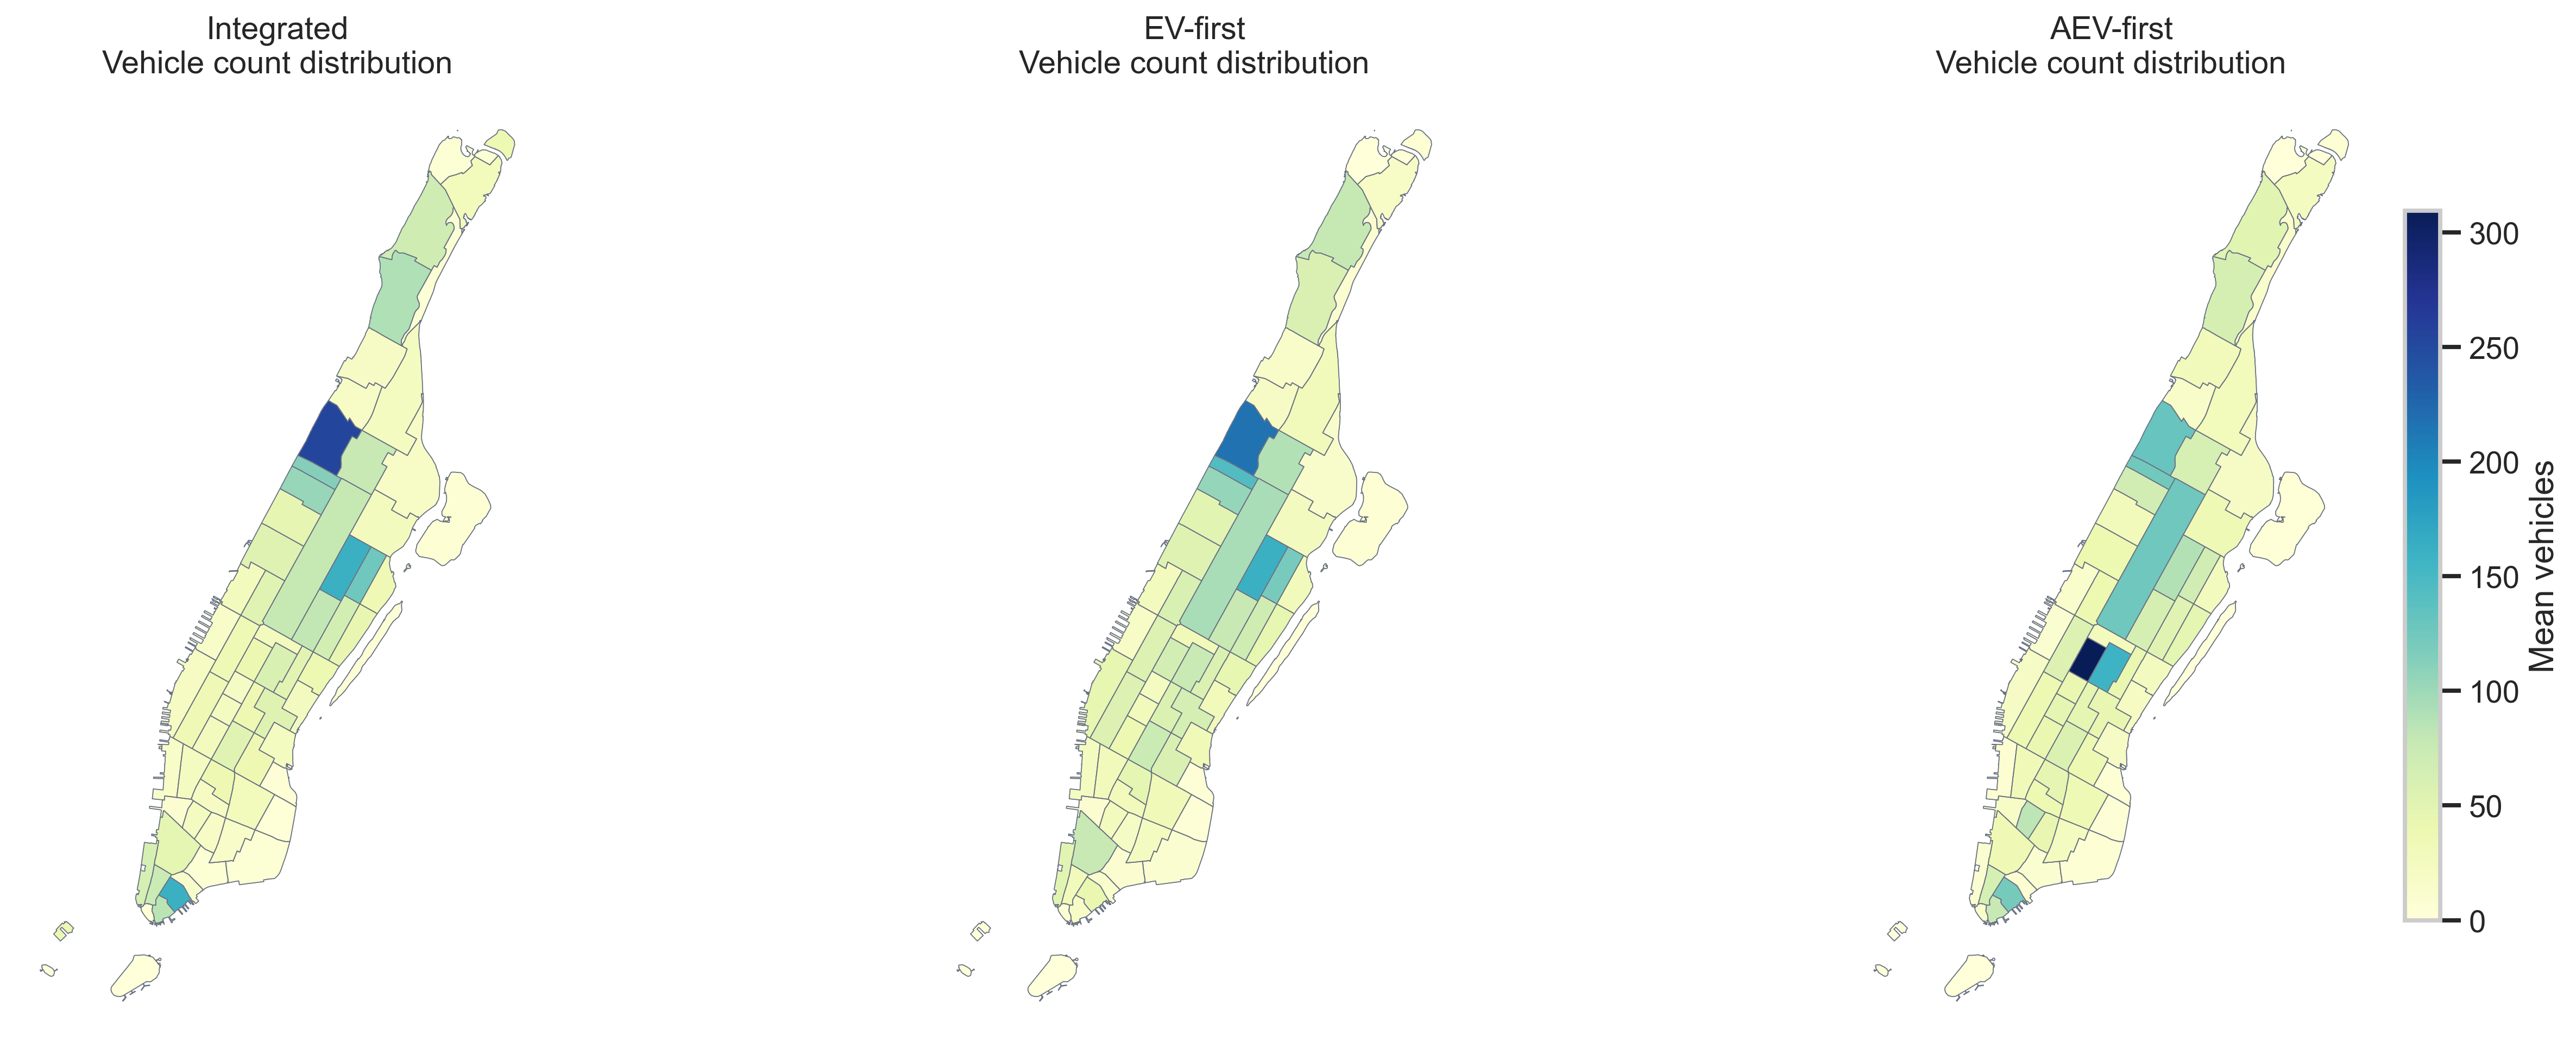

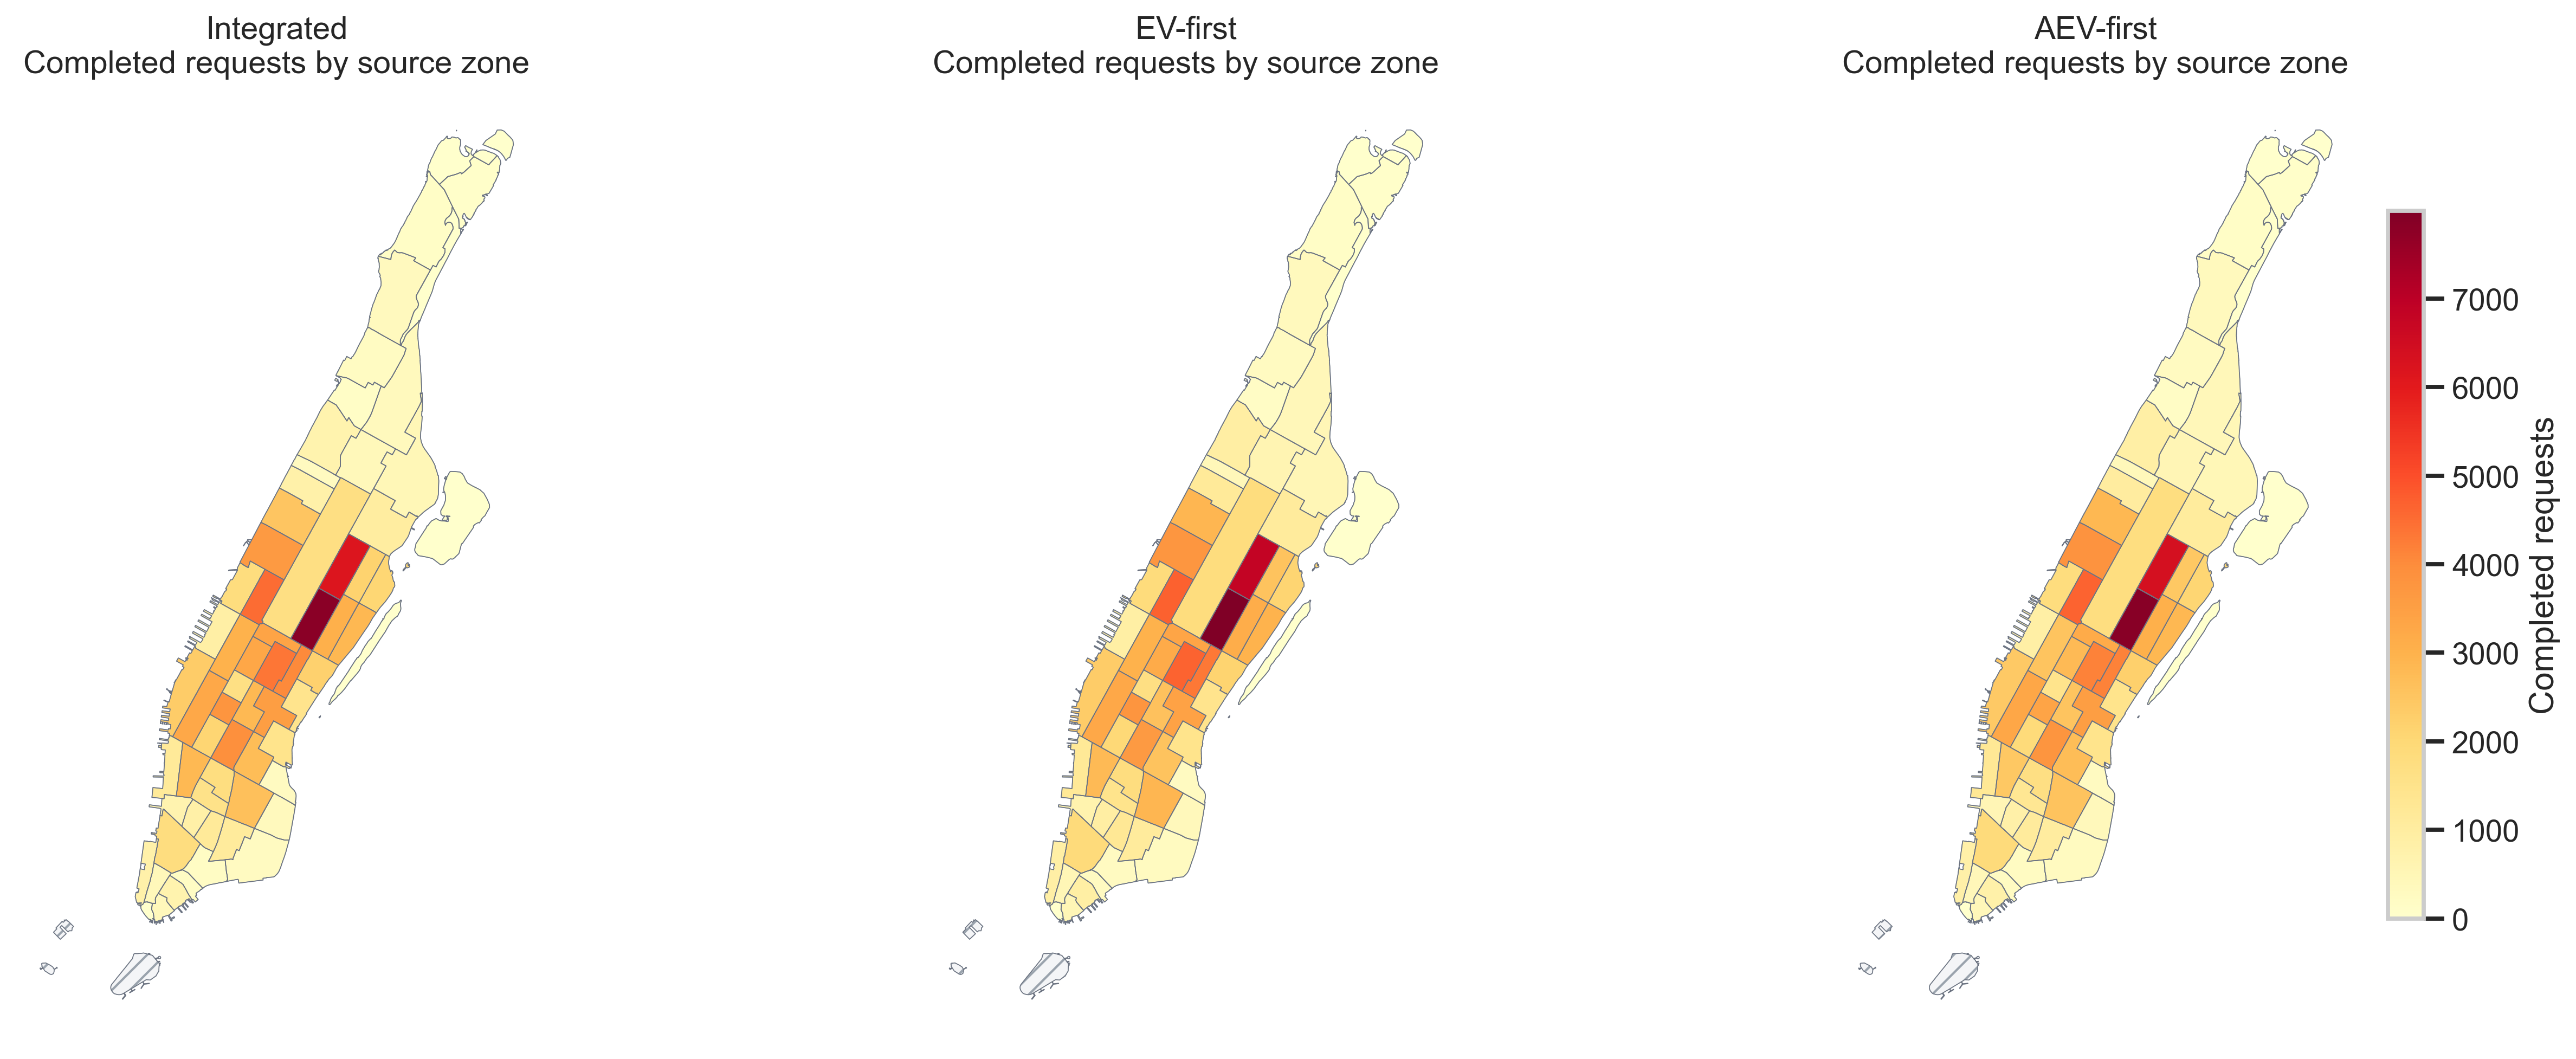

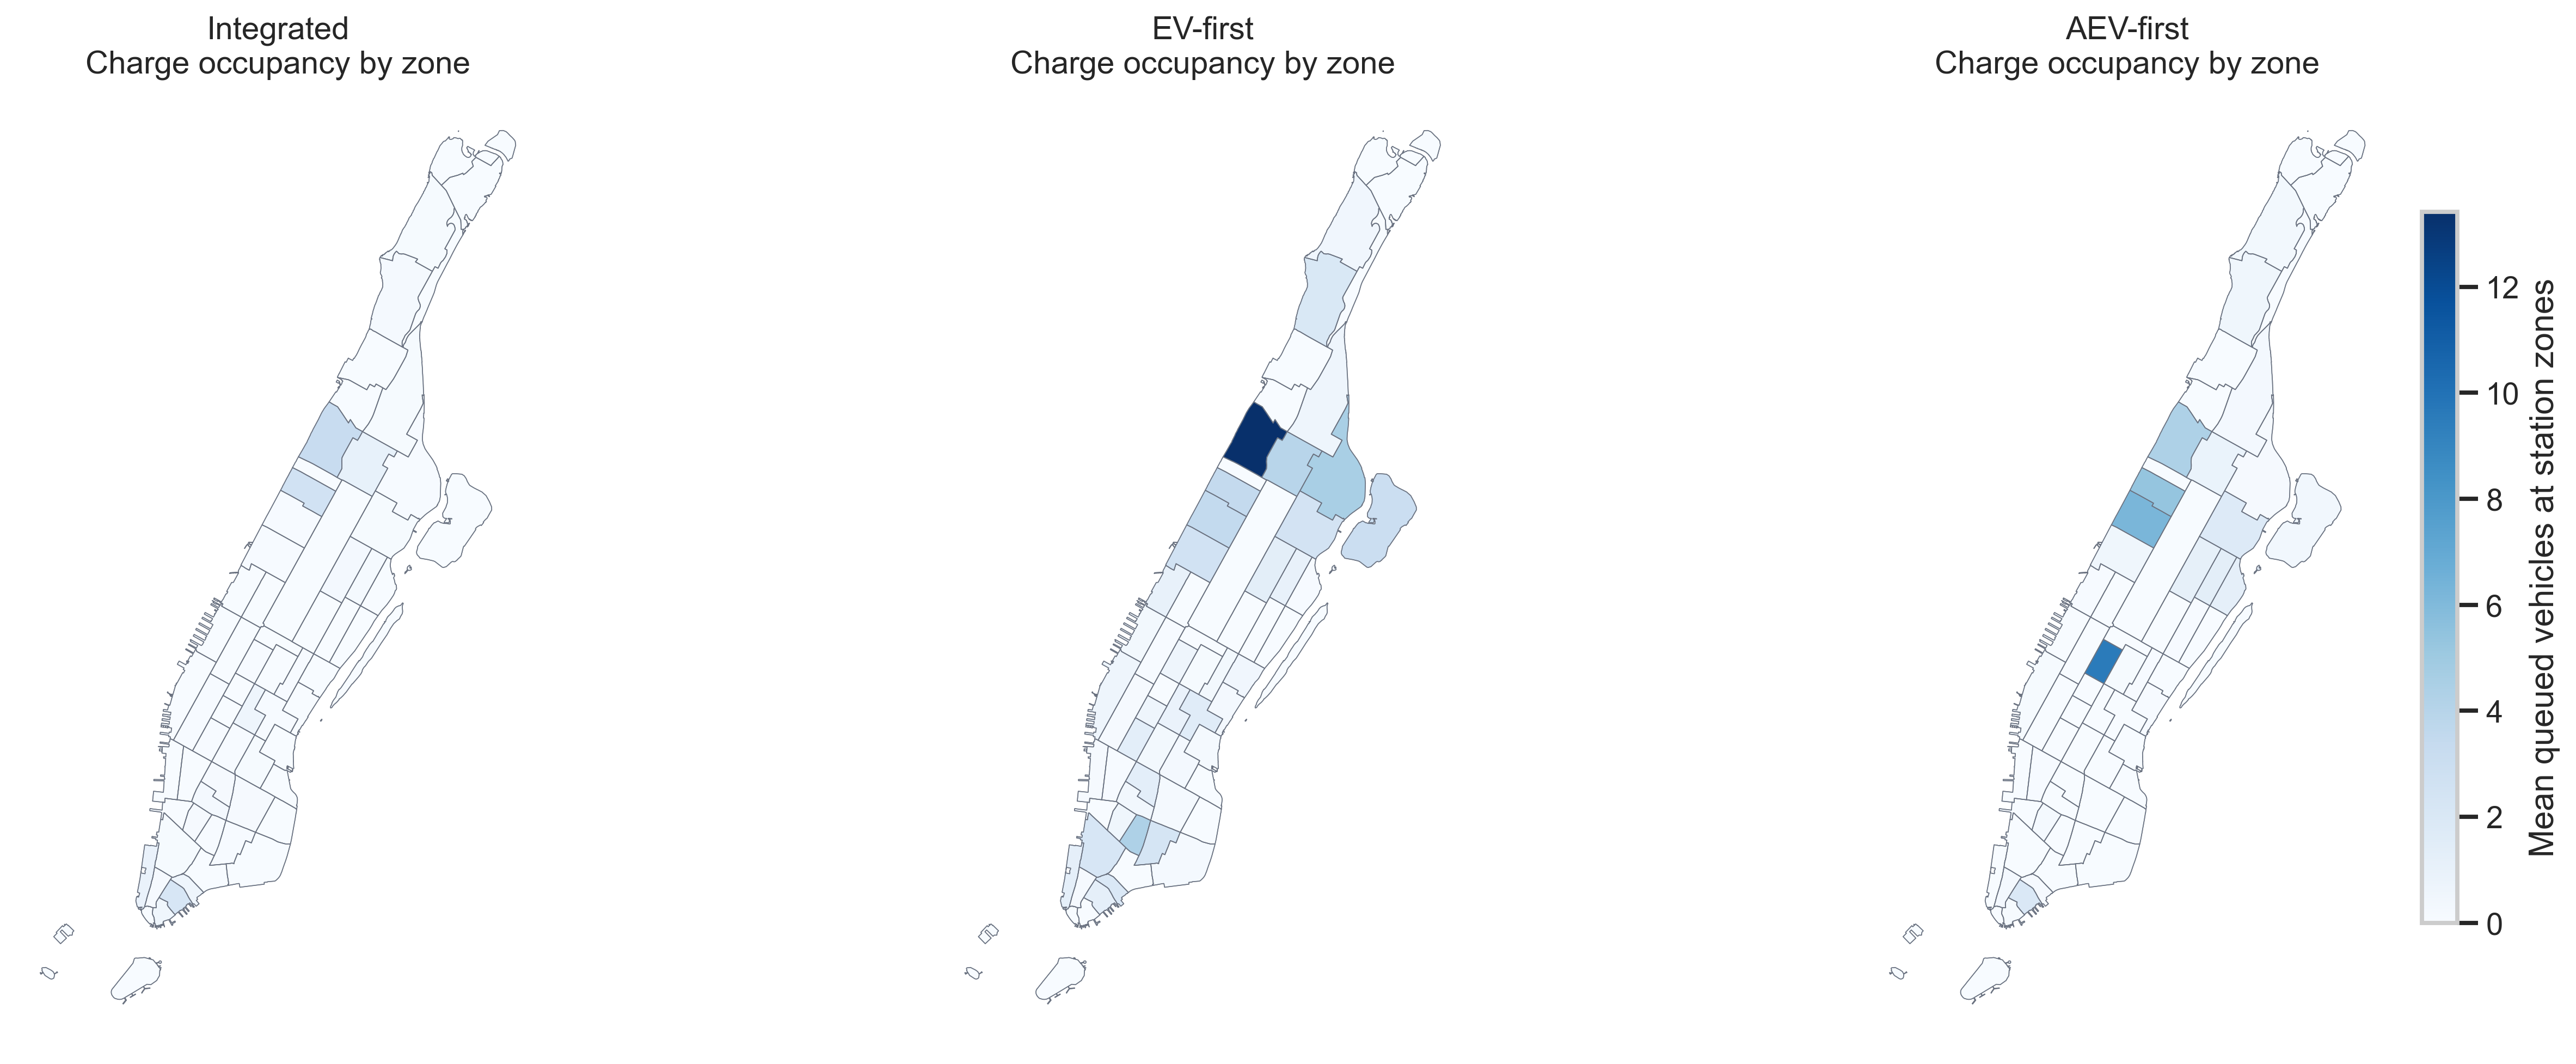

[PosixPath('results/nyc_masac_queue/manhattan_adp_mcmf_vehicle_distribution_1x3.png'),
 PosixPath('results/nyc_masac_queue/manhattan_adp_mcmf_completed_source_1x3.png'),
 PosixPath('results/nyc_masac_queue/manhattan_adp_mcmf_charge_occupancy_1x3.png')]

In [30]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

RESULT_FILES = {
    "Integrated": Path("results/nyc/nyc3000/nyc_3000_i.xlsx"),
    "EV-first": Path("results/nyc/nyc3000/nyc_3000_e.xlsx"),
    "AEV-first": Path("results/nyc/nyc3000/nyc_3000_a.xlsx"),
}
ZONE_GEOJSON = Path("nyedata/taxi_zones.geojson")
OUTPUT_DIR = Path("results/nyc_masac_queue")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ADP_MCMF_STRATEGY = "ADP-MCMF"

zones_gdf = gpd.read_file(ZONE_GEOJSON).copy()
loc_col = next((col for col in zones_gdf.columns if col.lower() in {"locationid", "location_id"}), None)
borough_col = next((col for col in zones_gdf.columns if col.lower() in {"borough", "boro_name", "boroname"}), None)
if loc_col is None or borough_col is None:
    raise KeyError(f"Could not find LocationID/borough columns in {ZONE_GEOJSON}: {zones_gdf.columns.tolist()}")

zones_gdf["zone_id"] = pd.to_numeric(zones_gdf[loc_col], errors="coerce")
manhattan_zones = zones_gdf[
    zones_gdf[borough_col].astype(str).str.strip().str.lower().eq("manhattan")
].copy()
manhattan_zones = manhattan_zones[manhattan_zones["zone_id"].notna()].copy()
manhattan_zones["zone_id"] = manhattan_zones["zone_id"].astype(int)
manhattan_zone_ids = set(manhattan_zones["zone_id"])


def _mode_metric_frame(workbook_path: Path, sheet_name: str, value_col: str, agg: str = "mean"):
    df = pd.read_excel(workbook_path, sheet_name=sheet_name).copy()
    df = df[df["strategy"].astype(str).eq(ADP_MCMF_STRATEGY)].copy()
    df = df[df["zone_id"].isin(manhattan_zone_ids)].copy()
    if df.empty:
        raise ValueError(f"No rows for {ADP_MCMF_STRATEGY} in {workbook_path}:{sheet_name}")
    grouped = (
        df.groupby("zone_id", as_index=False)[value_col]
        .agg(agg)
        .rename(columns={value_col: "metric_value"})
    )
    return manhattan_zones.merge(grouped, on="zone_id", how="left")


def _plot_adp_mcmf_1x3_maps(metric_spec):
    frames = {
        mode_label: _mode_metric_frame(
            workbook_path,
            metric_spec["sheet_name"],
            metric_spec["value_col"],
            metric_spec.get("agg", "mean"),
        )
        for mode_label, workbook_path in RESULT_FILES.items()
    }

    if metric_spec.get("fill_missing_with_zero", False):
        for frame in frames.values():
            frame["metric_value"] = frame["metric_value"].fillna(0.0)

    vmax = max(frame["metric_value"].fillna(0.0).max() for frame in frames.values())
    vmin = metric_spec.get("vmin", 0.0)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=max(float(vmax), 1e-9))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6.4), constrained_layout=True, dpi=300)
    for ax, (mode_label, frame) in zip(axes, frames.items()):
        frame.plot(
            column="metric_value",
            cmap=metric_spec["cmap"],
            linewidth=0.42,
            edgecolor="#7f8a99",
            ax=ax,
            legend=False,
            norm=norm,
            missing_kwds={"color": "#f4f5f7", "edgecolor": "#9aa3ad", "hatch": "///"},
        )
        manhattan_zones.boundary.plot(ax=ax, linewidth=0.32, color="#6b7280")
        ax.set_title(f"{mode_label}\n{metric_spec['title']}", fontsize=14)
        ax.set_axis_off()

    scalar_mappable = mpl.cm.ScalarMappable(norm=norm, cmap=metric_spec["cmap"])
    scalar_mappable.set_array([])
    fig.colorbar(
        scalar_mappable,
        ax=axes,
        shrink=0.74,
        pad=0.012,
        label=metric_spec["colorbar_label"],
    )
    output_path = OUTPUT_DIR / metric_spec["file_name"]
    fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path


MAP_SPECS = [
    {
        "sheet_name": "hourly_zone_vehicle_summary",
        "value_col": "mean_total_vehicles",
        "agg": "mean",
        "title": "Vehicle count distribution",
        "colorbar_label": "Mean vehicles",
        "cmap": "YlGnBu",
        "file_name": "manhattan_adp_mcmf_vehicle_distribution_1x3.png",
        "fill_missing_with_zero": True,
    },
    {
        "sheet_name": "daily_req_completion_detail",
        "value_col": "completed_requests",
        "agg": "mean",
        "title": "Completed requests by source zone",
        "colorbar_label": "Completed requests",
        "cmap": "YlOrRd",
        "file_name": "manhattan_adp_mcmf_completed_source_1x3.png",
        "fill_missing_with_zero": False,
    },
    {
        "sheet_name": "hourly_station_queue_summary",
        "value_col": "mean_queue_vehicle_count",
        "agg": "mean",
        "title": "Charge occupancy by zone",
        "colorbar_label": "Mean queued vehicles at station zones",
        "cmap": "Blues",
        "file_name": "manhattan_adp_mcmf_charge_occupancy_1x3.png",
        "fill_missing_with_zero": True,
    },
]

adp_mcmf_map_paths = [_plot_adp_mcmf_1x3_maps(spec) for spec in MAP_SPECS]
adp_mcmf_map_paths

In [31]:
strategy_order = ['ADP-MCMF','ADP-MCMF-FT', 'MCMF', 'MCMF-K', 'HEU', 'ADP-HEU']

In [32]:
data_nyc_integrated

,strategy,mode,seed,avg_reward,total_reward,episodes,total_orders,accept,reject,complete,...,hourly_zone_vehicle_counts,hourly_zone_vehicle_counts_json,hourly_completed_orders,hourly_completed_orders_json,peak_completed_date,peak_completed_hour,peak_completed_orders,acc_rate,mean_service_ratio_pct,mean_assignment_success_rate_pct
0,ADP-MCMF,integrated,256,3.522521e+06,3.522521e+06,1,128393,114548,19463,112746,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8097,89.216702,87.813199,85.476565
1,ADP-MCMF-FT,integrated,256,3.293362e+06,3.293362e+06,1,128393,113184,29899,111346,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8043,88.154339,86.722796,79.103737
2,ADP-HEU,integrated,256,2.612656e+06,2.612656e+06,1,128393,102263,61994,100092,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,7307,79.648423,77.957521,62.257925


In [33]:
data_nyc_integrated

,strategy,mode,seed,avg_reward,total_reward,episodes,total_orders,accept,reject,complete,...,hourly_zone_vehicle_counts,hourly_zone_vehicle_counts_json,hourly_completed_orders,hourly_completed_orders_json,peak_completed_date,peak_completed_hour,peak_completed_orders,acc_rate,mean_service_ratio_pct,mean_assignment_success_rate_pct
0,ADP-MCMF,integrated,256,3.522521e+06,3.522521e+06,1,128393,114548,19463,112746,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8097,89.216702,87.813199,85.476565
1,ADP-MCMF-FT,integrated,256,3.293362e+06,3.293362e+06,1,128393,113184,29899,111346,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8043,88.154339,86.722796,79.103737
2,ADP-HEU,integrated,256,2.612656e+06,2.612656e+06,1,128393,102263,61994,100092,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,7307,79.648423,77.957521,62.257925


In [34]:
data_nyc_heumcmf

,strategy,mode,seed,avg_reward,total_reward,episodes,total_orders,accept,reject,complete,...,hourly_zone_vehicle_counts,hourly_zone_vehicle_counts_json,hourly_completed_orders,hourly_completed_orders_json,peak_completed_date,peak_completed_hour,peak_completed_orders,acc_rate,mean_service_ratio_pct,mean_assignment_success_rate_pct
0,MCMF,integrated,256,2.357087e+06,2.357087e+06,1,128393,107561,58668,105220,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8045,83.774816,81.951508,64.706519
1,MCMF-K,integrated,256,2.124768e+06,2.124768e+06,1,128393,91552,53239,90637,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,16,6778,71.306068,70.593412,63.230449
2,HEU,integrated,256,2.227228e+06,2.227228e+06,1,128393,103465,56885,101533,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8213,80.584611,79.079856,64.524478
3,MCMF,evfirst,256,2.331031e+06,2.331031e+06,1,128393,108675,26141,107558,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,15,7291,84.642465,83.772480,80.609868
4,MCMF-K,evfirst,256,2.482421e+06,2.482421e+06,1,128393,117042,32579,115271,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,8079,91.159175,89.779817,78.225650
5,HEU,evfirst,256,2.514792e+06,2.514792e+06,1,128393,121791,41505,119656,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,20,8013,94.857975,93.195112,74.582966
6,MCMF,aevfirst,256,1.814908e+06,1.814908e+06,1,128393,78346,86823,77504,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,16,5911,61.020461,60.364662,47.433840
7,MCMF-K,aevfirst,256,1.913582e+06,1.913582e+06,1,128393,83239,75568,82425,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,16,6571,64.831416,64.197425,52.415196
8,HEU,aevfirst,256,2.518663e+06,2.518663e+06,1,128393,93527,75156,91533,...,"[{'date': Timestamp('2025-12-18 00:00:00'), 'h...","[{""date"": ""2025-12-18T00:00:00"", ""hour"": 0, ""z...","[{'completed_date': '2025-12-18 00:00:00', 'co...","[{""completed_date"": ""2025-12-18 00:00:00"", ""co...",2025-12-18 00:00:00,18,7517,72.844314,71.291270,55.445421


In [35]:
data_nyc_integrated = data_nyc_integrated[data_nyc_integrated['strategy'].isin(strategy_order)].copy().reset_index(drop=True)
data_nyc_ev = data_nyc_ev[data_nyc_ev['strategy'].isin(strategy_order)].copy().reset_index(drop=True)
data_nyc_aev = data_nyc_aev[data_nyc_aev['strategy'].isin(strategy_order)].copy().reset_index(drop=True)
data_nyc_heumcmf = data_nyc_heumcmf[data_nyc_heumcmf['strategy'].isin(strategy_order)].copy().reset_index(drop=True)

In [36]:
compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]

In [37]:
data_whole = pd.concat([data_nyc_integrated[compare_lists], data_nyc_ev[compare_lists], data_nyc_aev[compare_lists], data_nyc_heumcmf[compare_lists]], ignore_index=True, axis=0)
label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
label_map2 = {
    'ILP-K': 'MCMF-K',
}
mode_order = ['I', 'EF', 'AF']
data_5_origin = data_whole.copy().reset_index(drop=True)
data_5_origin['mode'] = data_5_origin['mode'].replace(label_map)
data_5_origin['strategy'] = data_5_origin['strategy'].replace(label_map2)
data_5_origin['mode'] = pd.Categorical(data_5_origin['mode'], categories=mode_order, ordered=True)
data_5_origin['strategy'] = pd.Categorical(data_5_origin['strategy'], categories=strategy_order, ordered=True)
data_5_origin = data_5_origin.sort_values(['mode', 'strategy']).reset_index(drop=True)
data_5_origin['mean_service_ratio'] = np.round(data_5_origin['mean_service_ratio'] * 100, 2)
data_5_origin['avg_battery_level'] = np.round(data_5_origin['avg_battery_level']*100, 2)
data_5_origin['avg_wait'] = data_5_origin['avg_wait']/2
num = 0
for i in range(data_5_origin.shape[0]):
    result = ""+str(num)+"&"
    for column in data_5_origin.columns:
        if column in ['strategy','mode']:
            result += f"{data_5_origin.iloc[i][column]} & "
        elif column in {'avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders'}:
            result += f"{data_5_origin.iloc[i][column]:.2e} & "
        else:
            result += f"{data_5_origin.iloc[i][column]:.2f} & "
    result = result.rstrip(" & ") + " \\\\"
    print(result)
    num += 1

0&ADP-MCMF & I & 3.52e+06 & 8.87e+05 & 2.64e+06 & 3.57e+04 & 7.70e+04 & 87.81 & 77.55 & 2.13 \\
1&ADP-MCMF-FT & I & 3.29e+06 & 8.39e+05 & 2.45e+06 & 4.22e+04 & 6.92e+04 & 86.72 & 79.28 & 1.40 \\
2&MCMF & I & 2.36e+06 & 1.06e+06 & 1.29e+06 & 5.36e+04 & 5.16e+04 & 81.95 & 54.69 & 10.18 \\
3&MCMF-K & I & 2.12e+06 & 7.78e+05 & 1.35e+06 & 2.62e+04 & 6.45e+04 & 70.59 & 47.86 & 19.88 \\
4&HEU & I & 2.23e+06 & 2.92e+05 & 1.93e+06 & 3.91e+04 & 6.25e+04 & 79.08 & 77.68 & 58.90 \\
5&ADP-HEU & I & 2.61e+06 & 5.22e+05 & 2.09e+06 & 1.95e+04 & 8.06e+04 & 77.96 & 63.65 & 5.53 \\
6&ADP-MCMF & EF & 2.94e+06 & 1.39e+06 & 1.55e+06 & 3.20e+04 & 8.52e+04 & 91.33 & 79.31 & 2.17 \\
7&ADP-MCMF-FT & EF & 3.05e+06 & 1.51e+06 & 1.54e+06 & 3.24e+04 & 8.48e+04 & 91.26 & 78.99 & 1.87 \\
8&MCMF & EF & 2.33e+06 & 1.14e+06 & 1.19e+06 & 3.65e+04 & 7.10e+04 & 83.77 & 47.89 & 14.64 \\
9&MCMF-K & EF & 2.48e+06 & 1.45e+06 & 1.03e+06 & 4.55e+04 & 6.98e+04 & 89.78 & 49.81 & 11.36 \\
10&HEU & EF & 2.51e+06 & 1.01e+06 & 1.50e+0

In [38]:
data_whole

,strategy,mode,avg_reward,episode_reward_ev,episode_reward_aev,mean_ev_completed_orders,mean_aev_completed_orders,mean_service_ratio,avg_battery_level,avg_wait
0,ADP-MCMF,integrated,3.522521e+06,8.874958e+05,2.635025e+06,35737,77009,0.878132,0.775499,4.266954
1,ADP-MCMF-FT,integrated,3.293362e+06,8.386867e+05,2.454675e+06,42159,69187,0.867228,0.792765,2.793584
2,ADP-HEU,integrated,2.612656e+06,5.222670e+05,2.090389e+06,19480,80612,0.779575,0.636545,11.061067
3,ADP-MCMF,evfirst,2.940205e+06,1.394997e+06,1.545208e+06,32050,85208,0.913274,0.793069,4.333470
4,ADP-MCMF-FT,evfirst,3.048349e+06,1.507500e+06,1.540849e+06,32410,84764,0.912620,0.789900,3.746507
5,ADP-HEU,evfirst,2.903339e+06,1.394575e+06,1.508764e+06,34163,75803,0.856480,0.724563,14.361157
6,ADP-MCMF,aevfirst,2.950642e+06,-2.011612e+05,3.151803e+06,10727,101614,0.874978,0.636126,18.268134
7,ADP-MCMF-FT,aevfirst,2.788389e+06,-1.858419e+05,2.974230e+06,12036,98101,0.857812,0.601677,6.386242
8,ADP-HEU,aevfirst,2.710844e+06,-6.370466e+04,2.774549e+06,18984,75911,0.739098,0.535440,26.724059
9,MCMF,integrated,2.357087e+06,1.063755e+06,1.293332e+06,53572,51648,0.819515,0.546941,20.357068


In [39]:
import requests
import time
from pathlib import Path

def download_parquet(year, month, save_dir="nyedata/parquet"):
    str_ym = f"{year}-{month:02d}"
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{str_ym}.parquet"
    save_path = Path(save_dir) / f"yellow_tripdata_{str_ym}.parquet"
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    if save_path.exists():
        print(f"✅ 文件已存在: {save_path} ({save_path.stat().st_size/1e6:.1f} MB)")
        return save_path

    print(f"📥 下载: {url}")
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    downloaded = 0
    t0 = time.time()
    with open(save_path, 'wb') as f:
        for chunk in r.iter_content(65536):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded / total * 100
                    speed = downloaded / 1e6 / max(time.time() - t0, 1e-9)
                    print(f"\r  {pct:.1f}%  {downloaded/1e6:.1f}/{total/1e6:.1f} MB  {speed:.1f} MB/s", end="")
    print(f"\n✅ 完成 ({downloaded/1e6:.1f} MB, {time.time()-t0:.1f}s)")
    return save_path

parquet_path = download_parquet(2025, 12)
print(f"parquet_path = {parquet_path}")

✅ 文件已存在: nyedata/parquet/yellow_tripdata_2025-12.parquet (73.7 MB)
parquet_path = nyedata/parquet/yellow_tripdata_2025-12.parquet


In [40]:
import geopandas as gpd
import zipfile, io
from pathlib import Path

# ── 1. TLC Taxi Zone Shapefile ────────────────────────────────────────────────
SHP_DIR  = Path("nyedata/taxi_zones_shp")
GEO_PATH = Path("nyedata/taxi_zones.geojson")

if not GEO_PATH.exists():
    shp_files = list(SHP_DIR.rglob("*.shp"))
    if shp_files:
        gdf_tmp = gpd.read_file(shp_files[0]).to_crs(epsg=4326)
        gdf_tmp.to_file(GEO_PATH, driver="GeoJSON")
        print(f"✅ 已转存 GeoJSON: {GEO_PATH}")
    else:
        resp = requests.get("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip", timeout=120)
        resp.raise_for_status()
        SHP_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            zf.extractall(SHP_DIR)
        shp_files = list(SHP_DIR.rglob("*.shp"))
        gdf_tmp = gpd.read_file(shp_files[0]).to_crs(epsg=4326)
        gdf_tmp.to_file(GEO_PATH, driver="GeoJSON")
        print(f"✅ 已转存 GeoJSON: {GEO_PATH}")
else:
    print(f"✅ TLC GeoJSON 已存在: {GEO_PATH}")

zones_gdf = gpd.read_file(GEO_PATH)
if zones_gdf.crs is None or zones_gdf.crs.to_epsg() != 4326:
    zones_gdf = zones_gdf.to_crs(epsg=4326)

loc_col = next((c for c in zones_gdf.columns if c.lower() in ("locationid", "location_id")), None)
if loc_col is None:
    loc_col = [c for c in zones_gdf.columns if c != "geometry"][0]
zones_gdf["zone_id"] = pd.to_numeric(zones_gdf[loc_col], errors="coerce")
print(f"TLC 区域数: {zones_gdf['zone_id'].notna().sum()}")

✅ TLC GeoJSON 已存在: nyedata/taxi_zones.geojson
TLC 区域数: 263


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Load parquet for the full day
trip_df = pd.read_parquet(
    parquet_path,
    columns=["tpep_pickup_datetime", "PULocationID", "DOLocationID"],
)
trip_df = trip_df[trip_df["PULocationID"] != trip_df["DOLocationID"]].copy()
trip_df["pickup_datetime"] = pd.to_datetime(trip_df["tpep_pickup_datetime"])
print(f"Valid demand rows: {len(trip_df):,}")
# Manhattan-only demand analysis based on pickup and dropoff zones
from shapely import contains_xy

borough_col = next(
    (col for col in zones_gdf.columns if col.lower() in {"borough", "boro_name", "boroname"}),
    None,
)
if borough_col is None:
    raise KeyError(f"Could not find borough column in zones_gdf: {zones_gdf.columns.tolist()}")

manhattan_zones = zones_gdf[
    zones_gdf[borough_col].astype(str).str.strip().str.lower().eq("manhattan")
].copy()
manhattan_zone_ids = set(manhattan_zones["zone_id"].dropna().astype(int))
manhattan_shape = manhattan_zones.union_all() if hasattr(manhattan_zones, "union_all") else manhattan_zones.unary_union
manhattan_trip_df = trip_df[
    trip_df["PULocationID"].isin(manhattan_zone_ids)
    & trip_df["DOLocationID"].isin(manhattan_zone_ids)
] .copy()

Valid demand rows: 4,095,915


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


/var/folders/c1/nn1rtg8915lb_x0l9qqmyytr0000gn/T/ipykernel_20444/3682363379.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['mode_label', 'completed_hour'], as_index=False)['completed_orders']


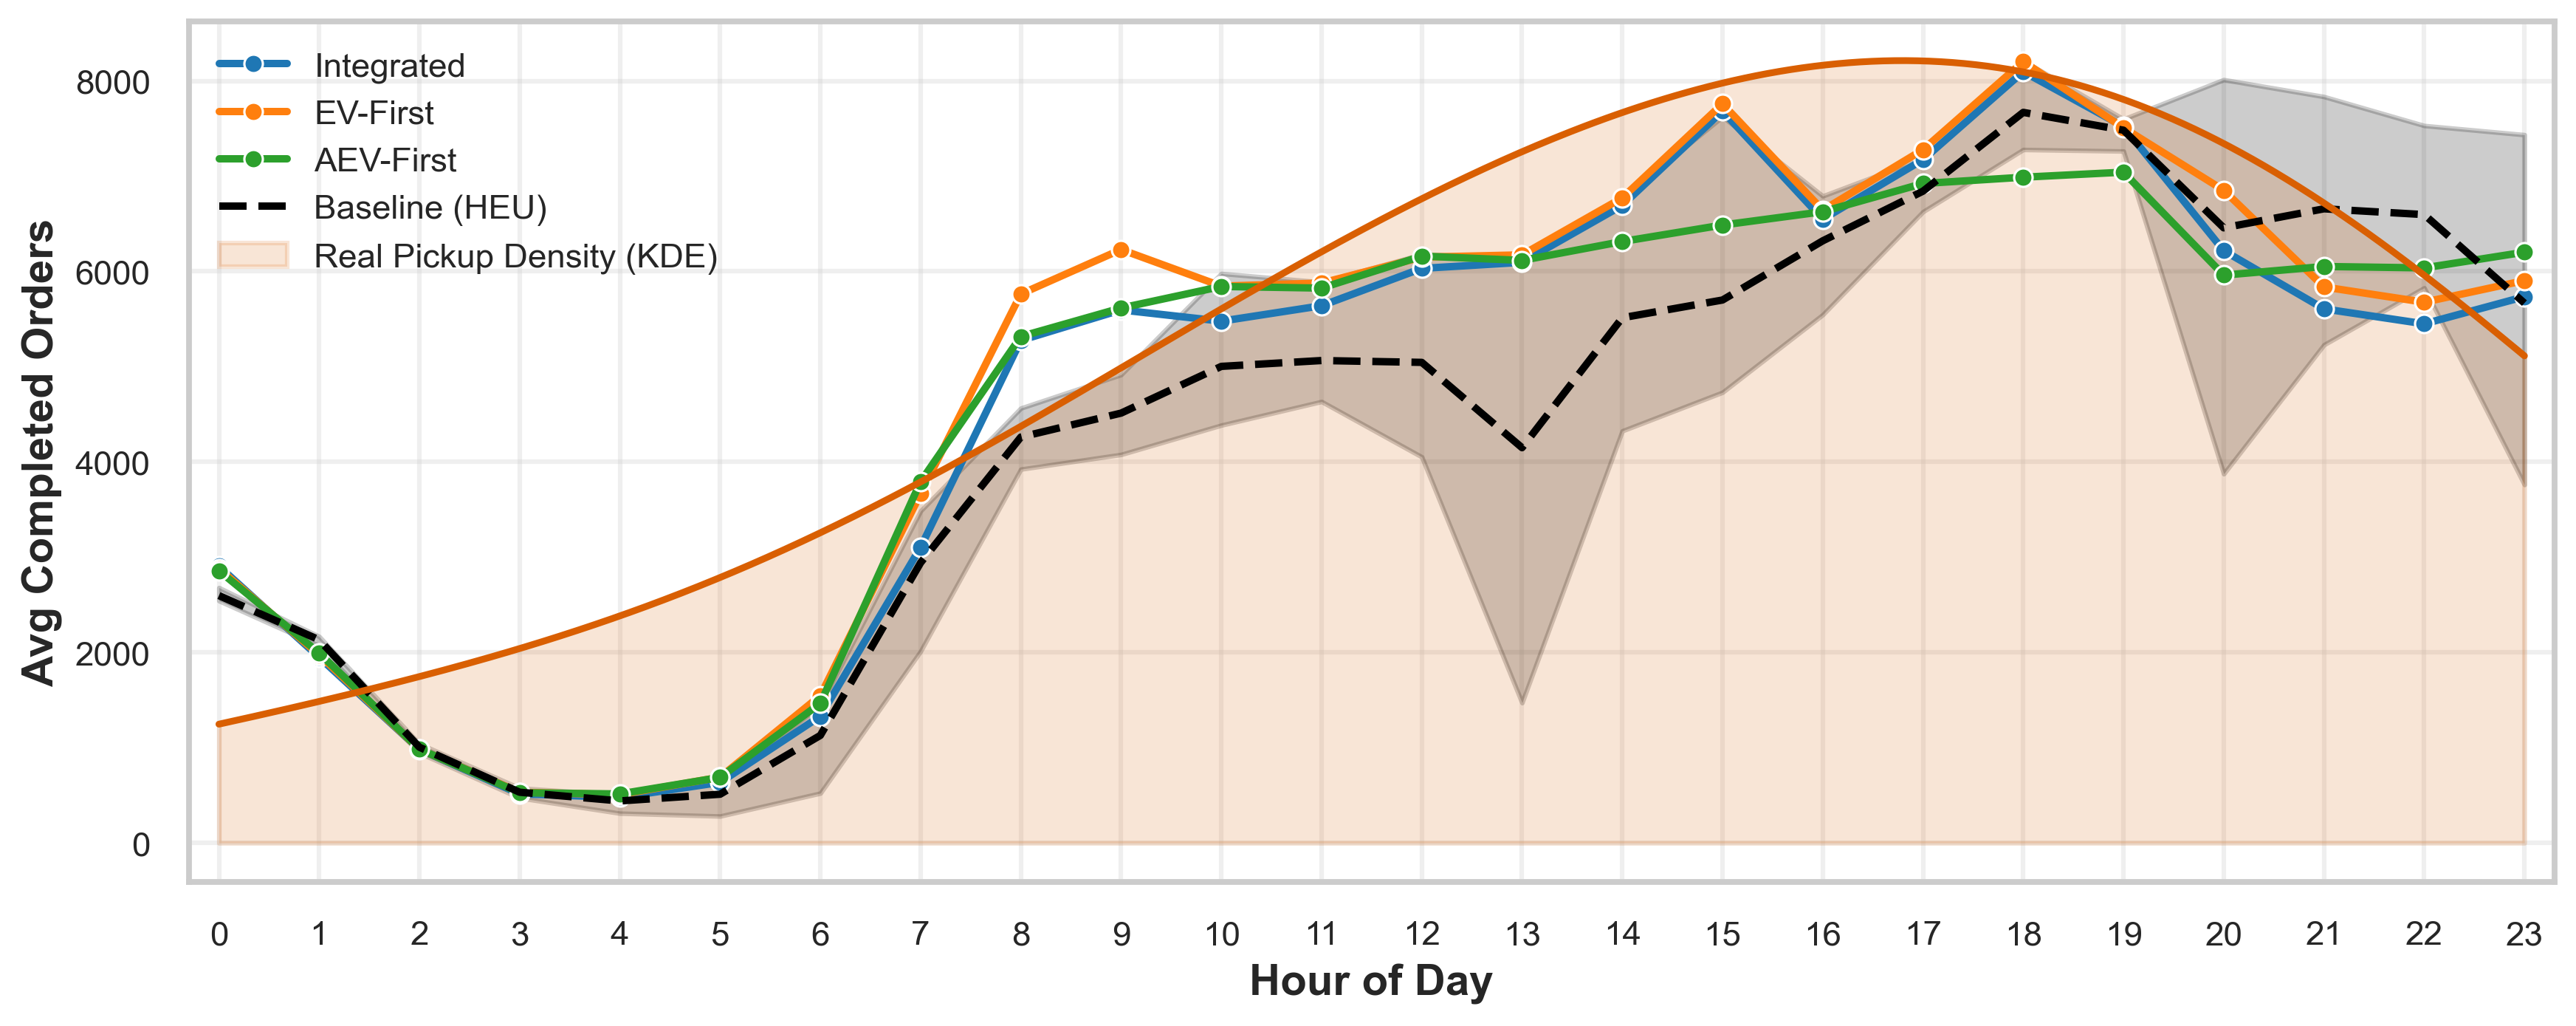

In [42]:
manhattan_hour_df = manhattan_trip_df.copy()
manhattan_hour_df["hour_float"] = (
    manhattan_hour_df["pickup_datetime"].dt.hour
    + manhattan_hour_df["pickup_datetime"].dt.minute / 60.0
    + manhattan_hour_df["pickup_datetime"].dt.second / 3600.0
)


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

# --- 准备三个模式的每小时完成订单数据 ---
mode_label_map = {'integrated': 'Integrated', 'evfirst': 'EV-First', 'aevfirst': 'AEV-First'}
palette = {'Integrated': '#1f77b4', 'EV-First': '#ff7f0e', 'AEV-First': '#2ca02c'}
baseline = data_nyc_heumcmf_hour[data_nyc_heumcmf_hour['strategy'] == 'HEU'].copy()
dfs = []
for df_raw, tag in [
    (data_nyc_integrated_hour, 'integrated'),
    (data_nyc_ev_hour,         'evfirst'),
    (data_nyc_aev_hour,        'aevfirst'),
]:
    tmp = df_raw[df_raw['strategy'] == 'ADP-MCMF'].copy()
    tmp['mode_label'] = mode_label_map.get(tag, tag)
    dfs.append(tmp)

hourly_df = pd.concat(dfs, ignore_index=True)
hourly_df['mode_label'] = pd.Categorical(
    hourly_df['mode_label'],
    categories=['Integrated', 'EV-First', 'AEV-First'],
    ordered=True,
)
hourly_agg = (
    hourly_df
    .groupby(['mode_label', 'completed_hour'], as_index=False)['completed_orders']
    .mean()
)
hourly_request_profile = (
    manhattan_hour_df.assign(hour_bin=manhattan_hour_df['pickup_datetime'].dt.hour)
    .groupby('hour_bin')
    .size()
    .rename('request_count')
    .reset_index()
)

# --- 绘图 ---
sns.set_theme(style='whitegrid', context='talk', font_scale=1.05)
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

sns.lineplot(
    data=hourly_agg,
    x='completed_hour',
    y='completed_orders',
    hue='mode_label',
    hue_order=['Integrated', 'EV-First', 'AEV-First'],
    palette=palette,
    marker='o',
    markersize=6,
    linewidth=2.4,
    ax=ax,
)
sns.lineplot(
    data=baseline,
    x='completed_hour',
    y='completed_orders',
    color='black',
    linestyle='--',
    linewidth=2.4,
    label='Baseline (HEU)',
    ax=ax,
)

_hours = sorted(hourly_agg['completed_hour'].unique())
left_y_max = max(hourly_agg['completed_orders'].max(), baseline['completed_orders'].max())
hourly_request_profile['scaled_request_count'] = (
    hourly_request_profile['request_count'] / hourly_request_profile['request_count'].max() * left_y_max
)
kde_x = np.linspace(_hours[0], _hours[-1], 400)
kde_y = gaussian_kde(manhattan_hour_df['hour_float'], bw_method=0.7)(kde_x)
kde_y = kde_y / kde_y.max() * left_y_max

ax.fill_between(kde_x, kde_y, color='#d95f02', alpha=0.16, label='Real Pickup Density (KDE)')
ax.plot(kde_x, kde_y, color='#d95f02', linewidth=2.2)

ax.set_xlabel('Hour of Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Completed Orders', fontsize=14, fontweight='bold')
# ax.set_title('Hourly Completed Orders by Different Modes in NYC Datset (2025-12-25)', fontsize=15, fontweight='bold')
ax.set_xticks(_hours)
ax.set_xlim(_hours[0] - 0.3, _hours[-1] + 0.3)
ax.tick_params(axis='both', labelsize=11)
ax.legend(loc='upper left', fontsize=11, frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/nyc/nyc3000/hourly_completed_orders.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/c1/nn1rtg8915lb_x0l9qqmyytr0000gn/T/ipykernel_20444/3597717376.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["strategy_label", "mode_label", "completed_hour"], as_index=False)["completed_orders"]


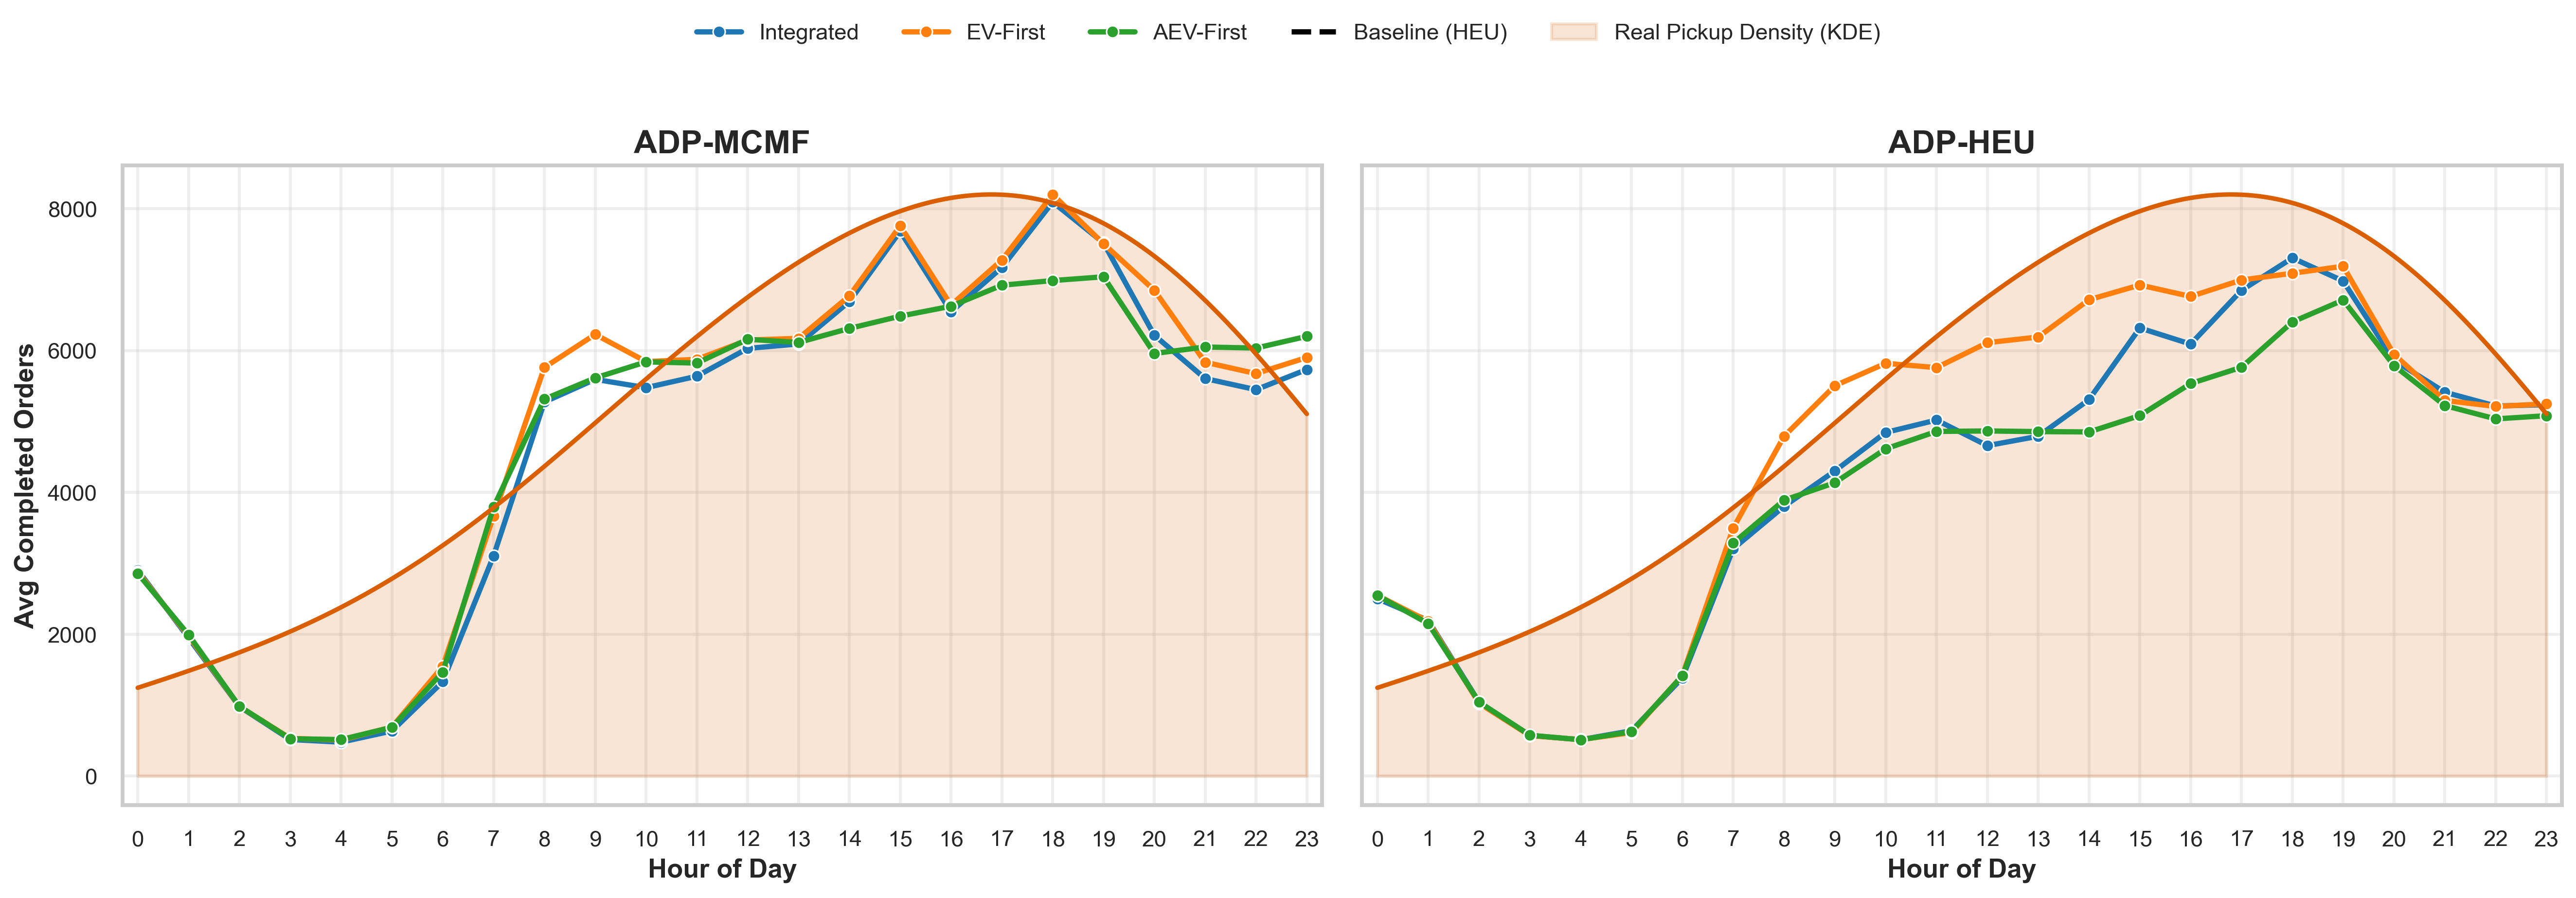

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

manhattan_hour_df = manhattan_trip_df.copy()
manhattan_hour_df["hour_float"] = (
    manhattan_hour_df["pickup_datetime"].dt.hour
    + manhattan_hour_df["pickup_datetime"].dt.minute / 60.0
    + manhattan_hour_df["pickup_datetime"].dt.second / 3600.0
)

mode_label_map = {
    "integrated": "Integrated",
    "evfirst": "EV-First",
    "aevfirst": "AEV-First",
}
palette = {
    "Integrated": "#1f77b4",
    "EV-First": "#ff7f0e",
    "AEV-First": "#2ca02c",
}
strategy_title_map = {
    "ADP-MCMF": "ADP-MCMF",
    "ADP-HEU": "ADP-HEU",
}
mode_order = ["Integrated", "EV-First", "AEV-First"]
strategy_order = ["ADP-MCMF", "ADP-HEU"]

baseline = data_nyc_integrated_hour[data_nyc_integrated_hour["strategy"] == "HEU"].copy()

plot_rows = []
for strategy in strategy_order:
    for df_raw, tag in [
        (data_nyc_integrated_hour, "integrated"),
        (data_nyc_ev_hour, "evfirst"),
        (data_nyc_aev_hour, "aevfirst"),
    ]:
        tmp = df_raw[df_raw["strategy"] == strategy].copy()
        if tmp.empty:
            continue
        tmp["mode_label"] = mode_label_map.get(tag, tag)
        tmp["strategy_label"] = strategy_title_map[strategy]
        plot_rows.append(tmp)

plot_df = pd.concat(plot_rows, ignore_index=True)
plot_df["mode_label"] = pd.Categorical(plot_df["mode_label"], categories=mode_order, ordered=True)
plot_df["strategy_label"] = pd.Categorical(
    plot_df["strategy_label"],
    categories=[strategy_title_map[s] for s in strategy_order],
    ordered=True,
)

hourly_agg = (
    plot_df
    .groupby(["strategy_label", "mode_label", "completed_hour"], as_index=False)["completed_orders"]
    .mean()
)

hours = sorted(hourly_agg["completed_hour"].unique())
left_y_max = max(
    hourly_agg["completed_orders"].max(),
    baseline["completed_orders"].max(),
)

kde_x = np.linspace(hours[0], hours[-1], 400)
kde_y = gaussian_kde(manhattan_hour_df["hour_float"], bw_method=0.7)(kde_x)
kde_y = kde_y / kde_y.max() * left_y_max

sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=300, sharex=True, sharey=True)

for ax, strategy_label in zip(axes, [strategy_title_map[s] for s in strategy_order]):
    subset = hourly_agg[hourly_agg["strategy_label"] == strategy_label]
    sns.lineplot(
        data=subset,
        x="completed_hour",
        y="completed_orders",
        hue="mode_label",
        hue_order=mode_order,
        palette=palette,
        marker="o",
        markersize=6,
        linewidth=2.6,
        ax=ax,
    )
    sns.lineplot(
        data=baseline,
        x="completed_hour",
        y="completed_orders",
        color="black",
        linestyle="--",
        linewidth=2.6,
        label="Baseline (HEU)",
        ax=ax,
    )
    ax.fill_between(kde_x, kde_y, color="#d95f02", alpha=0.16, label="Real Pickup Density (KDE)")
    ax.plot(kde_x, kde_y, color="#d95f02", linewidth=2.2)
    ax.set_title(strategy_label, fontsize=16, fontweight="bold")
    ax.set_xlabel("Hour of Day", fontsize=13, fontweight="bold")
    ax.set_xticks(hours)
    ax.set_xlim(hours[0] - 0.3, hours[-1] + 0.3)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Avg Completed Orders", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.05), fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("results/nyc/nyc3000/hourly_completed_orders_adp_mcmf_vs_heu.png", dpi=300, bbox_inches="tight")
plt.show()

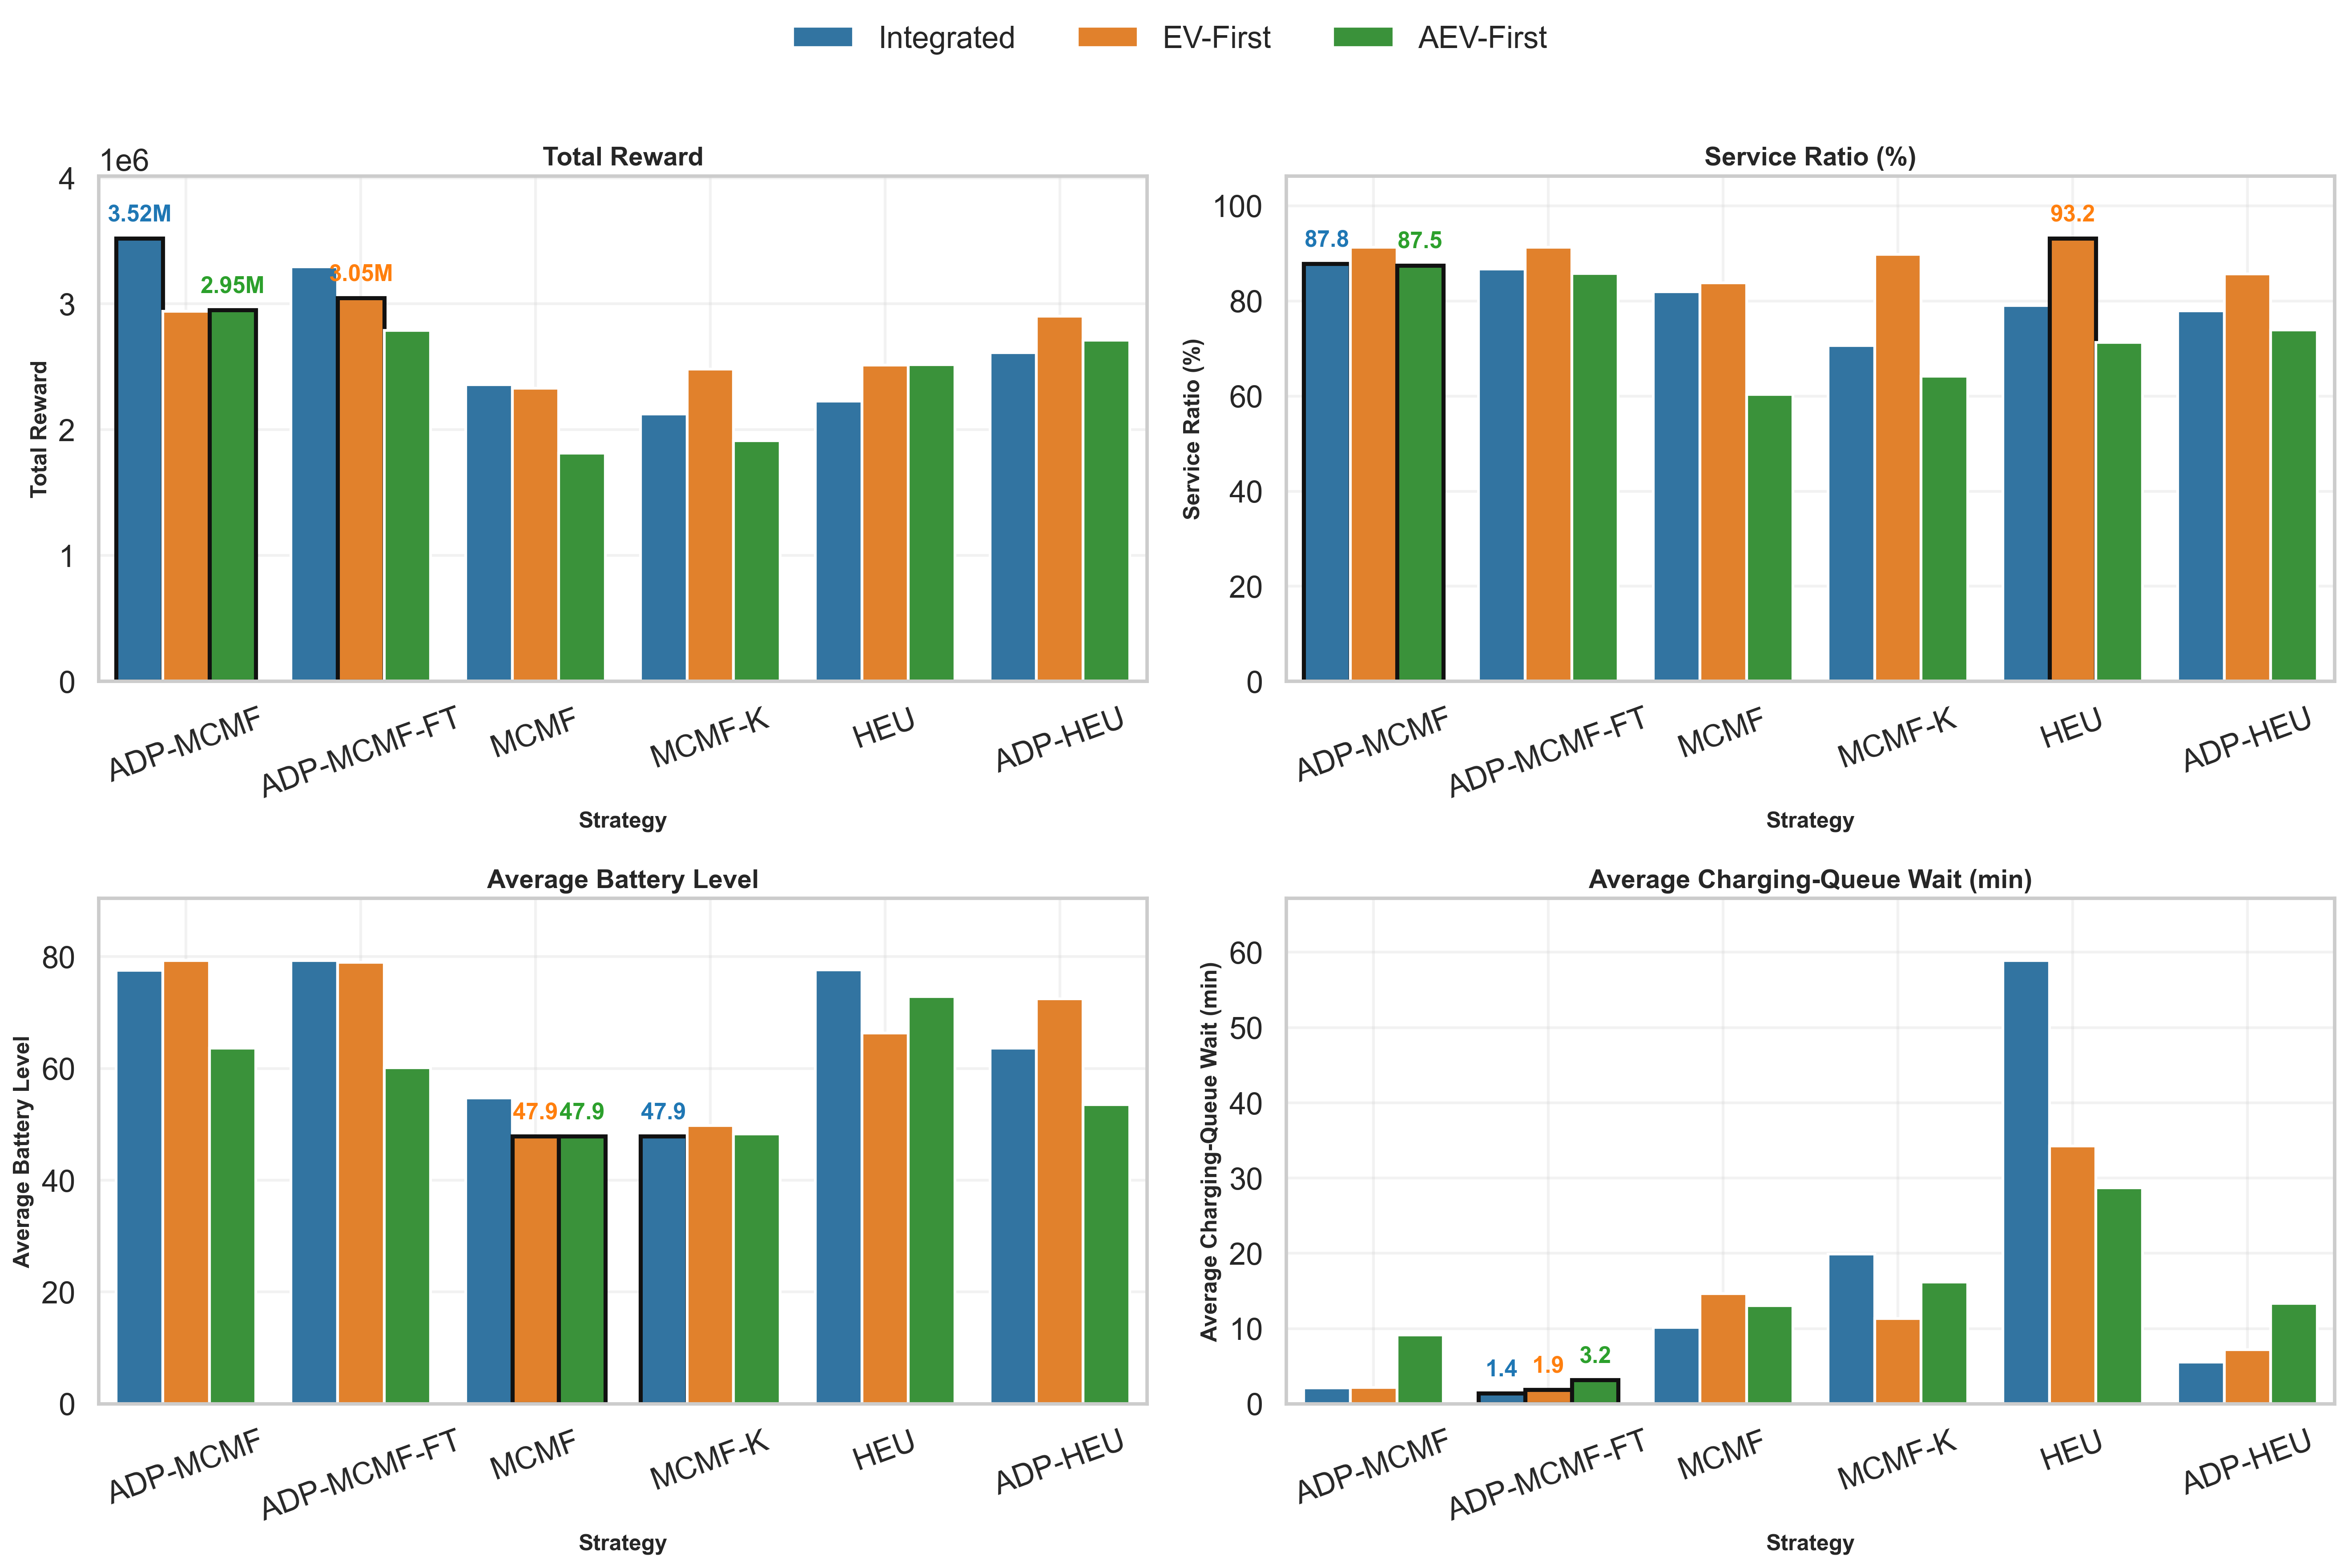

In [44]:

from matplotlib.container import BarContainer

label_map = {
    'aevfirst': 'AF',
    'evfirst': 'EF',
    'integrated': 'I',
}
label_map2 = {
    'ILP-K': 'MCMF-K',
}
strategy_order = ['ADP-MCMF', 'ADP-MCMF-FT','MCMF', 'MCMF-K', 'HEU',  'ADP-HEU']
mode_order = ['I', 'EF', 'AF']
data_5_origin = data_whole.copy().reset_index(drop=True)
data_5_origin['mode'] = data_5_origin['mode'].replace(label_map)
data_5_origin['strategy'] = data_5_origin['strategy'].replace(label_map2)
data_5_origin['mode'] = pd.Categorical(data_5_origin['mode'], categories=mode_order, ordered=True)
data_5_origin['strategy'] = pd.Categorical(data_5_origin['strategy'], categories=strategy_order, ordered=True)
data_5_origin = data_5_origin.sort_values(['mode', 'strategy']).reset_index(drop=True)
data_5_origin['mean_service_ratio'] = np.round(data_5_origin['mean_service_ratio'] * 100, 2)
data_5_origin['avg_battery_level'] = np.round(data_5_origin['avg_battery_level']*100, 2)
data_5_origin['avg_wait_min'] = data_5_origin['avg_wait'].astype(float) * 0.5  # NYC epoch = 30 s


data_nyc_integrated = data_5_origin[data_5_origin['mode']=='I'].copy()
data_nyc_ev = data_5_origin[data_5_origin['mode']=='EF'].copy()
data_nyc_aev = data_5_origin[data_5_origin['mode']=='AF'].copy()
mode_frames = {
    'Integrated': data_nyc_integrated.copy(),
    'EV-First': data_nyc_ev.copy(),
    'AEV-First': data_nyc_aev.copy(),
}




hourly_frames = {
    'Integrated': data_nyc_integrated_hour.copy(),
    'EV-First': data_nyc_ev_hour.copy(),
    'AEV-First': data_nyc_aev_hour.copy(),
}

palette = {
    'Integrated': '#1f77b4',
    'EV-First': '#ff7f0e',
    'AEV-First': '#2ca02c',
}
mode_order = ['Integrated', 'EV-First', 'AEV-First']

common_strategies = sorted(set.intersection(*(set(df['strategy'].dropna().unique()) for df in mode_frames.values())))

plot_rows = []
for source_mode, df in mode_frames.items():
    df = df[df['strategy'].isin(common_strategies)].copy()
    numeric_cols = df.select_dtypes(include='number').columns
    agg = df.groupby('strategy', as_index=False, observed=True)[numeric_cols].mean(numeric_only=True)
    agg['source_mode'] = source_mode
    plot_rows.append(agg)

detail_plot_df = pd.concat(plot_rows, ignore_index=True)

metric_map = {
    'avg_reward': 'Total Reward',
    'mean_service_ratio': 'Service Ratio (%)',
    'avg_battery_level': 'Average Battery Level',
    'avg_wait_min': 'Average Charging-Queue Wait (min)',
}
best_direction = {
    'avg_reward': 'max',
    'mean_service_ratio': 'max',
    'avg_battery_level': 'min',
    'avg_wait_min': 'min',
}

def format_best_value(metric, value):
    if metric == 'avg_reward':
        return f'{value / 1e6:.2f}M'
    return f'{value:.1f}'
available_metrics = [col for col in metric_map if col in detail_plot_df.columns]

if not available_metrics:
    raise ValueError('No expected comparison metrics found in the detail sheets.')

fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=300)
axes = axes.flatten()

for ax, metric in zip(axes, available_metrics):
    sns.barplot(
        data=detail_plot_df,
        x='strategy',
        y=metric,
        hue='source_mode',
        hue_order=mode_order,
        order=strategy_order,
        palette=palette,
        ax=ax,
    )

    # Mark the requested mode-wise extreme: max reward/service, min battery/wait.
    bar_containers = [container for container in ax.containers if isinstance(container, BarContainer)]
    for mode_idx, source_mode in enumerate(mode_order):
        mode_data = detail_plot_df[detail_plot_df['source_mode'] == source_mode].dropna(subset=[metric])
        if mode_data.empty or mode_idx >= len(bar_containers):
            continue
        if best_direction[metric] == 'max':
            best_row = mode_data.loc[mode_data[metric].idxmax()]
        else:
            best_row = mode_data.loc[mode_data[metric].idxmin()]
        best_strategy = str(best_row['strategy'])
        if best_strategy not in strategy_order:
            continue
        strategy_idx = strategy_order.index(best_strategy)
        container = bar_containers[mode_idx]
        if strategy_idx >= len(container):
            continue
        best_bar = container[strategy_idx]
        best_value = float(best_row[metric])
        best_bar.set_edgecolor('#111111')
        best_bar.set_linewidth(2.2)
        ax.annotate(
            format_best_value(metric, best_value),
            xy=(best_bar.get_x() + best_bar.get_width() / 2, best_bar.get_height()),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=12.5,
            fontweight='bold',
            color=palette[source_mode],
            clip_on=False,
        )
    ax.set_title(metric_map[metric], fontsize=14, fontweight='bold')
    ax.set_xlabel('Strategy', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_map[metric], fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, alpha=0.25)
    ax.margins(y=0.14)

for ax in axes[len(available_metrics):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0.025, 1, 0.95])
plt.savefig('results/nyc/nyc3000/nyc_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
data_whole

,strategy,mode,avg_reward,episode_reward_ev,episode_reward_aev,mean_ev_completed_orders,mean_aev_completed_orders,mean_service_ratio,avg_battery_level,avg_wait
0,ADP-MCMF,integrated,3.522521e+06,8.874958e+05,2.635025e+06,35737,77009,0.878132,0.775499,4.266954
1,ADP-MCMF-FT,integrated,3.293362e+06,8.386867e+05,2.454675e+06,42159,69187,0.867228,0.792765,2.793584
2,ADP-HEU,integrated,2.612656e+06,5.222670e+05,2.090389e+06,19480,80612,0.779575,0.636545,11.061067
3,ADP-MCMF,evfirst,2.940205e+06,1.394997e+06,1.545208e+06,32050,85208,0.913274,0.793069,4.333470
4,ADP-MCMF-FT,evfirst,3.048349e+06,1.507500e+06,1.540849e+06,32410,84764,0.912620,0.789900,3.746507
5,ADP-HEU,evfirst,2.903339e+06,1.394575e+06,1.508764e+06,34163,75803,0.856480,0.724563,14.361157
6,ADP-MCMF,aevfirst,2.950642e+06,-2.011612e+05,3.151803e+06,10727,101614,0.874978,0.636126,18.268134
7,ADP-MCMF-FT,aevfirst,2.788389e+06,-1.858419e+05,2.974230e+06,12036,98101,0.857812,0.601677,6.386242
8,ADP-HEU,aevfirst,2.710844e+06,-6.370466e+04,2.774549e+06,18984,75911,0.739098,0.535440,26.724059
9,MCMF,integrated,2.357087e+06,1.063755e+06,1.293332e+06,53572,51648,0.819515,0.546941,20.357068


Managerial frontier: lower-right means higher service with less charging congestion.


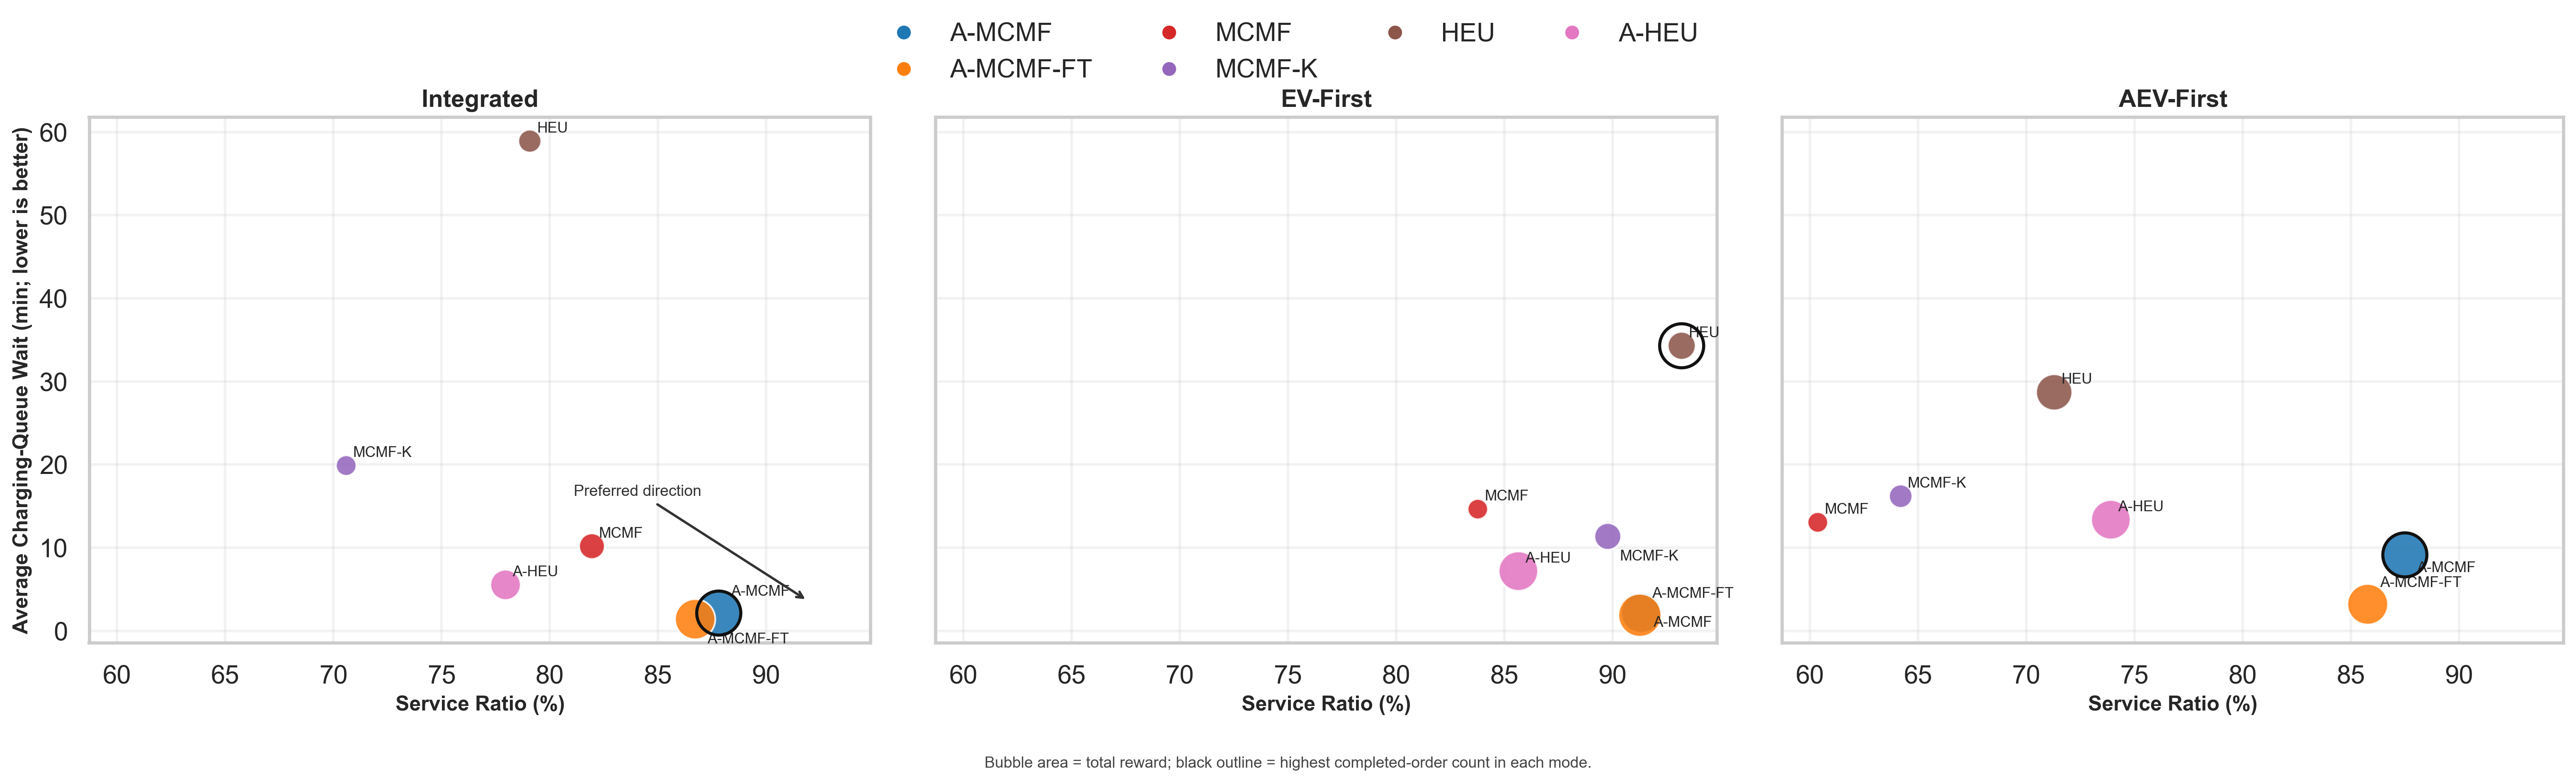

results/nyc_masac_queue/trc_service_congestion_frontier.png


In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk', font_scale=0.9)

result_dir = Path('results/nyc_masac_queue')
result_dir.mkdir(parents=True, exist_ok=True)
mode_label_map = {
    'integrated': 'Integrated',
    'evfirst': 'EV-First',
    'aevfirst': 'AEV-First',
}
mode_order = ['Integrated', 'EV-First', 'AEV-First']
strategy_order = ['ADP-MCMF', 'ADP-MCMF-FT', 'ADP-MCMF-K', 'MCMF', 'MCMF-K', 'HEU',  'ADP-HEU','ADP-HEU-K']
strategy_alias = {'ILP-K': 'MCMF-K'}
strategy_short = {
    'MCMF': 'MCMF',
    'MCMF-K': 'MCMF-K',
    'ADP-MCMF': 'A-MCMF',
    'ADP-MCMF-K': 'A-MCMF-K',
    'ADP-MCMF-FT': 'A-MCMF-FT',
    'HEU': 'HEU',
    'ADP-HEU': 'A-HEU',
    'ADP-HEU-K': 'A-HEU-K',
}
palette = dict(zip(strategy_order, sns.color_palette('tab10', n_colors=len(strategy_order))))
NYC_EPOCH_MINUTES = 30.0 / 60.0


def prepare_trc_data(source_df):
    """Prepare every post-comparison figure from data_whole only."""
    required = {
        'strategy', 'mode', 'avg_reward', 'mean_service_ratio','mean_ev_completed_orders',
        'mean_aev_completed_orders', 'episode_reward_ev',
        'episode_reward_aev', 'avg_battery_level', 'avg_wait',
    }
    missing = sorted(required.difference(source_df.columns))
    if missing:
        raise KeyError(f'data_whole is missing required columns: {missing}')

    detail_df = source_df.copy()
    detail_df['strategy'] = detail_df['strategy'].replace(strategy_alias)
    detail_df = detail_df[detail_df['strategy'].isin(strategy_order)].copy()
    detail_df['source_mode'] = detail_df['mode'].replace(mode_label_map)
    detail_df = detail_df[detail_df['source_mode'].isin(mode_order)].copy()
    detail_df['strategy'] = pd.Categorical(
        detail_df['strategy'], categories=strategy_order, ordered=True
    )
    detail_df['source_mode'] = pd.Categorical(
        detail_df['source_mode'], categories=mode_order, ordered=True
    )
    detail_df['service_ratio_pct'] = detail_df['mean_service_ratio'].astype(float)
    if detail_df['service_ratio_pct'].max() <= 1.5:
        detail_df['service_ratio_pct'] *= 100.0
    detail_df['battery_pct'] = detail_df['avg_battery_level'].astype(float)
    if detail_df['battery_pct'].max() <= 1.5:
        detail_df['battery_pct'] *= 100.0
    detail_df['completed_orders'] = (
        detail_df['mean_ev_completed_orders'].fillna(0.0)
        + detail_df['mean_aev_completed_orders'].fillna(0.0)
    )
    detail_df['reward_million'] = detail_df['avg_reward'].astype(float) / 1e6
    detail_df['avg_wait_min'] = detail_df['avg_wait'].astype(float) * NYC_EPOCH_MINUTES
    detail_df['strategy_short'] = detail_df['strategy'].map(strategy_short)
    return detail_df.sort_values(['source_mode', 'strategy']).reset_index(drop=True)


detail_plot_df = prepare_trc_data(data_whole)
common_strategies = [
    strategy for strategy in strategy_order
    if all(strategy in set(sub['strategy'].astype(str).dropna()) for _, sub in detail_plot_df.groupby('source_mode', observed=True))
]
detail_plot_df = detail_plot_df[detail_plot_df['strategy'].astype(str).isin(common_strategies)].copy()

scatter_df = (
    detail_plot_df.groupby(['source_mode', 'strategy'], as_index=False, observed=True)
    .agg(
        service_ratio_pct=('service_ratio_pct', 'mean'),
        avg_wait_min=('avg_wait_min', 'mean'),
        completed_orders=('completed_orders', 'mean'),
        avg_reward=('avg_reward', 'mean'),
    )
)
scatter_df['strategy_short'] = scatter_df['strategy'].map(strategy_short)

print('Managerial frontier: lower-right means higher service with less charging congestion.')

label_offsets = {
    ('Integrated', 'ADP-MCMF'): (7, 10),
    ('Integrated', 'ADP-MCMF-FT'): (7, -14),
    ('EV-First', 'ADP-MCMF'): (7, -8),
    ('EV-First', 'ADP-MCMF-FT'): (7, 10),
    ('EV-First', 'ADP-MCMF-K'): (7, 9),
    ('EV-First', 'MCMF-K'): (7, -14),
    ('AEV-First', 'ADP-MCMF'): (7, -10),
    ('AEV-First', 'ADP-MCMF-FT'): (7, 10),
    ('AEV-First', 'ADP-MCMF-K'): (7, 10),
}
fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=300, sharex=True, sharey=True)
for ax, mode_label in zip(axes, ['Integrated', 'EV-First', 'AEV-First']):
    completed_max = scatter_df[scatter_df['source_mode'] == mode_label]['completed_orders'].max()
    sub = scatter_df[scatter_df['source_mode'] == mode_label].sort_values('strategy')
    sns.scatterplot(
        data=sub,
        x='service_ratio_pct',
        y='avg_wait_min',
        hue='strategy',
        size='avg_reward',
        sizes=(140, 620),
        palette=palette,
        alpha=0.88,
        legend=False,
        ax=ax,
    )
    # Emphasize the strategy with the most completed orders in each mode.
    completed_best = sub[np.isclose(sub['completed_orders'], completed_max)]
    ax.scatter(
        completed_best['service_ratio_pct'],
        completed_best['avg_wait_min'],
        s=650,
        facecolors='none',
        edgecolors='#111111',
        linewidths=1.8,
        zorder=6,
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['strategy_short'],
            (row['service_ratio_pct'], row['avg_wait_min']),
            textcoords='offset points',
            xytext=label_offsets.get((mode_label, str(row['strategy'])), (4, 5)),
            ha='left',
            fontsize=8.5,
        )
    ax.set_title(mode_label, fontsize=14, fontweight='bold')
    ax.set_xlabel('Service Ratio (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Charging-Queue Wait (min; lower is better)', fontsize=12, fontweight='bold')
    if mode_label == 'Integrated':
        ax.annotate(
            'Preferred direction', xy=(0.92, 0.08), xycoords='axes fraction',
            xytext=(0.62, 0.28), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1.4),
            fontsize=9, color='#333333',
        )
    ax.grid(True, alpha=0.25)

strategy_handles = [
    Line2D([0], [0], marker='o', color='w', label=strategy_short[s], markerfacecolor=palette[s], markersize=9)
    for s in common_strategies
]
fig.legend(strategy_handles, [strategy_short[s] for s in common_strategies], loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.text(0.5, 0.01, 'Bubble area = total reward; black outline = highest completed-order count in each mode.', ha='center', fontsize=9, color='#444444')
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
scatter_path = result_dir / 'trc_service_congestion_frontier.png'
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
plt.show()
print(scatter_path)


In [47]:
nyc_1000_i = pd.read_excel(r'results/nyc/nyc1000/nyc_1000_i.xlsx', sheet_name="detail")
nyc_1000_e = pd.read_excel(r'results/nyc/nyc1000/nyc_1000_e.xlsx', sheet_name="detail")
nyc_1000_a = pd.read_excel(r'results/nyc/nyc1000/nyc_1000_a.xlsx', sheet_name="detail")
nyc_2000_i = pd.read_excel(r'results/nyc/nyc2000/nyc_2000_i.xlsx', sheet_name="detail")
nyc_2000_e = pd.read_excel(r'results/nyc/nyc2000/nyc_2000_e.xlsx', sheet_name="detail")
nyc_2000_a = pd.read_excel(r'results/nyc/nyc2000/nyc_2000_a.xlsx', sheet_name="detail")
nyc_3000_i = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_i.xlsx', sheet_name="detail")
nyc_3000_e = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_e.xlsx', sheet_name="detail")
nyc_3000_a = pd.read_excel(r'results/nyc/nyc3000/nyc_3000_a.xlsx', sheet_name="detail")

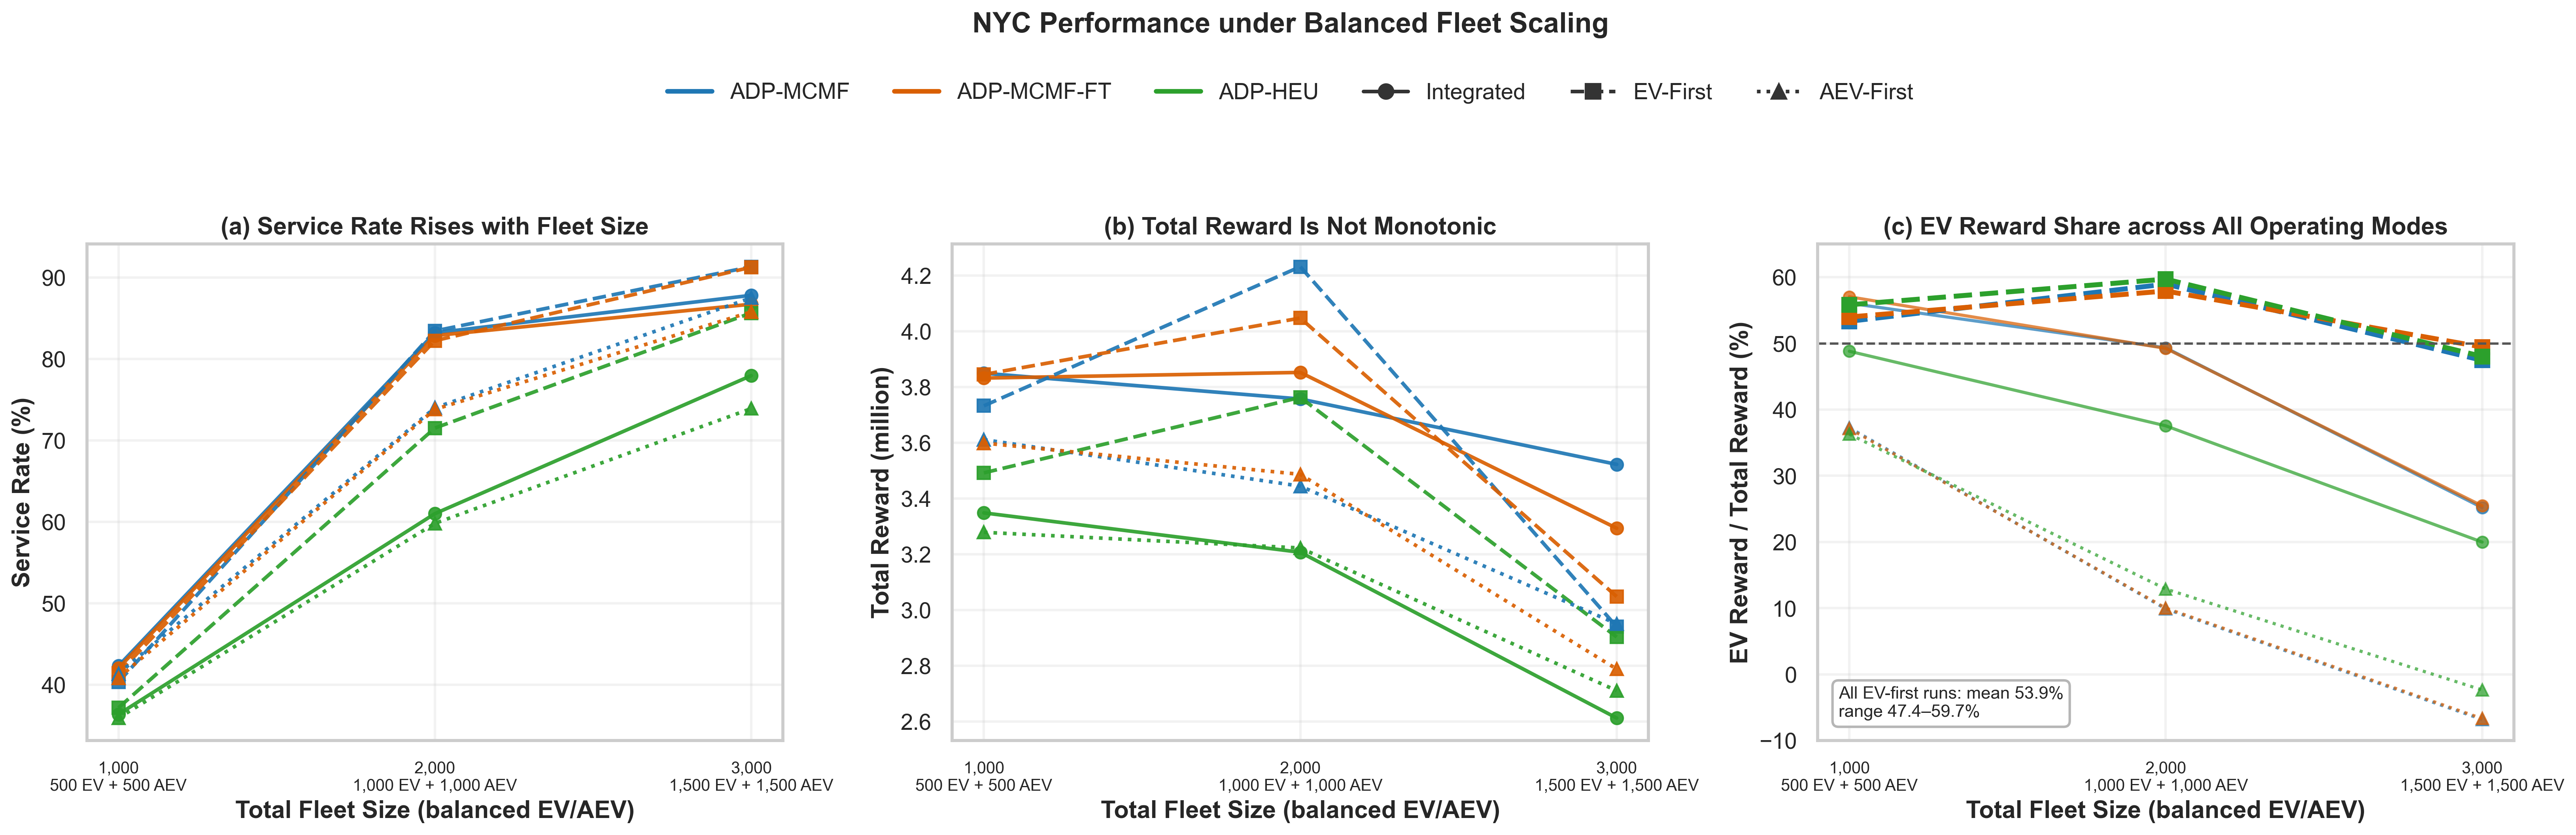

 fleet_size mode_label    strategy  service_rate_pct  reward_million  ev_reward_share_pct
       1000  AEV-First     ADP-HEU             35.92            3.28                36.29
       1000  AEV-First    ADP-MCMF             41.36            3.61                37.28
       1000  AEV-First ADP-MCMF-FT             40.85            3.60                37.13
       1000   EV-First     ADP-HEU             37.18            3.49                55.83
       1000   EV-First    ADP-MCMF             40.33            3.73                53.34
       1000   EV-First ADP-MCMF-FT             41.43            3.85                53.99
       1000 Integrated     ADP-HEU             36.37            3.35                48.82
       1000 Integrated    ADP-MCMF             42.31            3.85                56.07
       1000 Integrated ADP-MCMF-FT             42.03            3.83                57.05
       2000  AEV-First     ADP-HEU             59.81            3.22                12.90
       200

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk', font_scale=0.82)

# The nine detail sheets represent balanced fleets: 500/500, 1000/1000,
# and 1500/1500 EV/AEV vehicles under the three operating modes.
fleet_frames = {
    (1000, 'Integrated'): nyc_1000_i,
    (1000, 'EV-First'): nyc_1000_e,
    (1000, 'AEV-First'): nyc_1000_a,
    (2000, 'Integrated'): nyc_2000_i,
    (2000, 'EV-First'): nyc_2000_e,
    (2000, 'AEV-First'): nyc_2000_a,
    (3000, 'Integrated'): nyc_3000_i,
    (3000, 'EV-First'): nyc_3000_e,
    (3000, 'AEV-First'): nyc_3000_a,
}
strategy_order = ['ADP-MCMF', 'ADP-MCMF-FT', 'ADP-HEU']
mode_order = ['Integrated', 'EV-First', 'AEV-First']
required_columns = {
    'strategy', 'mean_service_ratio', 'avg_reward',
    'episode_reward_ev', 'episode_reward_aev',
}

scale_rows = []
for (fleet_size, mode_label), source_df in fleet_frames.items():
    missing = sorted(required_columns.difference(source_df.columns))
    if missing:
        raise KeyError(f'{fleet_size} {mode_label} detail sheet is missing: {missing}')
    frame = source_df[source_df['strategy'].isin(strategy_order)].copy()
    frame['fleet_size'] = fleet_size
    frame['mode_label'] = mode_label
    scale_rows.append(frame)

fleet_scale_df = pd.concat(scale_rows, ignore_index=True)
fleet_scale_df = (
    fleet_scale_df
    .groupby(['fleet_size', 'mode_label', 'strategy'], as_index=False, observed=True)
    .agg(
        service_ratio=('mean_service_ratio', 'mean'),
        total_reward=('avg_reward', 'mean'),
        ev_reward=('episode_reward_ev', 'mean'),
        aev_reward=('episode_reward_aev', 'mean'),
    )
)
fleet_scale_df['service_rate_pct'] = fleet_scale_df['service_ratio'].astype(float)
if fleet_scale_df['service_rate_pct'].max() <= 1.5:
    fleet_scale_df['service_rate_pct'] *= 100.0
fleet_scale_df['reward_million'] = fleet_scale_df['total_reward'] / 1e6
fleet_scale_df['reward_sum'] = fleet_scale_df['ev_reward'] + fleet_scale_df['aev_reward']
fleet_scale_df['ev_reward_share_pct'] = np.where(
    fleet_scale_df['reward_sum'].abs() > 1e-12,
    fleet_scale_df['ev_reward'] / fleet_scale_df['reward_sum'] * 100.0,
    np.nan,
)

strategy_palette = {
    'ADP-MCMF': '#1F77B4',
    'ADP-MCMF-FT': '#D95F02',
    'ADP-HEU': '#2CA02C',
}
mode_style = {
    'Integrated': {'linestyle': '-', 'marker': 'o'},
    'EV-First': {'linestyle': '--', 'marker': 's'},
    'AEV-First': {'linestyle': ':', 'marker': '^'},
}
fleet_sizes = [1000, 2000, 3000]
fleet_tick_labels = [
    '1,000\n500 EV + 500 AEV',
    '2,000\n1,000 EV + 1,000 AEV',
    '3,000\n1,500 EV + 1,500 AEV',
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6.6), dpi=300)

# Panels (a) and (b): use colour for strategy and line style for operating mode.
for mode_label in mode_order:
    for strategy in strategy_order:
        sub = fleet_scale_df[
            (fleet_scale_df['mode_label'] == mode_label)
            & (fleet_scale_df['strategy'] == strategy)
        ].sort_values('fleet_size')
        if sub.empty:
            continue
        common = dict(
            color=strategy_palette[strategy],
            linewidth=2.2, markersize=7.5, alpha=0.92,
            **mode_style[mode_label],
        )
        axes[0].plot(sub['fleet_size'], sub['service_rate_pct'], **common)
        axes[1].plot(sub['fleet_size'], sub['reward_million'], **common)

axes[0].set_title('(a) Service Rate Rises with Fleet Size', fontweight='bold')
axes[0].set_ylabel('Service Rate (%)', fontweight='bold')
axes[1].set_title('(b) Total Reward Is Not Monotonic', fontweight='bold')
axes[1].set_ylabel('Total Reward (million)', fontweight='bold')

# Panel (c): include all three modes; emphasize EV-first with a thicker line.
evfirst_df = fleet_scale_df[fleet_scale_df['mode_label'] == 'EV-First'].copy()
for mode_label in mode_order:
    for strategy in strategy_order:
        sub = fleet_scale_df[
            (fleet_scale_df['mode_label'] == mode_label)
            & (fleet_scale_df['strategy'] == strategy)
        ].sort_values('fleet_size')
        if sub.empty:
            continue
        axes[2].plot(
            sub['fleet_size'], sub['ev_reward_share_pct'],
            color=strategy_palette[strategy],
            linewidth=3.0 if mode_label == 'EV-First' else 1.9,
            markersize=8.5 if mode_label == 'EV-First' else 7.0,
            alpha=1.0 if mode_label == 'EV-First' else 0.72,
            **mode_style[mode_label],
        )
axes[2].axhline(50.0, color='#555555', linestyle='--', linewidth=1.4,
                label='EV fleet share (50%)')
share_mean = evfirst_df['ev_reward_share_pct'].mean()
share_min = evfirst_df['ev_reward_share_pct'].min()
share_max = evfirst_df['ev_reward_share_pct'].max()
axes[2].text(
    0.03, 0.04,
    f'All EV-first runs: mean {share_mean:.1f}%\nrange {share_min:.1f}–{share_max:.1f}%',
    transform=axes[2].transAxes, fontsize=10.5, va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#B0B0B0', alpha=0.92),
)
all_share_min = fleet_scale_df['ev_reward_share_pct'].min()
all_share_max = fleet_scale_df['ev_reward_share_pct'].max()
share_axis_min = 5.0 * np.floor((all_share_min - 3.0) / 5.0)
share_axis_max = 5.0 * np.ceil((all_share_max + 3.0) / 5.0)
axes[2].set_title('(c) EV Reward Share across All Operating Modes', fontweight='bold')
axes[2].set_ylabel('EV Reward / Total Reward (%)', fontweight='bold')
axes[2].set_ylim(share_axis_min, share_axis_max)

for ax in axes:
    ax.set_xlabel('Total Fleet Size (balanced EV/AEV)', fontweight='bold')
    ax.set_xticks(fleet_sizes)
    ax.set_xticklabels(fleet_tick_labels, fontsize=10)
    ax.grid(True, alpha=0.25)

strategy_handles = [
    Line2D([0], [0], color=strategy_palette[s], linewidth=2.8, label=s)
    for s in strategy_order
]
mode_handles = [
    Line2D([0], [0], color='#333333', linewidth=2.2,
           linestyle=mode_style[m]['linestyle'], marker=mode_style[m]['marker'], label=m)
    for m in mode_order
]
fig.legend(
    strategy_handles + mode_handles,
    [h.get_label() for h in strategy_handles + mode_handles],
    loc='upper center', ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.035),
)
fig.suptitle('NYC Performance under Balanced Fleet Scaling',
             fontsize=17, fontweight='bold', y=1.10)
# fig.text(
#     0.5, -0.035,
#     'Service capacity increases with fleet size, while fleet-level reward can fall because demand is fixed; '
#     'panel (c) reports EV reward as a share of EV + AEV reward and highlights EV-first.',
#     ha='center', fontsize=10.5, color='#444444',
# )
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
result_dir = Path('results/nyc/fleet_scale')
result_dir.mkdir(parents=True, exist_ok=True)
fleet_scale_path = result_dir / 'nyc_fleet_scale_service_reward_evshare.png'
plt.savefig(fleet_scale_path, dpi=300, bbox_inches='tight')
plt.show()

print(fleet_scale_df[[
    'fleet_size', 'mode_label', 'strategy', 'service_rate_pct',
    'reward_million', 'ev_reward_share_pct',
]].sort_values(['fleet_size', 'mode_label', 'strategy']).to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print(f'Figure saved to: {fleet_scale_path}')


In [49]:
import numpy as np
import pandas as pd

# NYC balanced-fleet comparison: 1000, 2000, and 3000 total vehicles.
file_specs = [
    (1000, 'I',  r'results/nyc/nyc1000/nyc_1000_i.xlsx'),
    (1000, 'EF', r'results/nyc/nyc1000/nyc_1000_e.xlsx'),
    (1000, 'AF', r'results/nyc/nyc1000/nyc_1000_a.xlsx'),
    (2000, 'I',  r'results/nyc/nyc2000/nyc_2000_i.xlsx'),
    (2000, 'EF', r'results/nyc/nyc2000/nyc_2000_e.xlsx'),
    (2000, 'AF', r'results/nyc/nyc2000/nyc_2000_a.xlsx'),
    (3000, 'I',  r'results/nyc/nyc3000/nyc_3000_i.xlsx'),
    (3000, 'EF', r'results/nyc/nyc3000/nyc_3000_e.xlsx'),
    (3000, 'AF', r'results/nyc/nyc3000/nyc_3000_a.xlsx'),
]
strategy_order = ['ADP-MCMF', 'ADP-MCMF-FT', 'ADP-HEU']
mode_order = ['I', 'EF', 'AF']
label_map = {
    'integrated': 'I',
    'evfirst': 'EF',
    'aevfirst': 'AF',
}
compare_lists = [
    'strategy', 'NV', 'mode', 'avg_reward',
    'episode_reward_ev', 'episode_reward_aev',
    'mean_ev_completed_orders', 'mean_aev_completed_orders',
    'mean_service_ratio', 'avg_battery_level', 'avg_wait',
]
required_columns = set(compare_lists) - {'NV'}

scale_frames = []
for nv, expected_mode, workbook_path in file_specs:
    detail = pd.read_excel(workbook_path, sheet_name='detail')
    missing = sorted(required_columns.difference(detail.columns))
    if missing:
        raise KeyError(f'{workbook_path}: missing columns {missing}')

    detail = detail[detail['strategy'].isin(strategy_order)].copy()
    detail['mode'] = detail['mode'].replace(label_map)
    if set(detail['mode'].dropna()) != {expected_mode}:
        raise ValueError(
            f'{workbook_path}: expected mode {expected_mode}, '
            f"found {sorted(detail['mode'].dropna().astype(str).unique())}"
        )
    method_counts = detail['strategy'].value_counts()
    invalid_methods = {
        method: int(method_counts.get(method, 0))
        for method in strategy_order
        if int(method_counts.get(method, 0)) != 1
    }
    if invalid_methods:
        raise ValueError(
            f'{workbook_path}: expected one row per method, found {invalid_methods}'
        )

    # Insert total vehicle count immediately after Method/strategy.
    detail.insert(detail.columns.get_loc('strategy') + 1, 'NV', int(nv))
    scale_frames.append(detail[compare_lists])

data_whole_scale = pd.concat(scale_frames, ignore_index=True)
data_5_origin_scale = data_whole_scale.copy().reset_index(drop=True)
data_5_origin_scale['mode'] = pd.Categorical(
    data_5_origin_scale['mode'], categories=mode_order, ordered=True
)
data_5_origin_scale['strategy'] = pd.Categorical(
    data_5_origin_scale['strategy'], categories=strategy_order, ordered=True
)
data_5_origin_scale = data_5_origin_scale.sort_values(
    ['mode', 'strategy', 'NV']
).reset_index(drop=True)

# NYC epoch = 30 seconds: avg_wait / 2 converts epochs to minutes.
data_5_origin_scale['mean_service_ratio'] = np.round(
    data_5_origin_scale['mean_service_ratio'].astype(float) * 100.0, 2
)
data_5_origin_scale['avg_battery_level'] = np.round(
    data_5_origin_scale['avg_battery_level'].astype(float) * 100.0, 2
)
data_5_origin_scale['avg_wait'] = (
    data_5_origin_scale['avg_wait'].astype(float) / 2.0
)

scientific_columns = {
    'avg_reward', 'episode_reward_ev', 'episode_reward_aev',
    'mean_ev_completed_orders', 'mean_aev_completed_orders',
}
for row_id, row in data_5_origin_scale.iterrows():
    formatted_values = []
    for column in data_5_origin_scale.columns:
        value = row[column]
        if column in {'strategy', 'mode'}:
            formatted_values.append(str(value))
        elif column == 'NV':
            formatted_values.append(str(int(value)))
        elif column in scientific_columns:
            formatted_values.append(f'{float(value):.2e}')
        else:
            formatted_values.append(f'{float(value):.2f}')
    print(f"{row_id}&" + ' & '.join(formatted_values) + r' \\')


0&ADP-MCMF & 1000 & I & 3.85e+06 & 2.16e+06 & 1.69e+06 & 3.30e+04 & 2.14e+04 & 42.31 & 57.36 & 0.87 \\
1&ADP-MCMF & 2000 & I & 3.76e+06 & 1.85e+06 & 1.90e+06 & 6.17e+04 & 4.51e+04 & 83.20 & 73.71 & 1.09 \\
2&ADP-MCMF & 3000 & I & 3.52e+06 & 8.87e+05 & 2.64e+06 & 3.57e+04 & 7.70e+04 & 87.81 & 77.55 & 2.13 \\
3&ADP-MCMF-FT & 1000 & I & 3.83e+06 & 2.19e+06 & 1.65e+06 & 3.27e+04 & 2.13e+04 & 42.03 & 61.11 & 1.07 \\
4&ADP-MCMF-FT & 2000 & I & 3.85e+06 & 1.90e+06 & 1.96e+06 & 6.30e+04 & 4.34e+04 & 82.87 & 71.11 & 1.09 \\
5&ADP-MCMF-FT & 3000 & I & 3.29e+06 & 8.39e+05 & 2.45e+06 & 4.22e+04 & 6.92e+04 & 86.72 & 79.28 & 1.40 \\
6&ADP-HEU & 1000 & I & 3.35e+06 & 1.63e+06 & 1.71e+06 & 1.94e+04 & 2.73e+04 & 36.37 & 65.14 & 2.87 \\
7&ADP-HEU & 2000 & I & 3.21e+06 & 1.20e+06 & 2.00e+06 & 2.19e+04 & 5.65e+04 & 61.01 & 50.99 & 3.22 \\
8&ADP-HEU & 3000 & I & 2.61e+06 & 5.22e+05 & 2.09e+06 & 1.95e+04 & 8.06e+04 & 77.96 & 63.65 & 5.53 \\
9&ADP-MCMF & 1000 & EF & 3.73e+06 & 1.99e+06 & 1.74e+06 & 2.13e+04 